# Проект "Промышленность"

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление\
электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава.\

**Задача**: построить модель, которая будет предсказывать температуру стали.\

**Ход исследования:**
1. Загрузка данных
2. Исследовательский анализ и предобработка
3. Объединение данных
4. Исследовательский анализ и предобработка новых данных, корреляционный анализ
5. Подготовка данных
6. Обучение моделей машинного обучения
7. Выбор лучшей модели, анализ важности факторов, проверка на адекватность
8. Вывод

In [1]:
#import sklearn
#sklearn.__version__

In [2]:
!pip install scikit-learn==1.6.1

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.1 MB 5.6 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/11.1 MB 8.1 MB/s eta 0:00:01
   -------------------- ------------------- 5.8/11.1 MB 8.4 MB/s eta 0:00:01
   ---------------------------- ----------- 7.9/11.1 MB 8.5 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 8.6 MB/s eta 0:00:01
   ----------

In [3]:
!pip install phik -q
!pip install shap -q

In [4]:
#!pip uninstall scikit-learn -y
#!pip install scikit-learn

In [5]:
pip install --upgrade catboost scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kernel to use updated packages.


In [6]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import lightgbm as lgb
import phik
import os

# импорт моделей
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor 
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# импорт классов
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

# импорт метрик
from sklearn.metrics import mean_absolute_error

plt.rcParams["figure.figsize"] = (12,5)

## Шаг 1. Загрузка данных

In [7]:
# скачивание файла
pth_1 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_arc_new.csv'
pth_2 = '/datasets/data_arc_new.csv'

if os.path.exists(pth_1):
    data_arc_new = pd.read_csv(pth_1, parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
elif os.path.exists(pth_2):
    data_arc_new = pd.read_csv(pth_2, parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
else:
    print('Something is wrong')

In [8]:
# скачивание файла
pth_3 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_bulk_new.csv'
pth_4 = '/datasets/data_bulk_new.csv'

if os.path.exists(pth_3):
    data_bulk_new = pd.read_csv(pth_3)
elif os.path.exists(pth_4):
    data_bulk_new = pd.read_csv(pth_4)
else:
    print('Something is wrong')

In [9]:
# скачивание файла
pth_5 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_bulk_time_new.csv'
pth_6 = '/datasets/data_bulk_time_new.csv'

if os.path.exists(pth_5):
    data_bulk_time_new = pd.read_csv(pth_5, parse_dates=['Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5',
                                                       'Bulk 6', 'Bulk 7', 'Bulk 8', 'Bulk 9','Bulk 10',
                                                       'Bulk 11', 'Bulk 12', 'Bulk 13', 'Bulk 14', 'Bulk 15'])
elif os.path.exists(pth_6):
    data_bulk_time_new = pd.read_csv(pth_6, parse_dates=['Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5',
                                                       'Bulk 6', 'Bulk 7', 'Bulk 8', 'Bulk 9','Bulk 10',
                                                       'Bulk 11', 'Bulk 12', 'Bulk 13', 'Bulk 14', 'Bulk 15'])
else:
    print('Something is wrong')

In [10]:
# скачивание файла
pth_7 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_gas_new.csv'
pth_8 = '/datasets/data_gas_new.csv'

if os.path.exists(pth_7):
    data_gas_new = pd.read_csv(pth_7)
elif os.path.exists(pth_8):
    data_gas_new = pd.read_csv(pth_8)
else:
    print('Something is wrong')

In [11]:
# скачивание файла
pth_9 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_temp_new.csv'
pth_10 = '/datasets/data_temp_new.csv'

if os.path.exists(pth_9):
    data_temp_new = pd.read_csv(pth_9, parse_dates=['Время замера'])
elif os.path.exists(pth_10):
    data_temp_new = pd.read_csv(pth_10)
else:
    print('Something is wrong')

In [12]:
# скачивание файла
pth_11 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_wire_new.csv'
pth_12 = '/datasets/data_wire_new.csv'

if os.path.exists(pth_11):
    data_wire_new = pd.read_csv(pth_11)
elif os.path.exists(pth_12):
    data_wire_new = pd.read_csv(pth_12)
else:
    print('Something is wrong')

In [13]:
# скачивание файла
pth_13 = 'C:/Users/1/anaconda3/учеба/Данные к проектам/Итоговый/data_wire_time_new.csv'
pth_14 = '/datasets/data_wire_time_new.csv'

if os.path.exists(pth_13):
    data_wire_time_new = pd.read_csv(pth_13, parse_dates=['Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5',
                                                       'Wire 6', 'Wire 7', 'Wire 8', 'Wire 9'])
elif os.path.exists(pth_14):
    data_wire_time_new = pd.read_csv(pth_14, parse_dates=['Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5',
                                                       'Wire 6', 'Wire 7', 'Wire 8', 'Wire 9'])
else:
    print('Something is wrong')

Создадим функцию для первичного осмотра данных.

In [14]:
def dataset_info(name):
    print('Первичный осмотр датафрейма')
    # получение первых строк датафрейма
    display(name.head(3))
    # получение общей информации
    display(name.info())
    return name

In [15]:
data_arc_new = dataset_info(data_arc_new)

Первичный осмотр датафрейма


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[ns]
 2   Конец нагрева дугой   14876 non-null  datetime64[ns]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


None

`data_arc_new` не содержит пропусков, типы данных корректны, нарушение стиля в названии столбцов.

In [16]:
data_bulk_new = dataset_info(data_bulk_new)

Первичный осмотр датафрейма


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


None

`data_bulk_new` все столбцы  "bulk" содержат пропуски, типы данных корректны, нарушение стиля в названии столбцов.

In [17]:
data_bulk_time_new = dataset_info(data_bulk_time_new)

Первичный осмотр датафрейма


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   Bulk 1   252 non-null    datetime64[ns]
 2   Bulk 2   22 non-null     datetime64[ns]
 3   Bulk 3   1298 non-null   datetime64[ns]
 4   Bulk 4   1014 non-null   datetime64[ns]
 5   Bulk 5   77 non-null     datetime64[ns]
 6   Bulk 6   576 non-null    datetime64[ns]
 7   Bulk 7   25 non-null     datetime64[ns]
 8   Bulk 8   1 non-null      datetime64[ns]
 9   Bulk 9   19 non-null     datetime64[ns]
 10  Bulk 10  176 non-null    datetime64[ns]
 11  Bulk 11  177 non-null    datetime64[ns]
 12  Bulk 12  2450 non-null   datetime64[ns]
 13  Bulk 13  18 non-null     datetime64[ns]
 14  Bulk 14  2806 non-null   datetime64[ns]
 15  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.3 KB


None

`data_bulk_time_new` все столбцы  "bulk" содержат пропуски, типы данных корректны, нарушение стиля в названии столбцов. Количество заполненных данных совпадает с `data_bulk_new`

In [18]:
data_gas_new = dataset_info(data_gas_new)

Первичный осмотр датафрейма


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


None

`data_gas_new` не содержит пропуски, типы данных корректны, нарушение стиля в названии столбцов.

In [19]:
data_temp_new = dataset_info(data_temp_new)

Первичный осмотр датафрейма


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   Время замера  18092 non-null  datetime64[ns]
 2   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


None

`data_temp_new` столбец "Температура" содержит пропуски, типы данных корректны, нарушение стиля в названии столбцов.

In [20]:
data_wire_new = dataset_info(data_wire_new)

Первичный осмотр датафрейма


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


None

`data_wire_new` все столбцы  "wire" содержат пропуски, типы данных корректны, нарушение стиля в названии столбцов.

In [21]:
data_wire_time_new = dataset_info(data_wire_time_new)

Первичный осмотр датафрейма


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   Wire 1  3055 non-null   datetime64[ns]
 2   Wire 2  1079 non-null   datetime64[ns]
 3   Wire 3  63 non-null     datetime64[ns]
 4   Wire 4  14 non-null     datetime64[ns]
 5   Wire 5  1 non-null      datetime64[ns]
 6   Wire 6  73 non-null     datetime64[ns]
 7   Wire 7  11 non-null     datetime64[ns]
 8   Wire 8  19 non-null     datetime64[ns]
 9   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


None

`data_wire_time_new` все столбцы  "wire" содержат пропуски, типы данных корректны, нарушение стиля в названии столбцов. Количество заполненных данных совпадает с `data_wire_new`

**Вывод** \
Все датафреймы содержат одинаковый столбец `key` - номер партии, количество партий во всех датафреймах разное. \
Типы данных во всех датафреймах корректны. \
Названия столбцов к общему стилю приведем после объединения необходимых признаков.

## Шаг 2. Исследовательский анализ и предобработка данных

Создадим функцию для визуализации данных.

In [22]:
def visual(data, name):
    for i in data.columns:
        if data[i].dtype != '<M8[ns]' and data[i].dtype != 'O' and i != "key":
            data[i].plot(kind='hist', bins=50, edgecolor='black')
            plt.title(f'Гистограмма распределения {i}')
            plt.ylabel('Частота')
            plt.show()
            data.boxplot([i], vert=False)
            plt.title(f'Диаграмма размаха {i}')
            plt.xlabel(i)
            plt.ylabel(' ')
            plt.show()

In [23]:
data_arc_new['Начало нагрева дугой'].dtype

dtype('<M8[ns]')

In [24]:
data_temp_new['Время замера'].dtype

dtype('<M8[ns]')

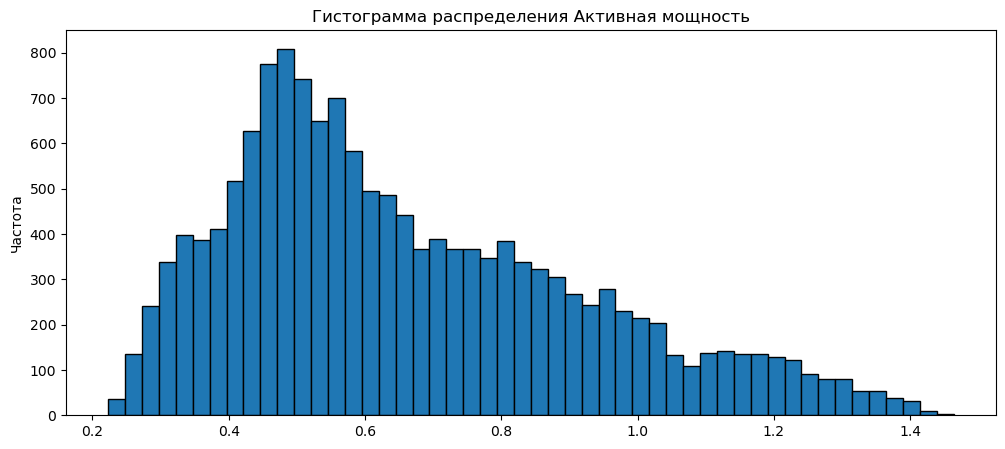

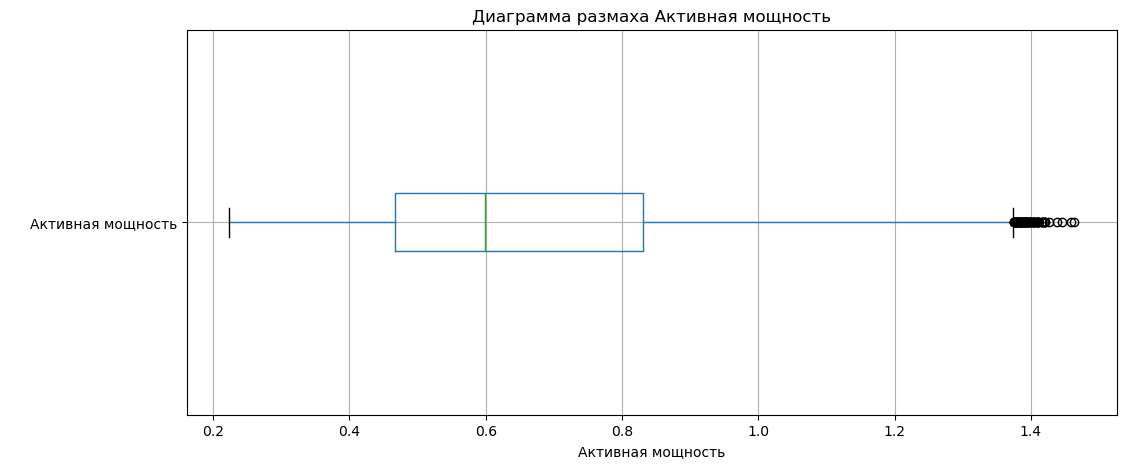

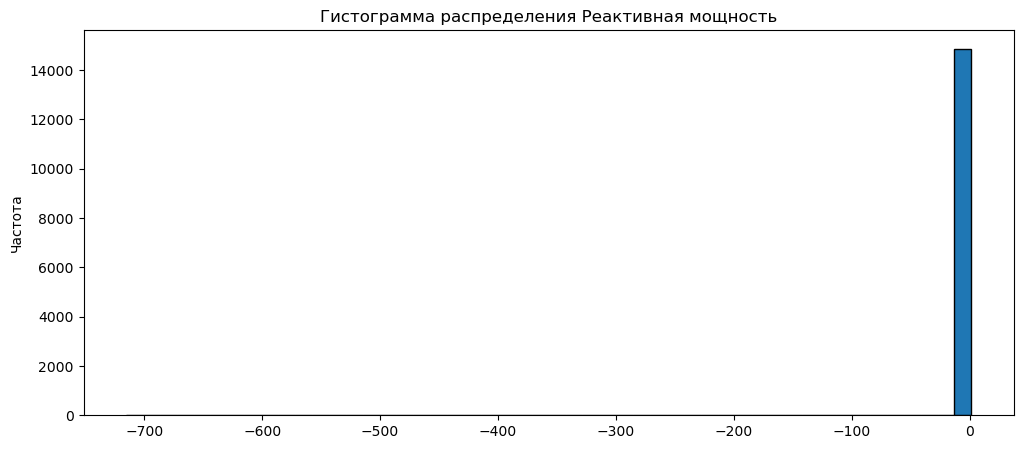

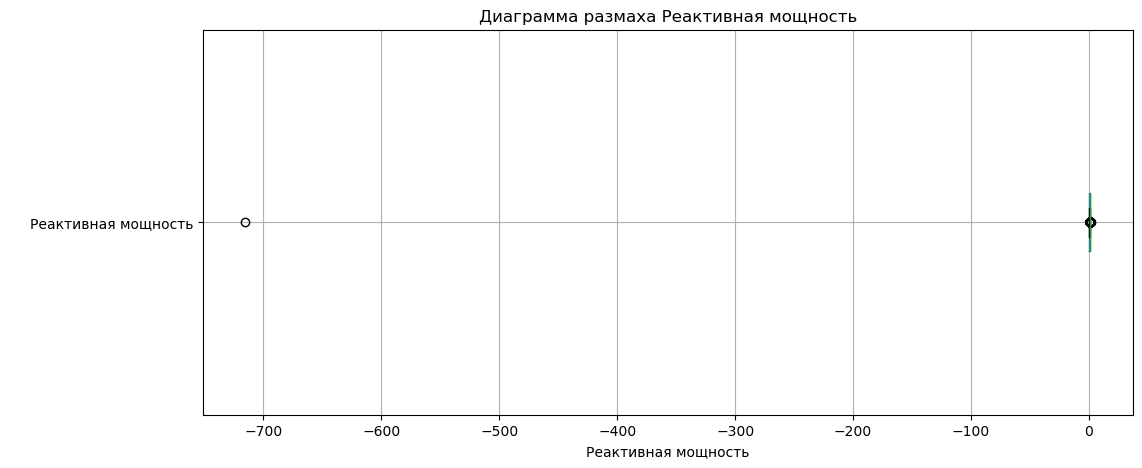

In [25]:
visual(data_arc_new, 'data_arc_new')

`data_arc_new['Реактивная мощность']` имеет выброс

Удалим данный выброс, так как реактивная мощность не может быть отрицательной. Удалим всю партию.

In [26]:
data_arc_new[data_arc_new['Реактивная мощность'] < 0]

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


Проверим всю партию.

In [27]:
data_arc_new[data_arc_new['key'] == 2116]

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.787549,0.693881
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580263,0.411498
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.563641,0.408513


Удалим всю партию.

In [28]:
data_arc = data_arc_new.query('key != 2116')

Аномалии удалены. 

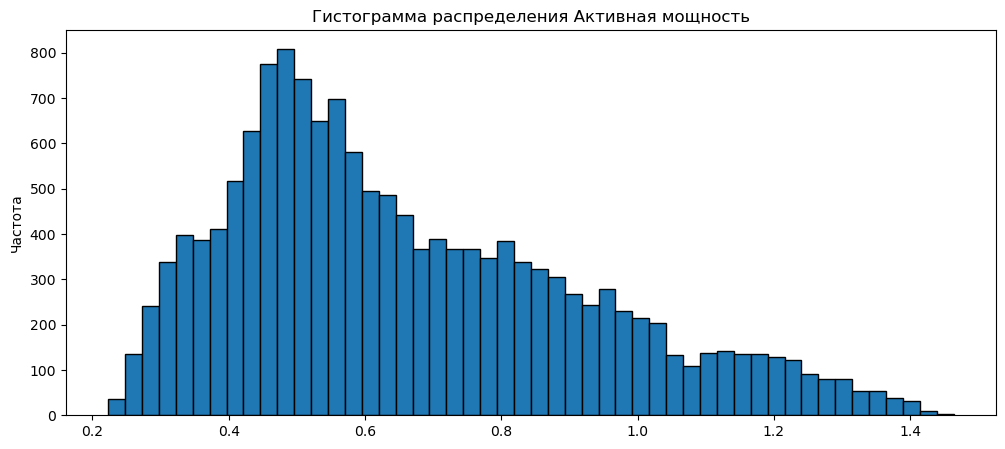

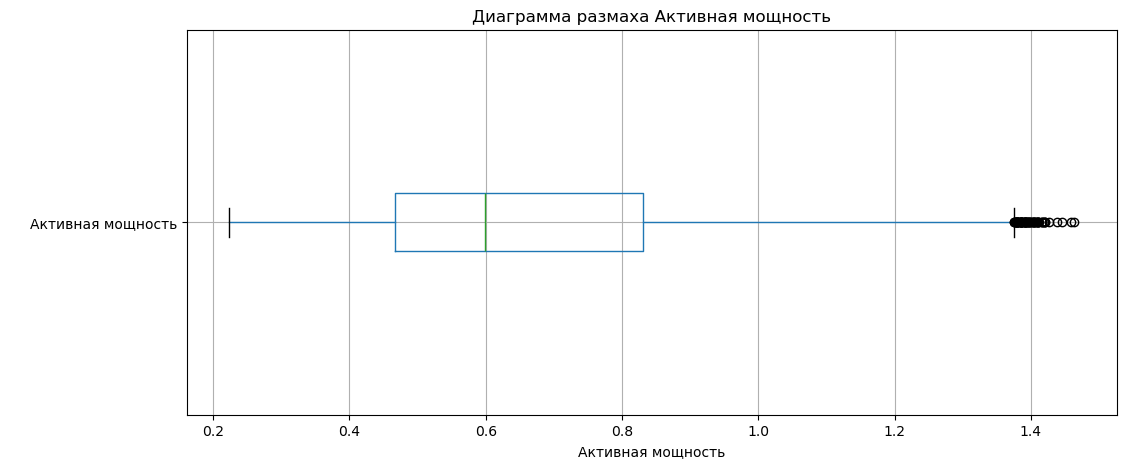

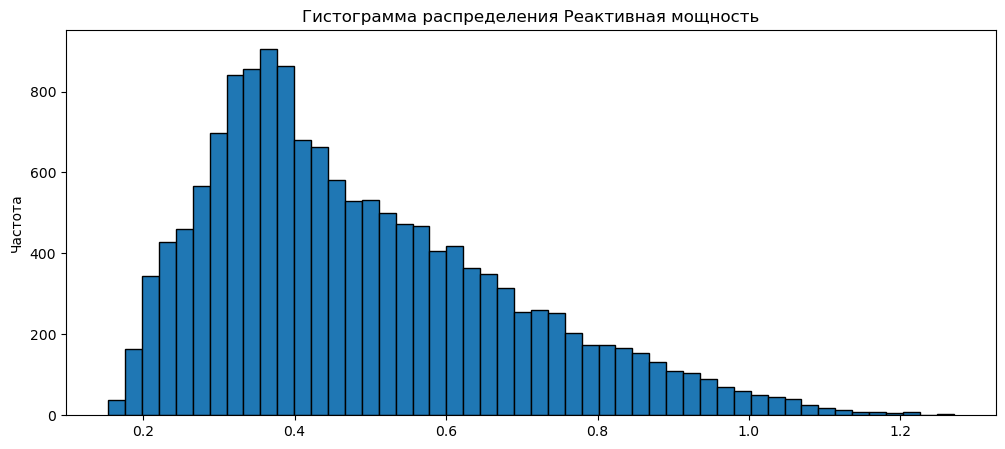

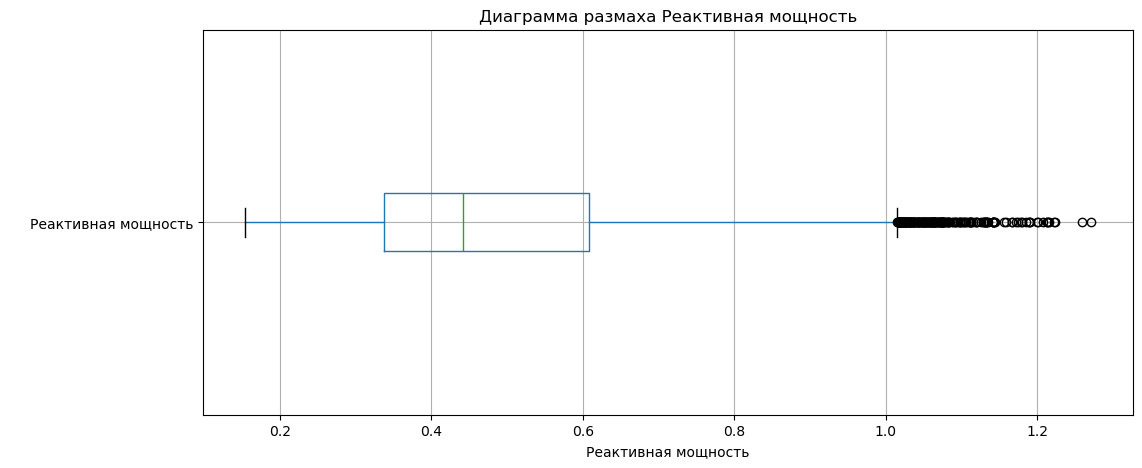

In [29]:
visual(data_arc, 'data_arc')

In [30]:
# проверим долю пропусков
(data_arc.isna().sum() / len(data_arc) * 100).round(2)

key                     0.0
Начало нагрева дугой    0.0
Конец нагрева дугой     0.0
Активная мощность       0.0
Реактивная мощность     0.0
dtype: float64

Датафрейм `data_arc` в столбцах Активная мощность и Реактивная мощность данные реалистичны. \
Датафрейм `data_arc` не содержит пропуски.

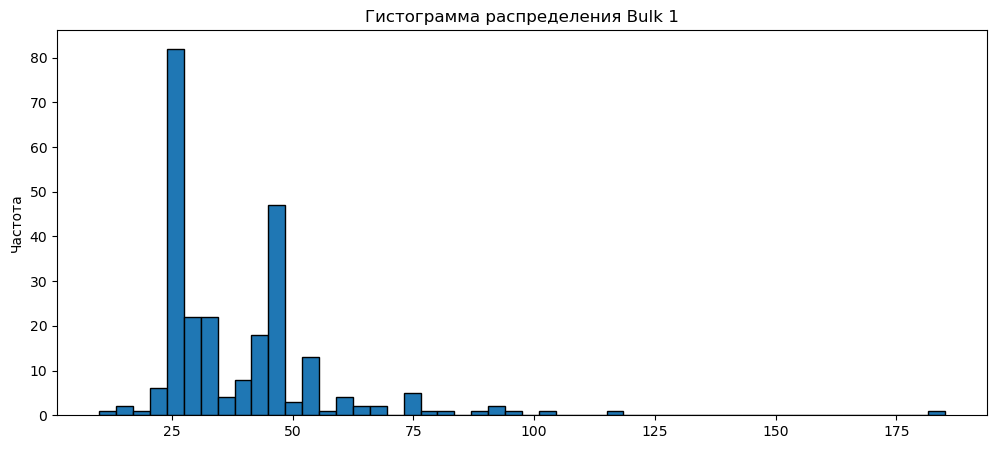

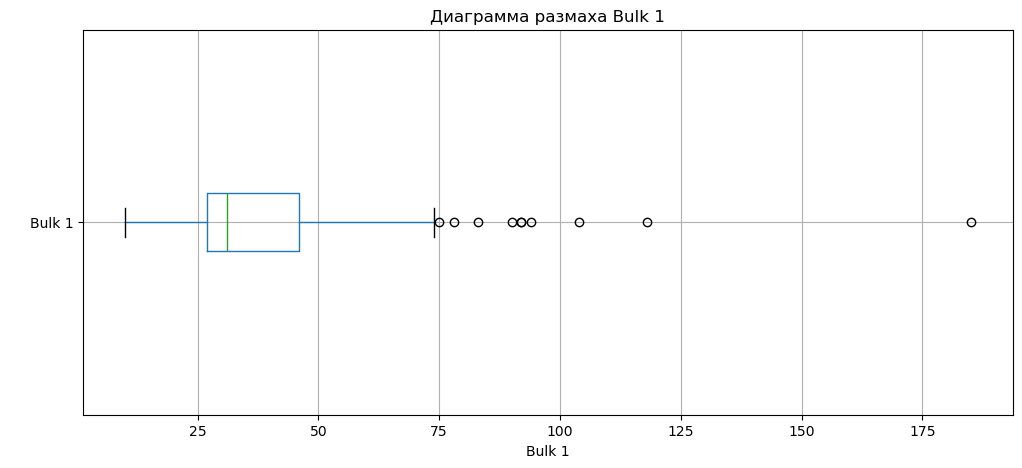

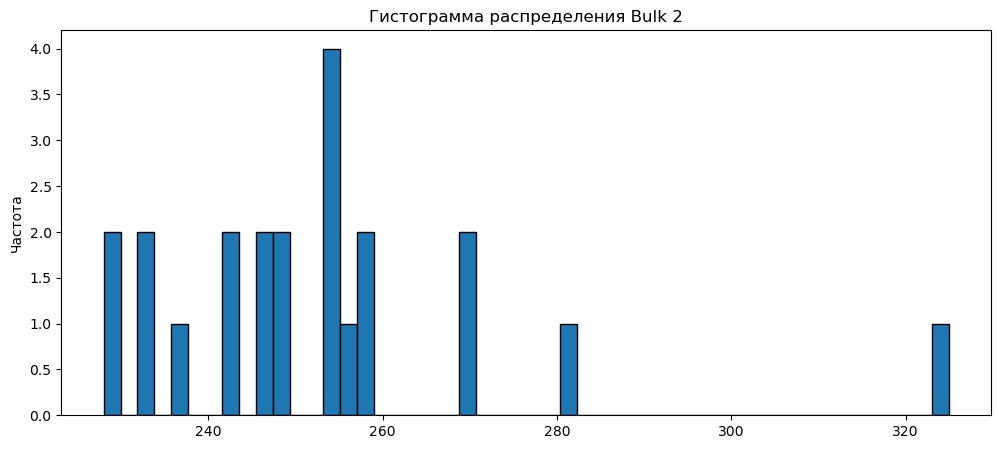

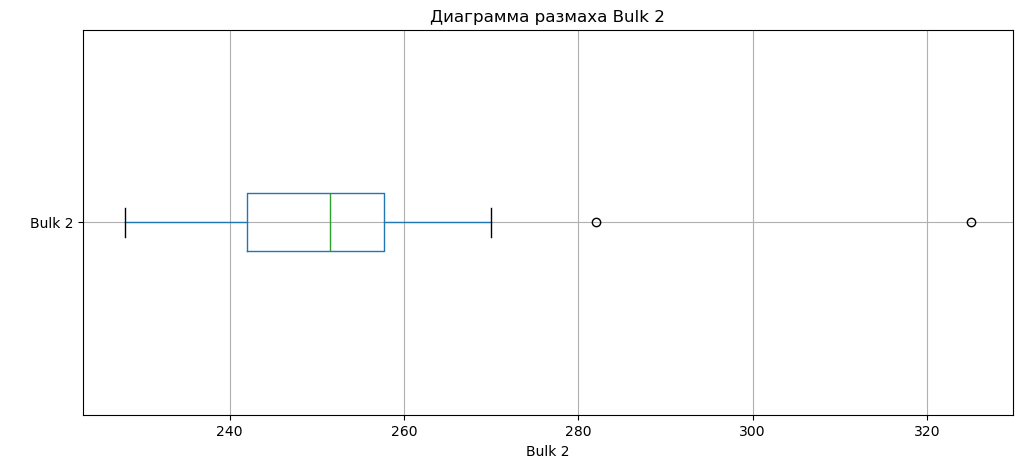

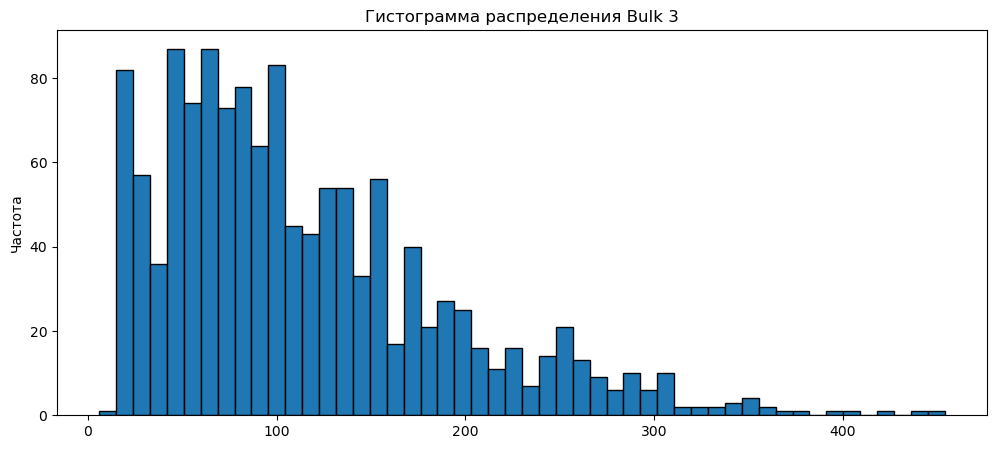

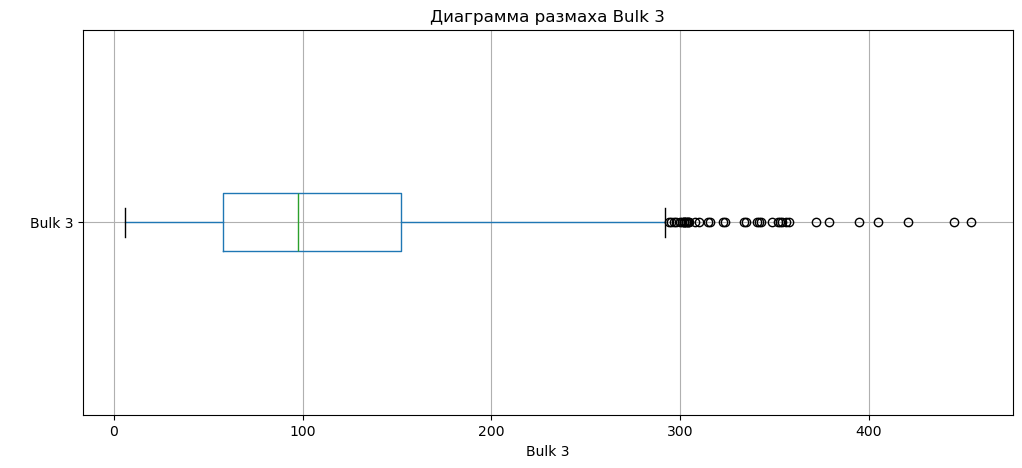

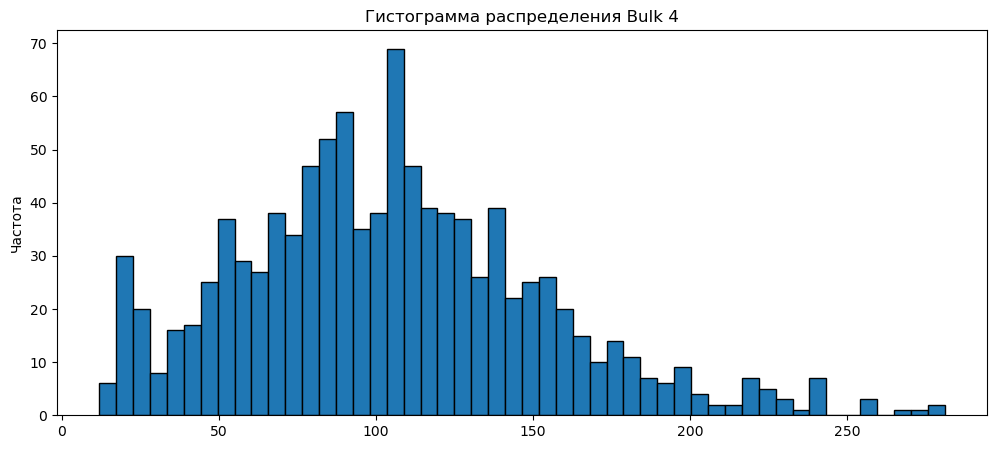

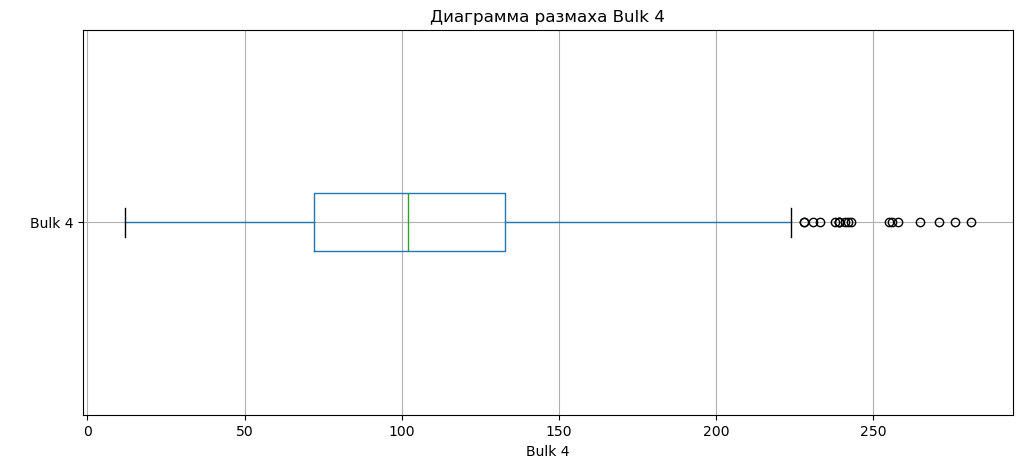

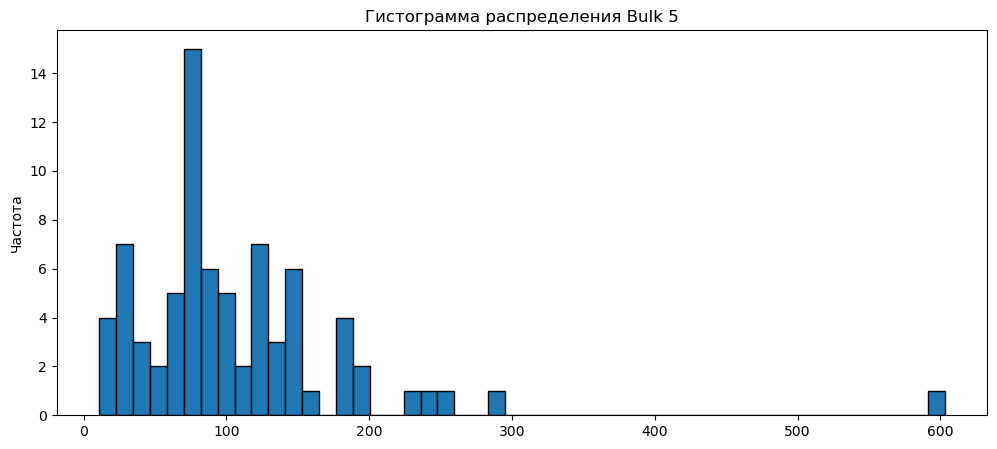

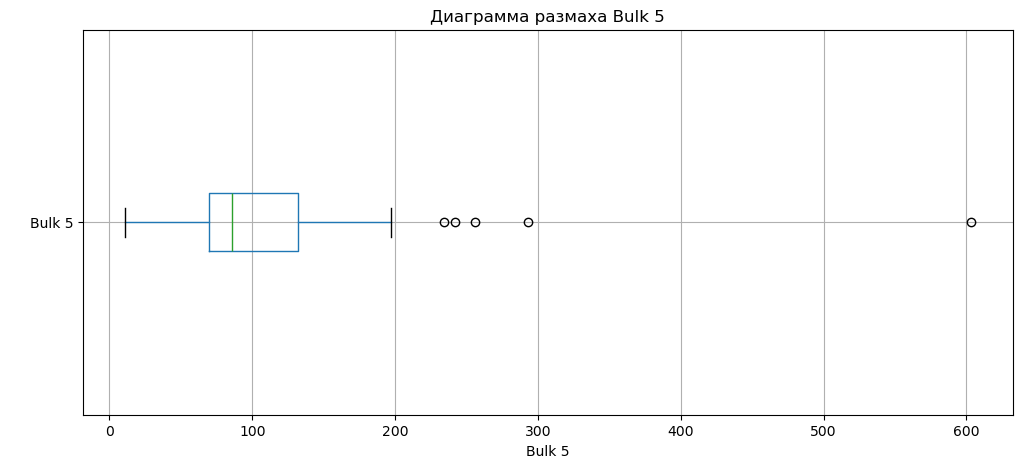

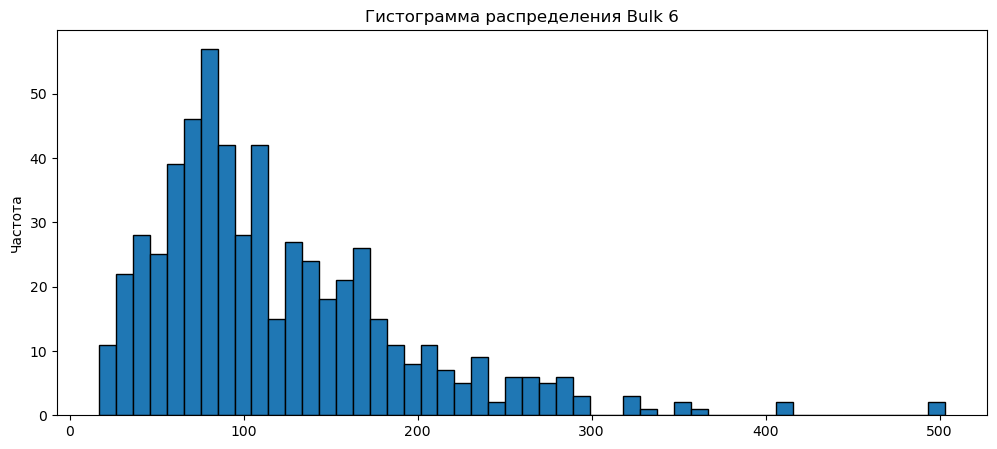

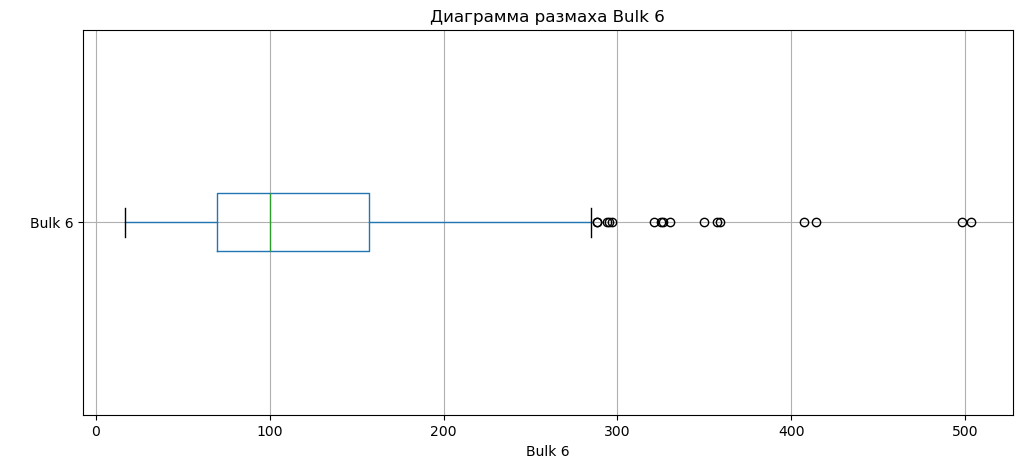

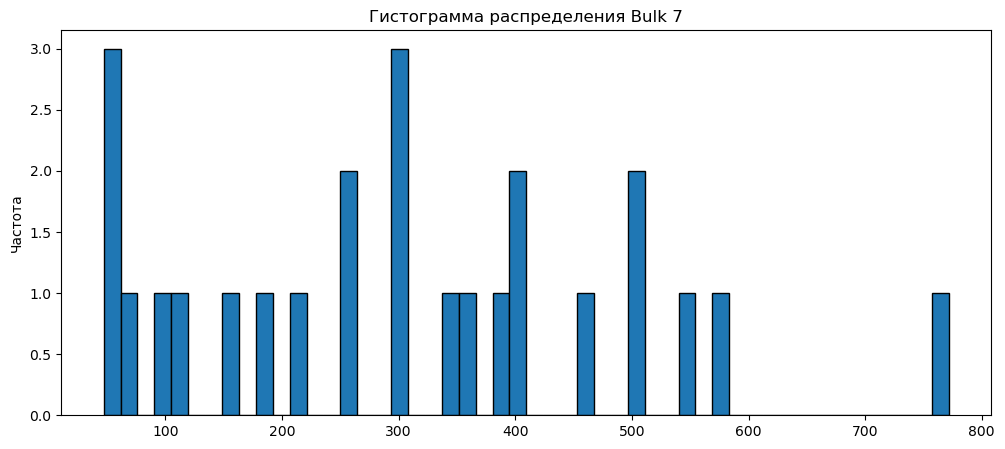

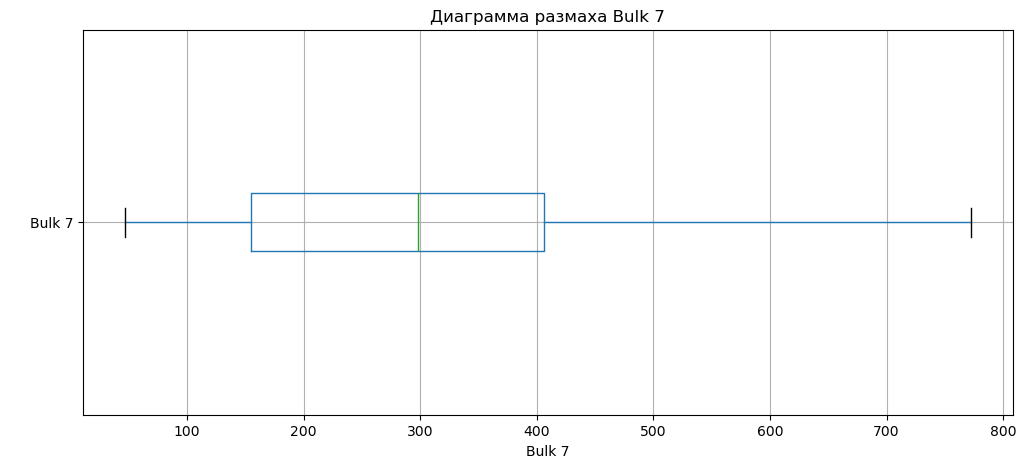

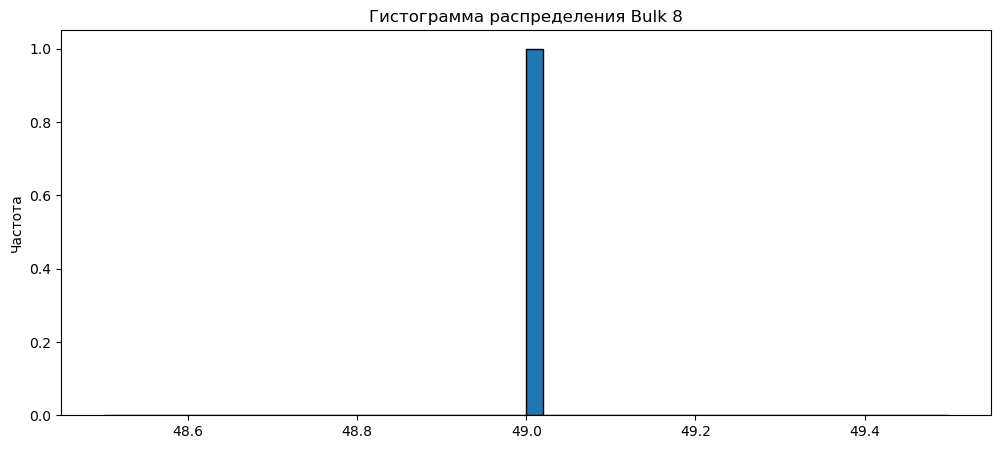

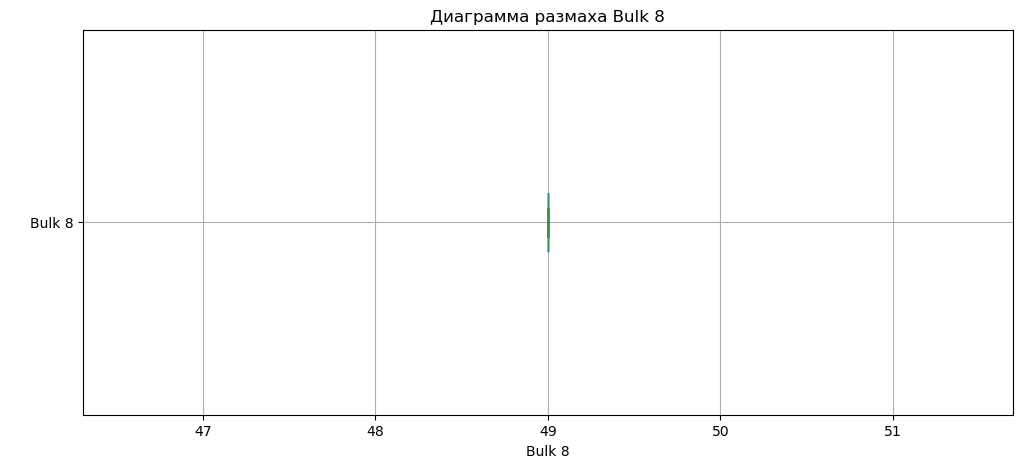

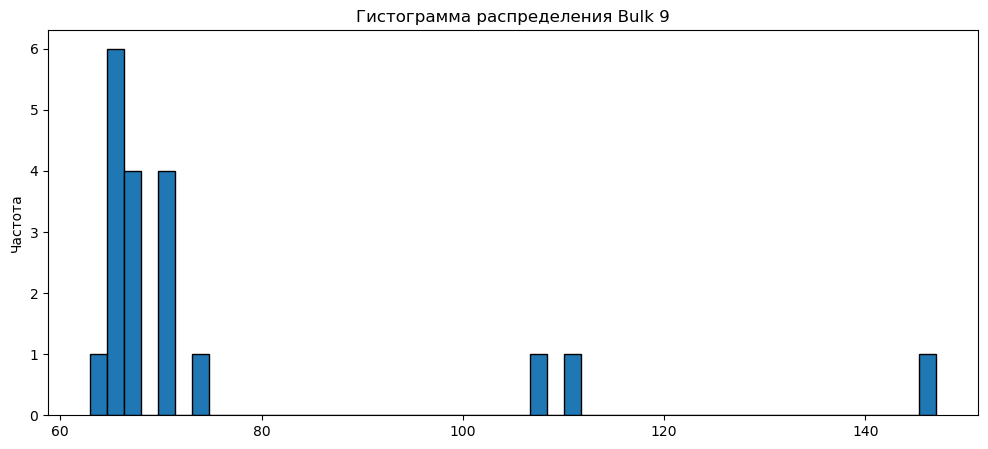

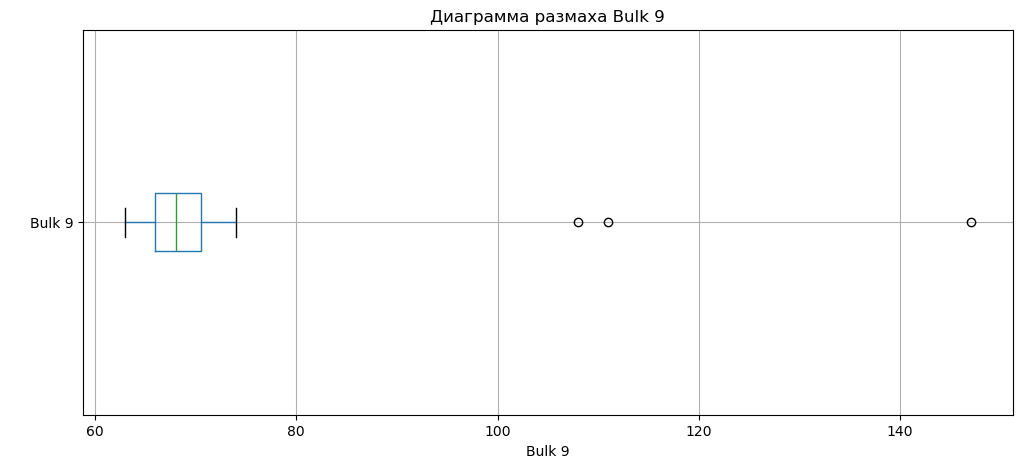

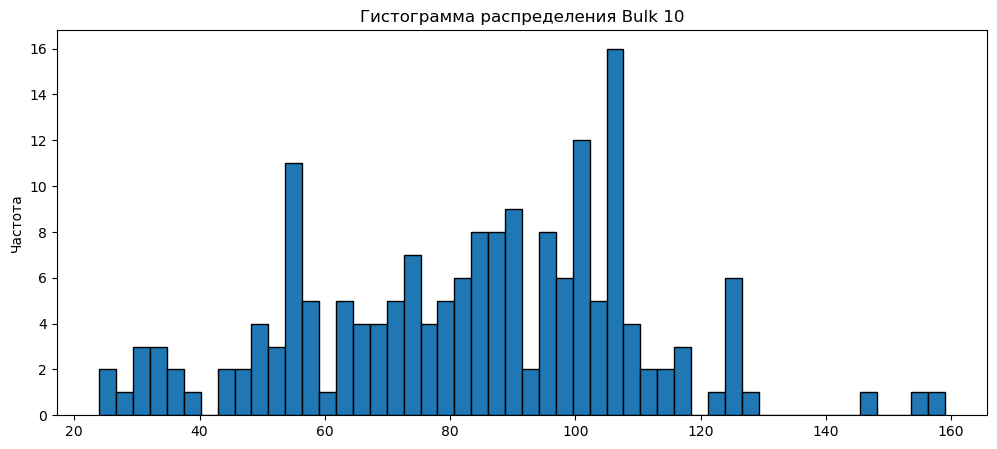

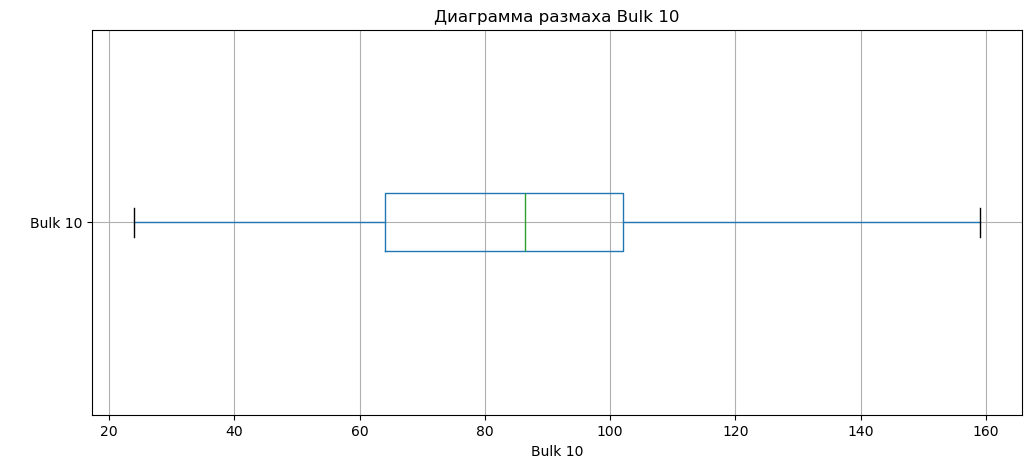

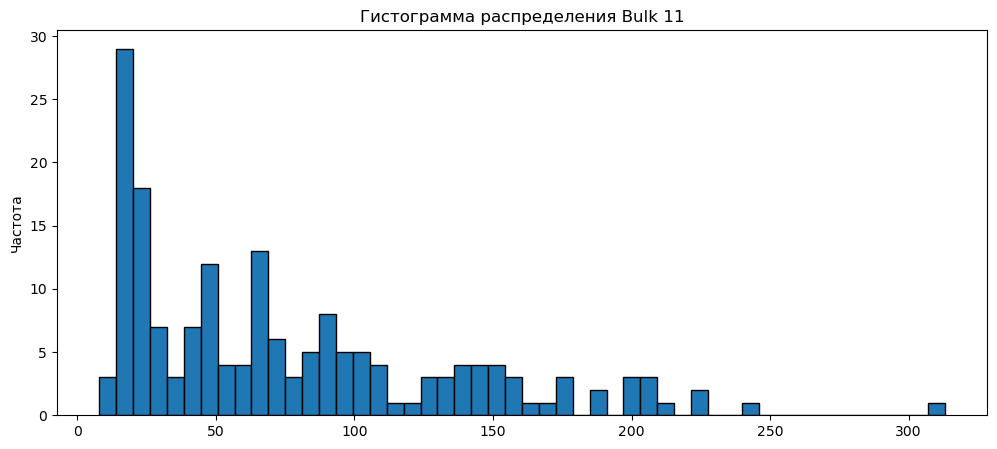

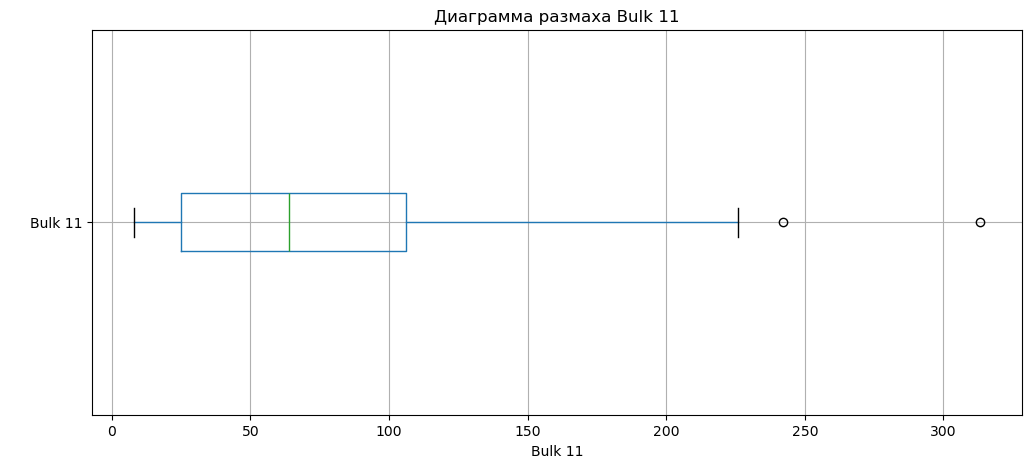

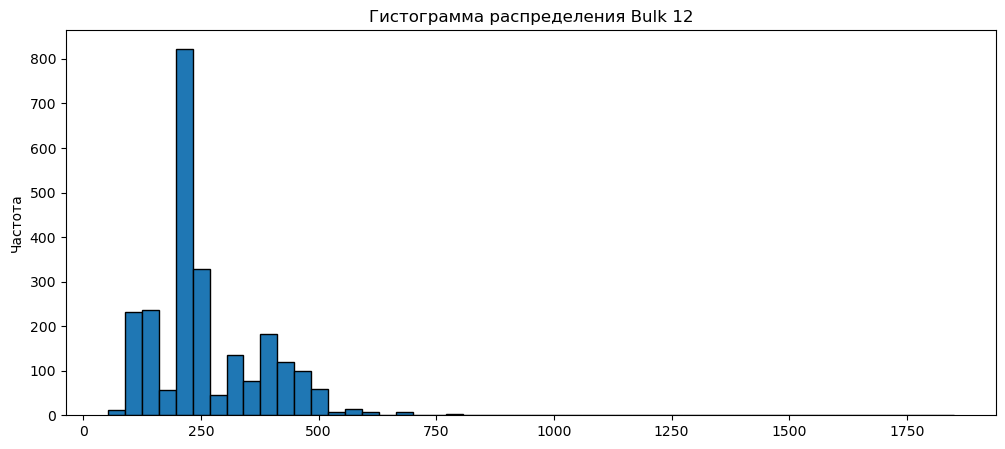

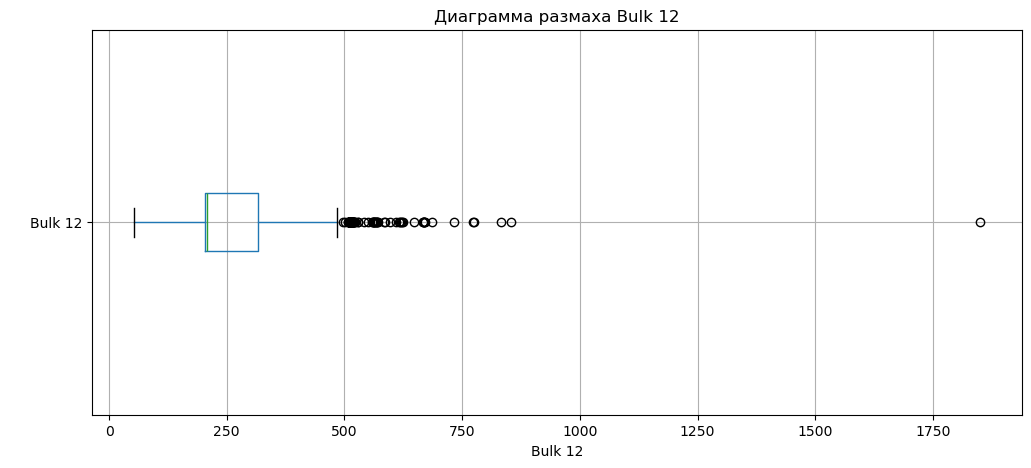

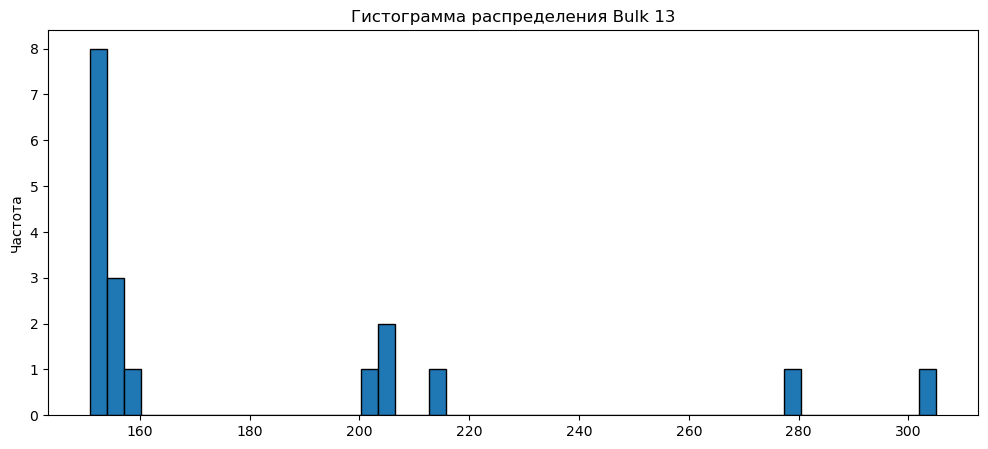

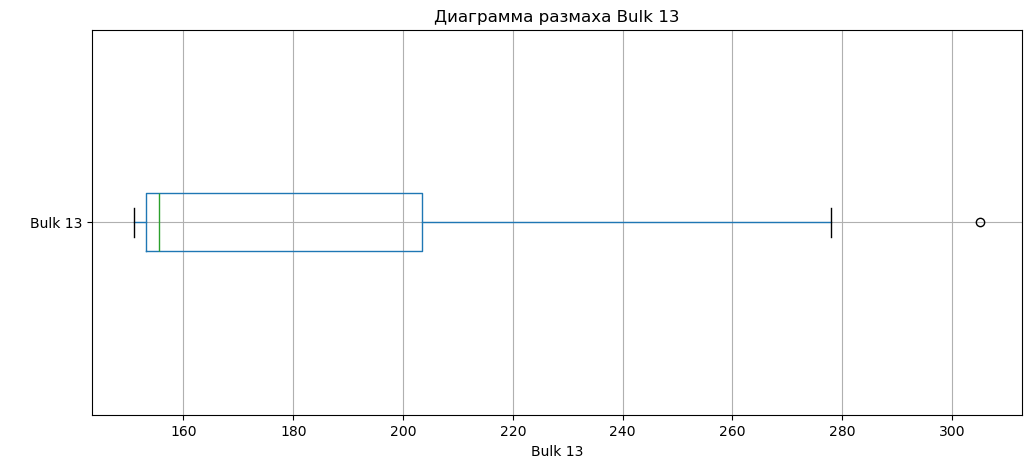

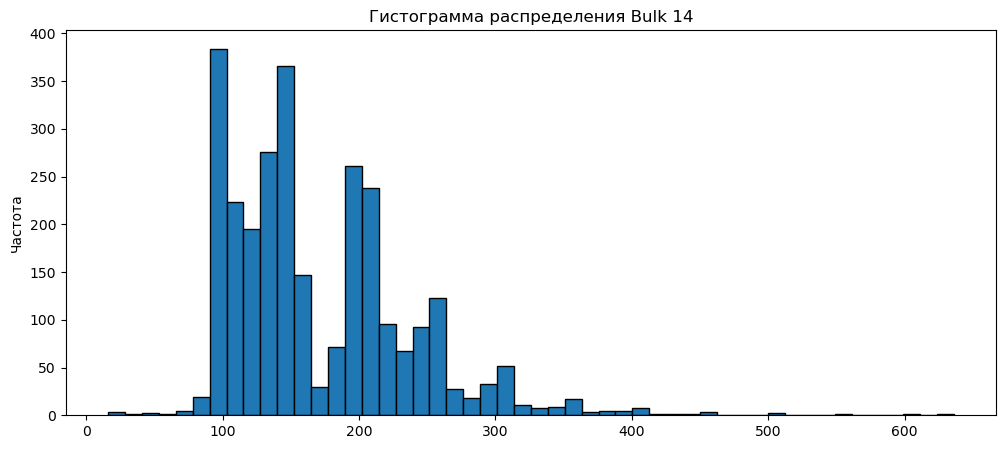

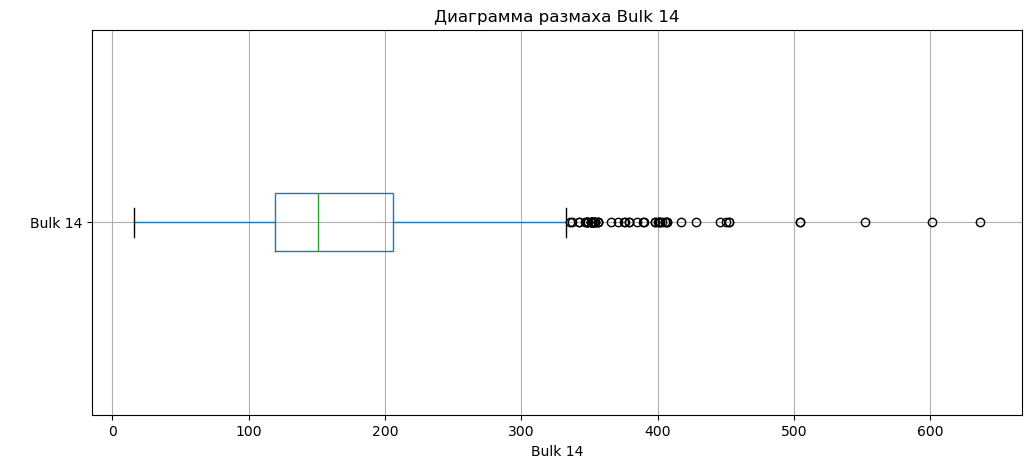

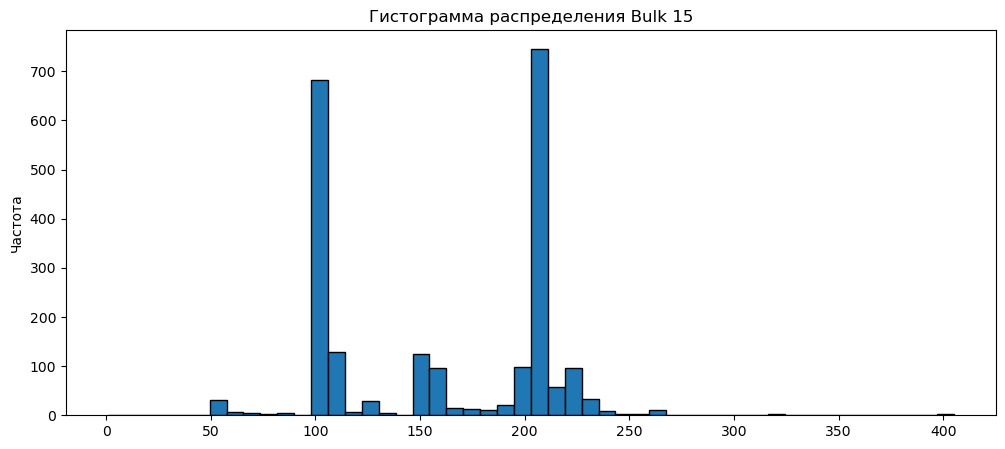

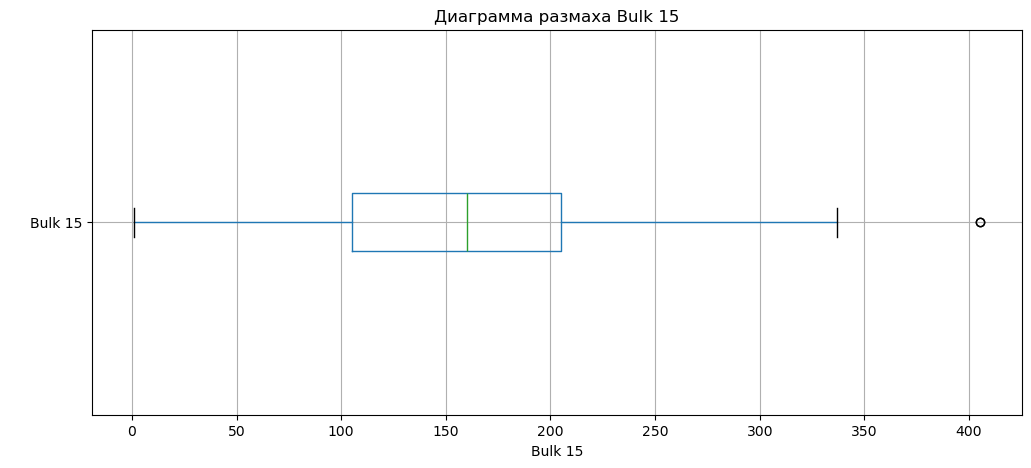

In [31]:
visual(data_bulk_new, 'data_bulk_new')

In [32]:
data_bulk_new.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


`Bulk 8` содержит только одно значение, данный столбец удалим в финальной таблице. \
`Bulk 12` максимальное значение 1849, на диаграмме размаха видим этот выброс. Пока оставим.

In [33]:
data_bulk_new[data_bulk_new['Bulk 12'] == 1849]

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
303,322,185.0,NaN,101.0,58.0,NaN,NaN,406.0,NaN,NaN,NaN,NaN,1849.0,NaN,636.0,NaN


In [34]:
# проверим долю пропусков
(data_bulk_new.isna().sum() / len(data_bulk_new) * 100).round(2)

key         0.00
Bulk 1     91.95
Bulk 2     99.30
Bulk 3     58.52
Bulk 4     67.59
Bulk 5     97.54
Bulk 6     81.59
Bulk 7     99.20
Bulk 8     99.97
Bulk 9     99.39
Bulk 10    94.38
Bulk 11    94.34
Bulk 12    21.70
Bulk 13    99.42
Bulk 14    10.32
Bulk 15    28.16
dtype: float64

`data_bulk_new` имеет много пропусков, но удалить их нельзя, заменим на "0". Данные реалистичны.

In [35]:
data_bulk = data_bulk_new.fillna(0)

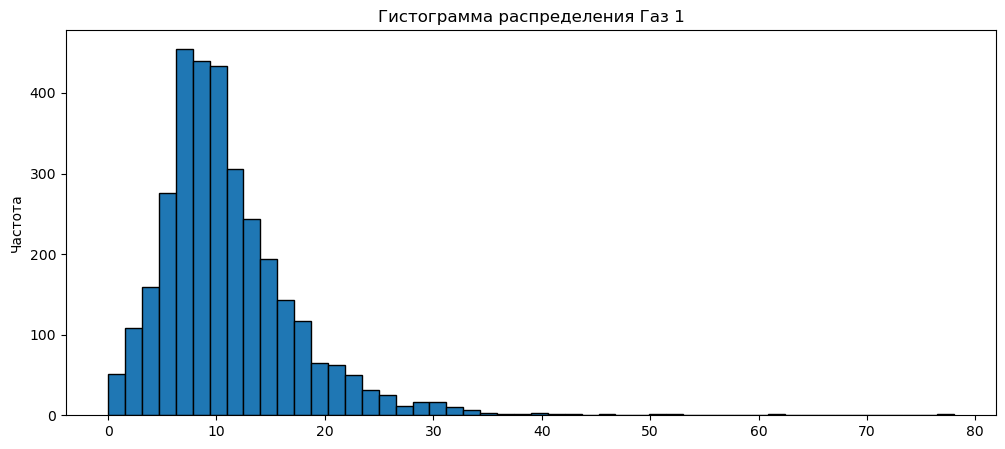

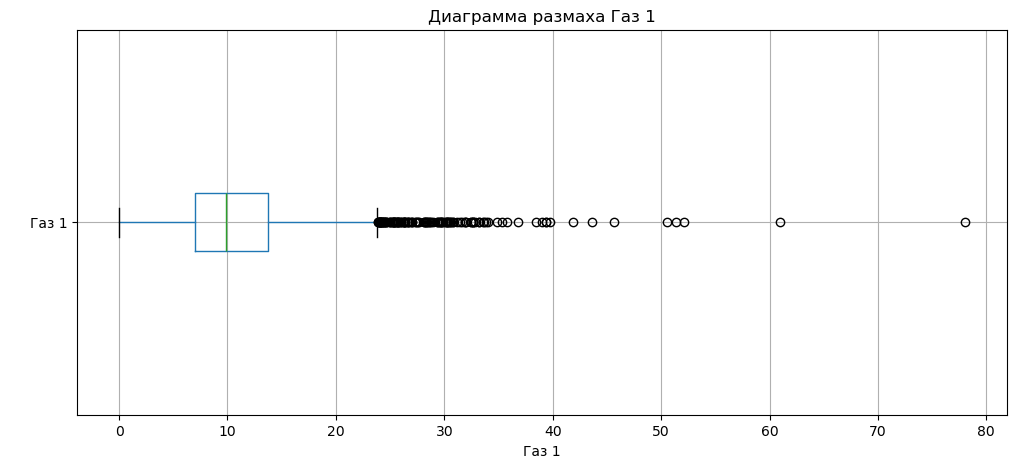

In [36]:
visual(data_gas_new, 'data_gas_new')

In [37]:
# проверим долю пропусков
(data_gas_new.isna().sum() / len(data_gas_new) * 100).round(2)

key      0.0
Газ 1    0.0
dtype: float64

In [38]:
data_gas = data_gas_new.copy()

`data_gas_new` не имеет пропусков, данные реалистичны.

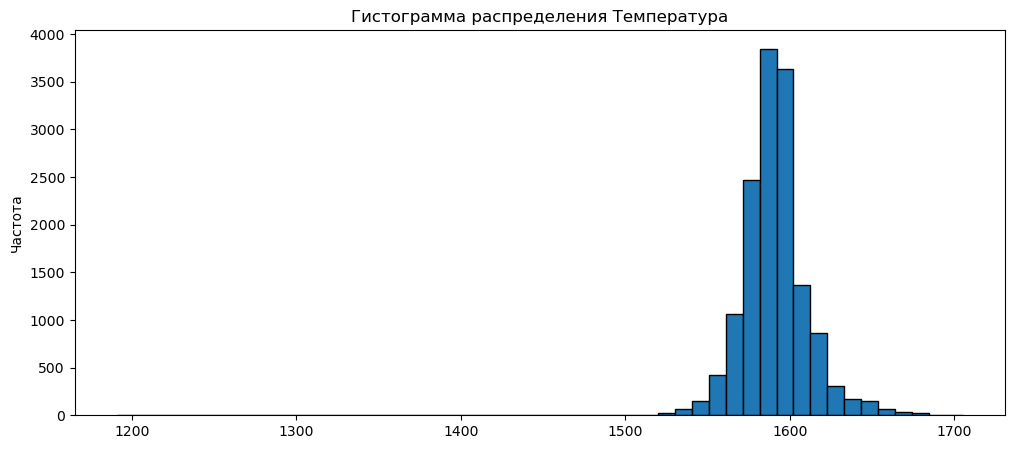

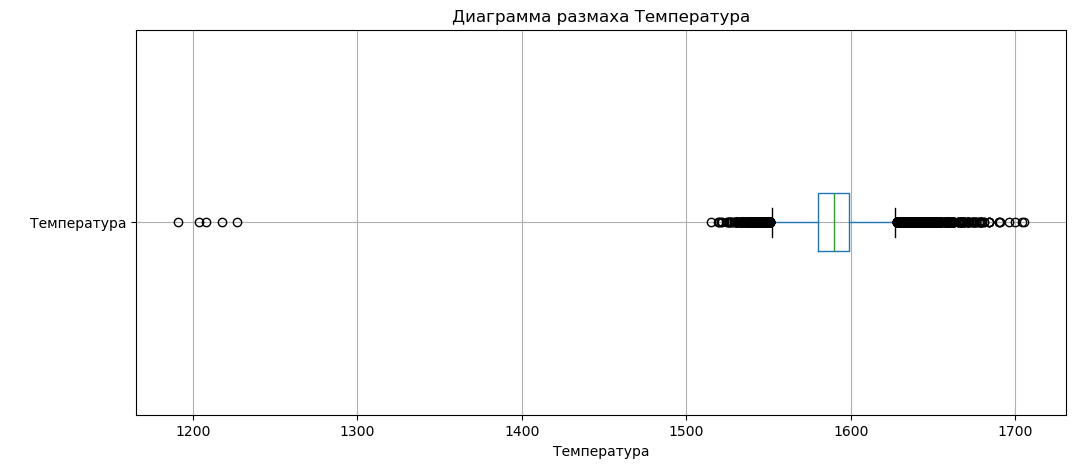

In [39]:
visual(data_temp_new, 'data_temp_new')

Удалим выбросы температуры менее 1400 градусов, так как при температуре меньше 1400 градусов сталь кристаллизуется.

In [40]:
data_temp_new[data_temp_new['Температура'].isna()]

,key,Время замера,Температура
13927,2500,2019-08-10 14:13:11,NaN
13928,2500,2019-08-10 14:18:12,NaN
13929,2500,2019-08-10 14:25:53,NaN
13930,2500,2019-08-10 14:29:39,NaN
13932,2501,2019-08-10 14:49:15,NaN
...,...,...,...
18087,3241,2019-09-06 16:55:01,NaN
18088,3241,2019-09-06 17:06:38,NaN
18089,3241,2019-09-06 17:21:48,NaN
18090,3241,2019-09-06 17:24:44,NaN


С номера партии 2500 температурных значений нет. Целевого признака нет, значит удалим партии начиная с 2500.

In [41]:
data_temp = data_temp_new.query('Температура >= 1400')
data_temp = data_temp.query('key < 2500')

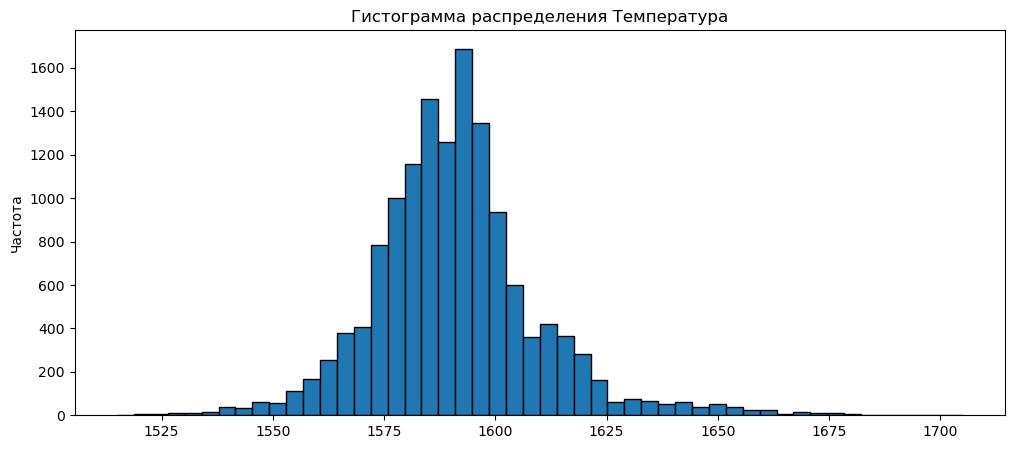

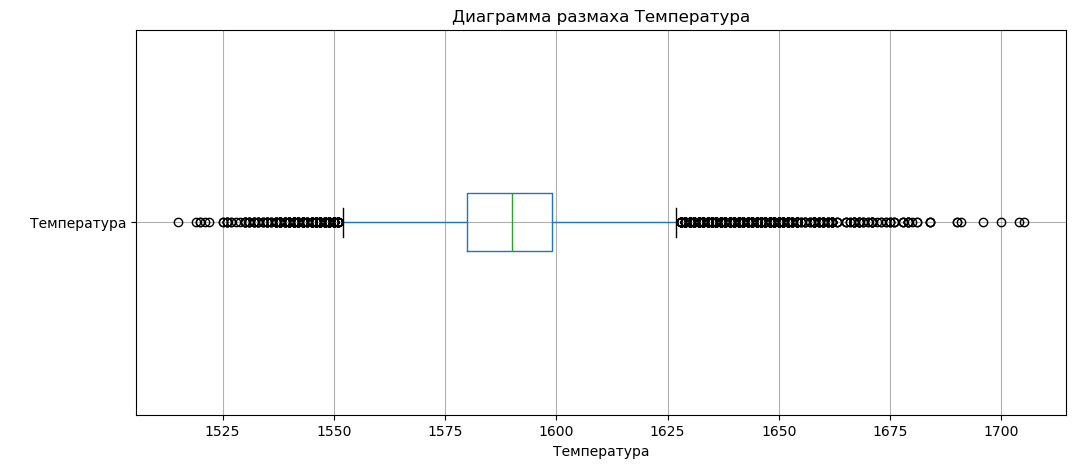

In [42]:
visual(data_temp, 'data_temp')

In [43]:
# проверим долю пропусков
(data_temp.isna().sum() / len(data_temp) * 100).round(2)

key             0.0
Время замера    0.0
Температура     0.0
dtype: float64

Пропусков нет, Данные реалистичны.

In [44]:
data_wire_new.describe()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


В данной таблице столбец "Wire 5" имеет одно значение. Удалим его после добавления новых признаков.

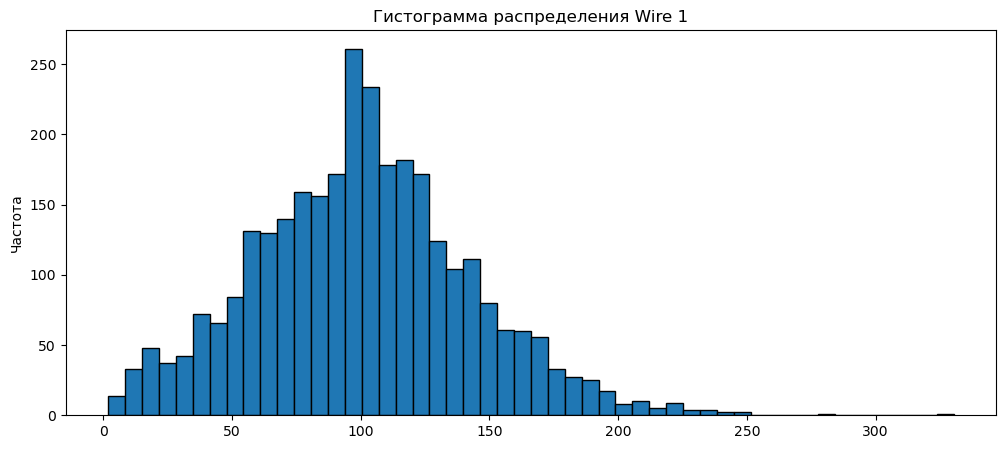

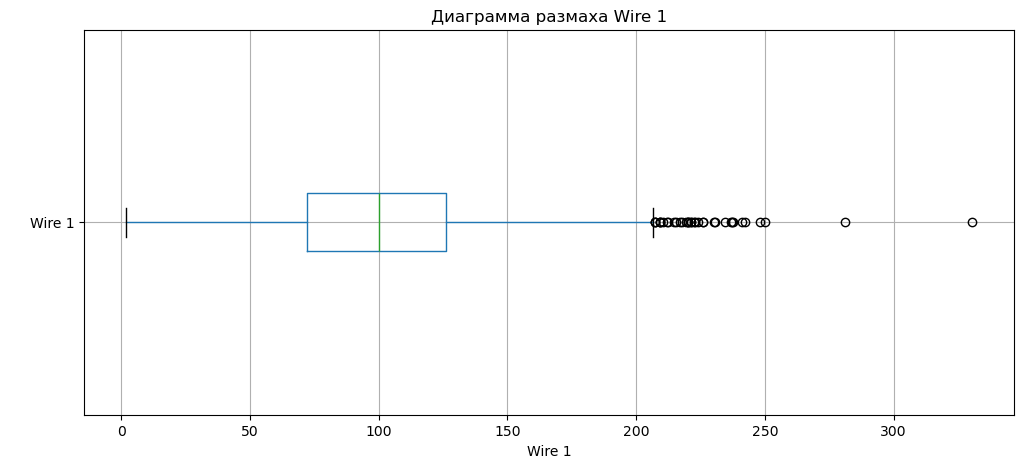

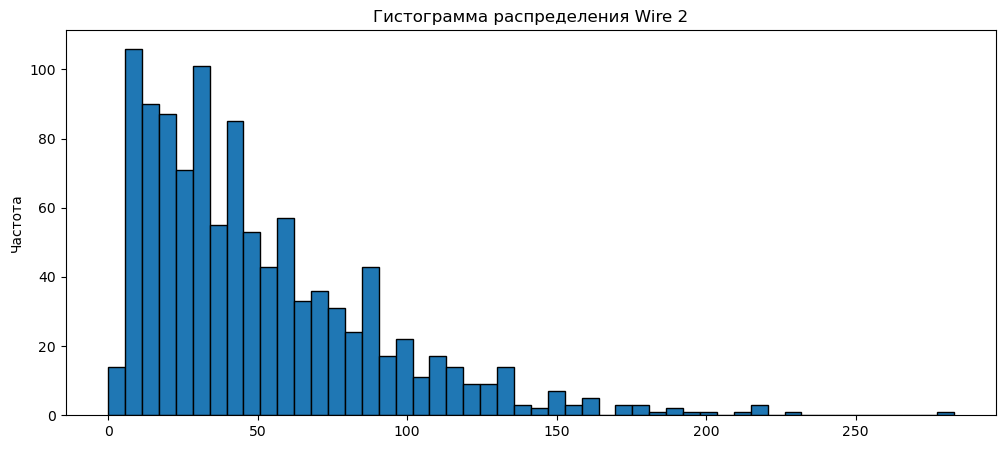

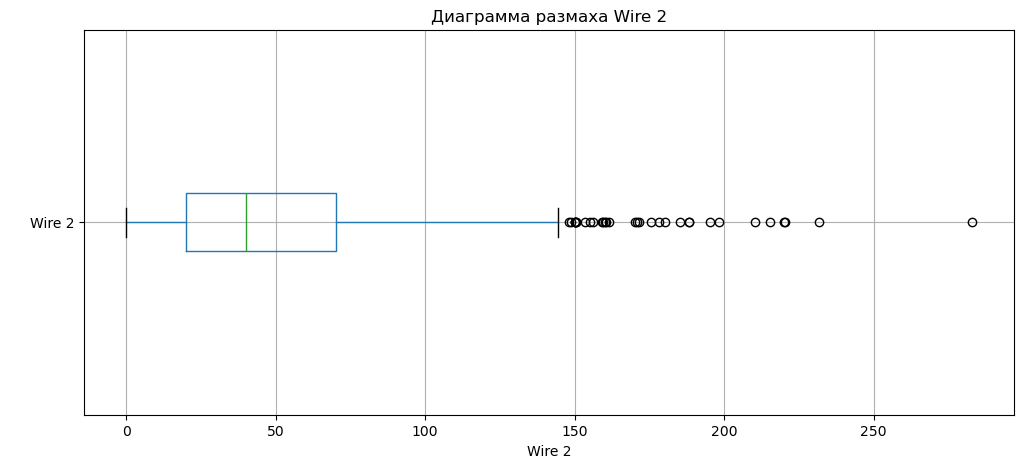

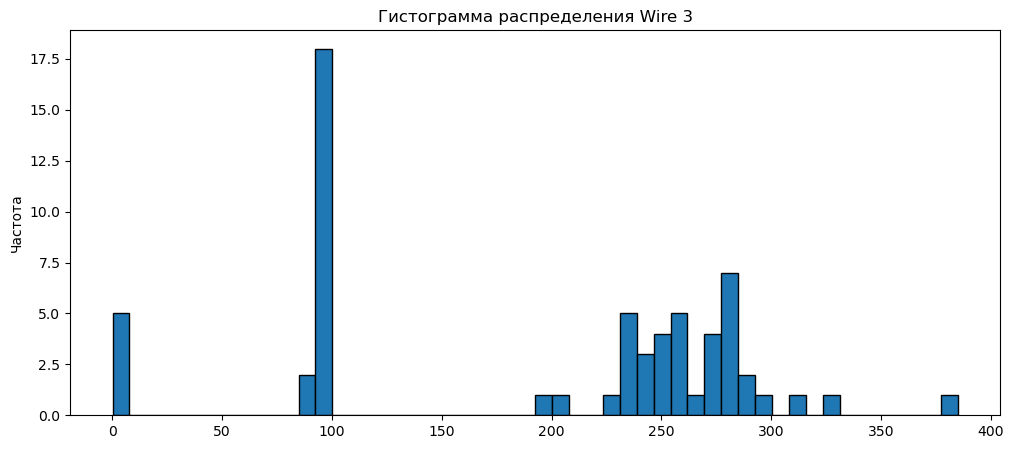

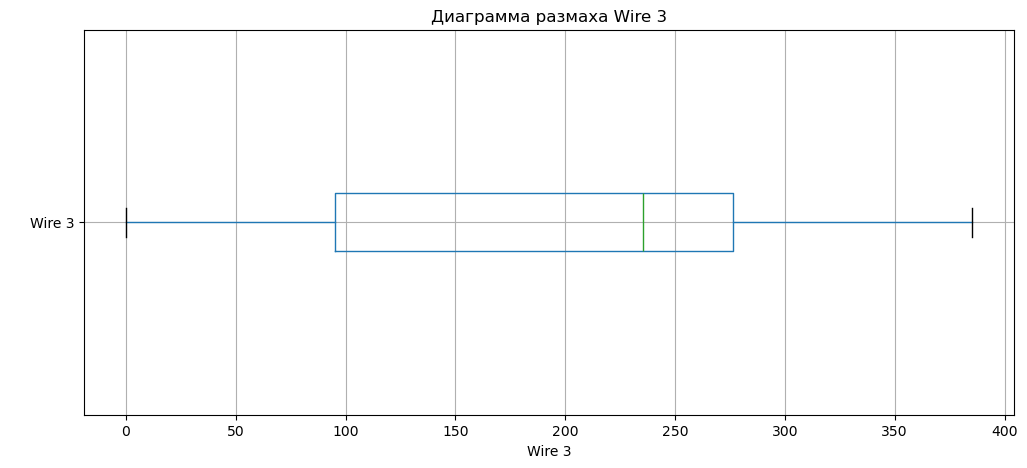

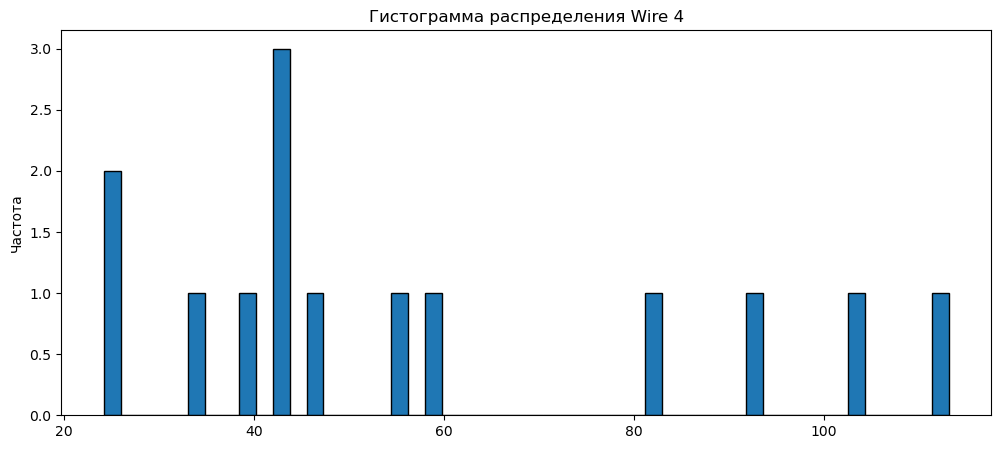

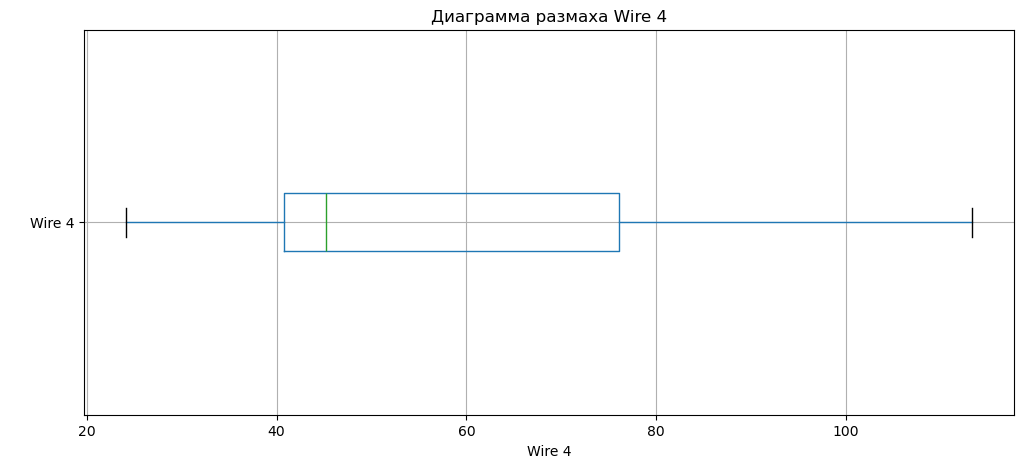

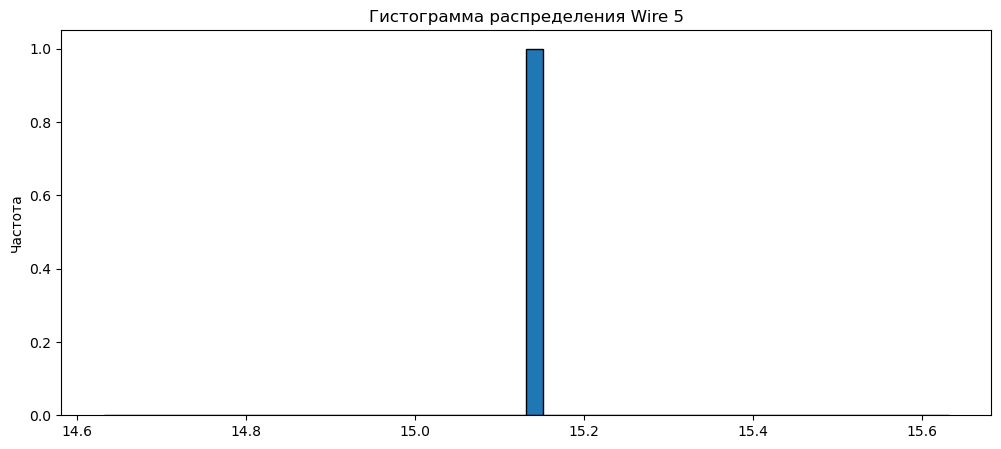

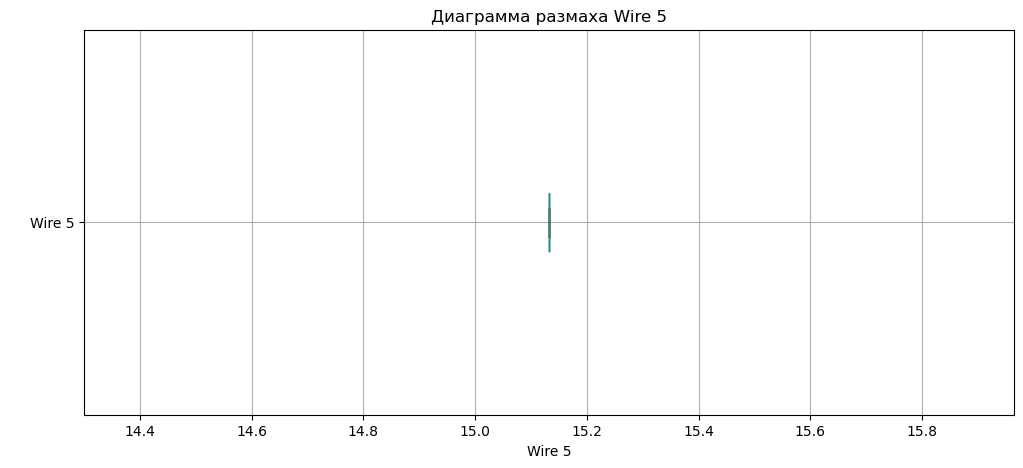

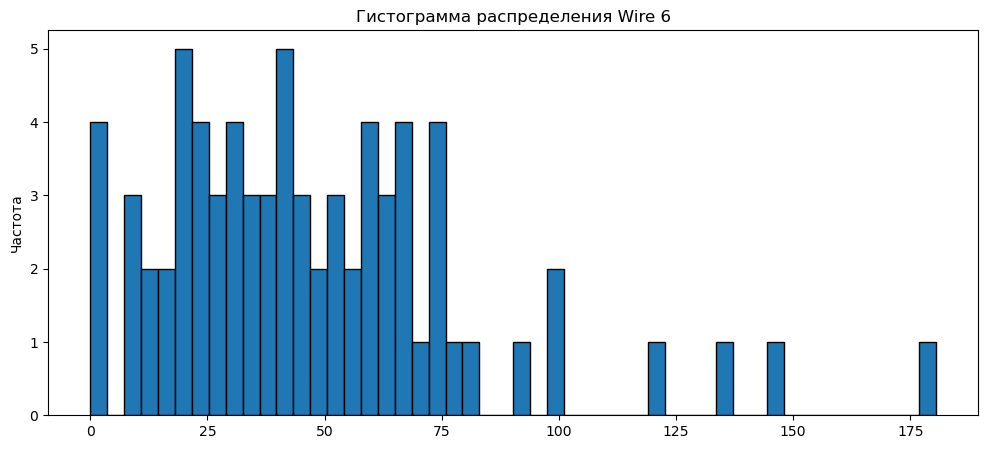

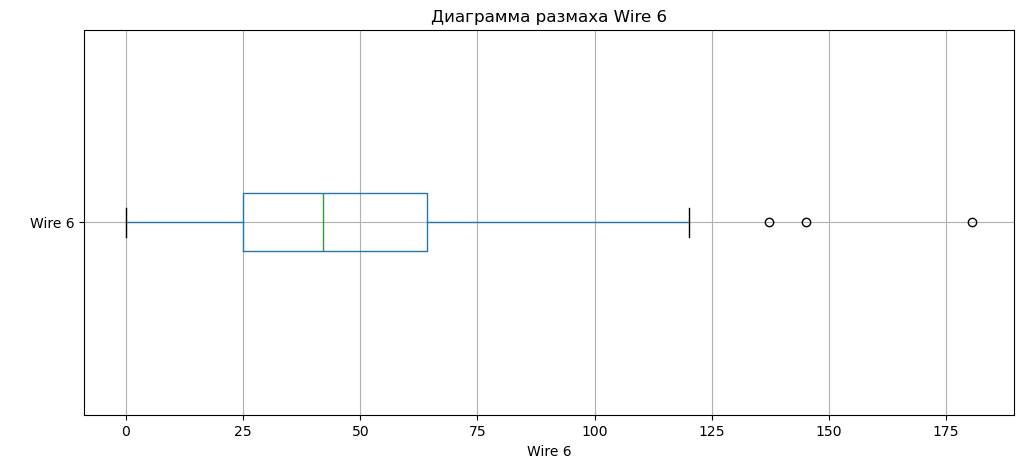

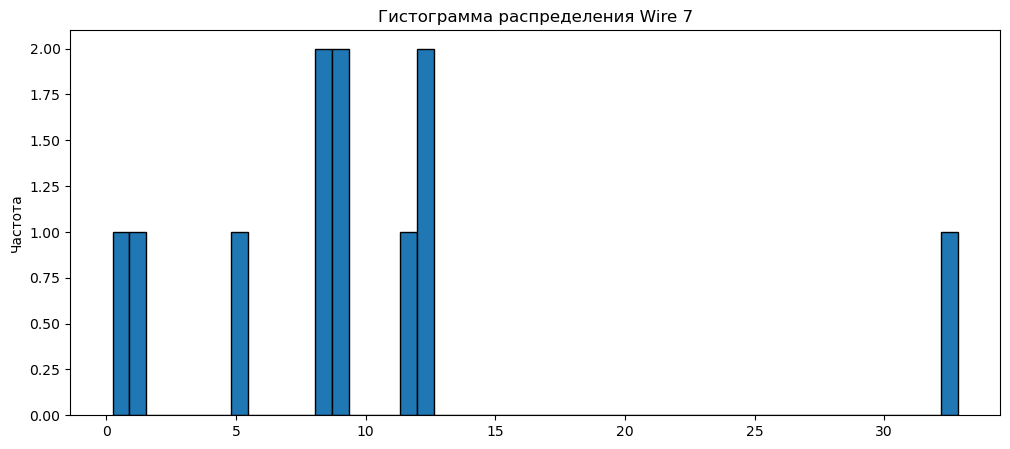

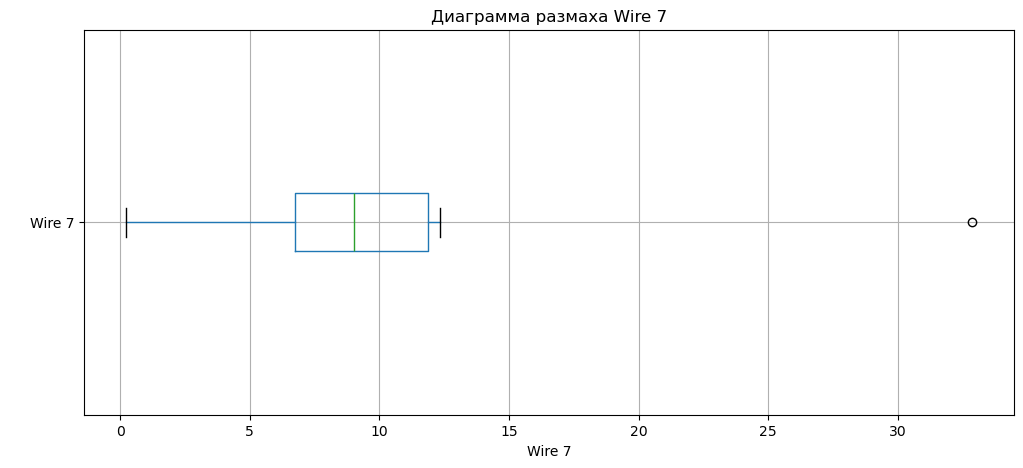

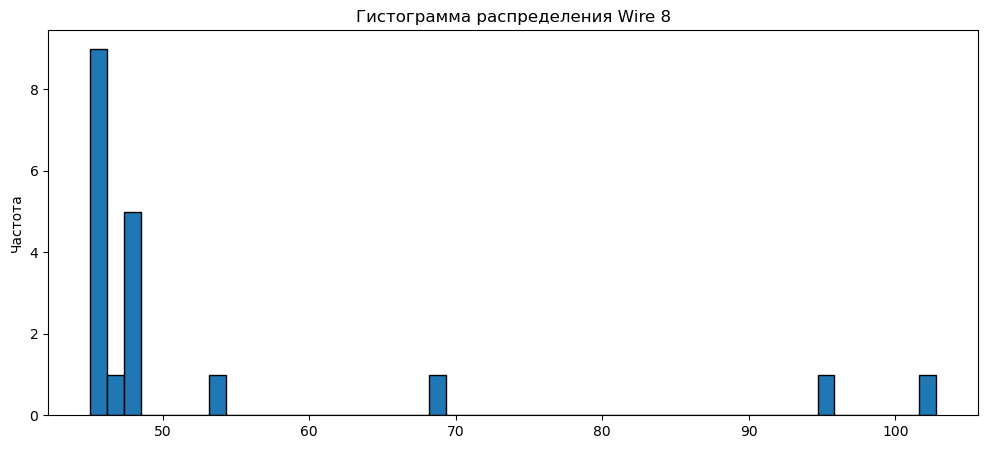

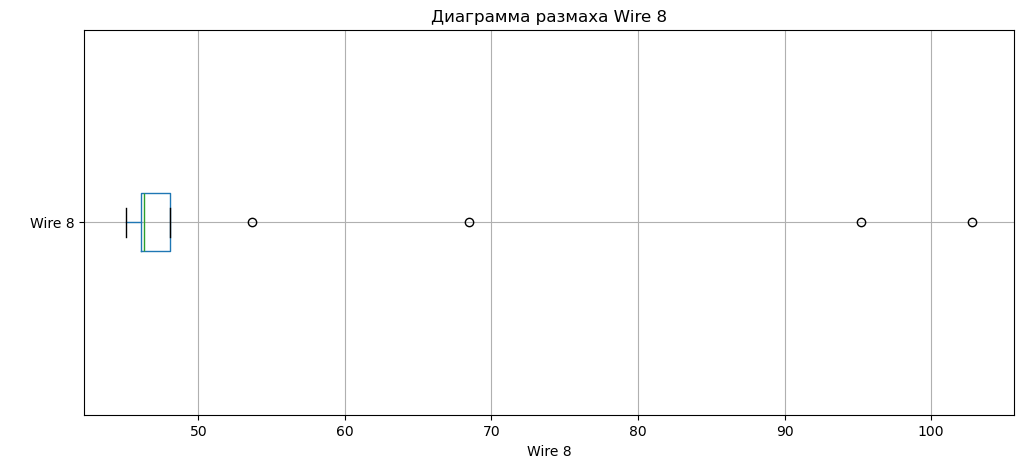

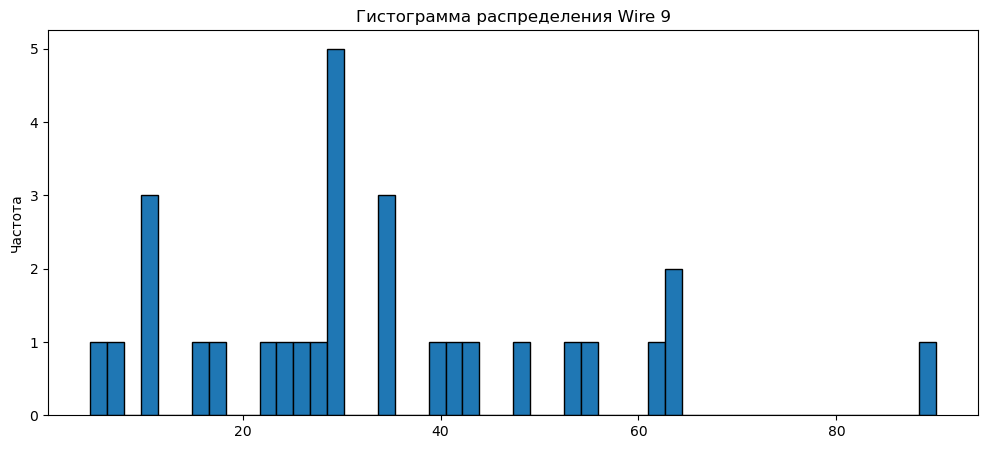

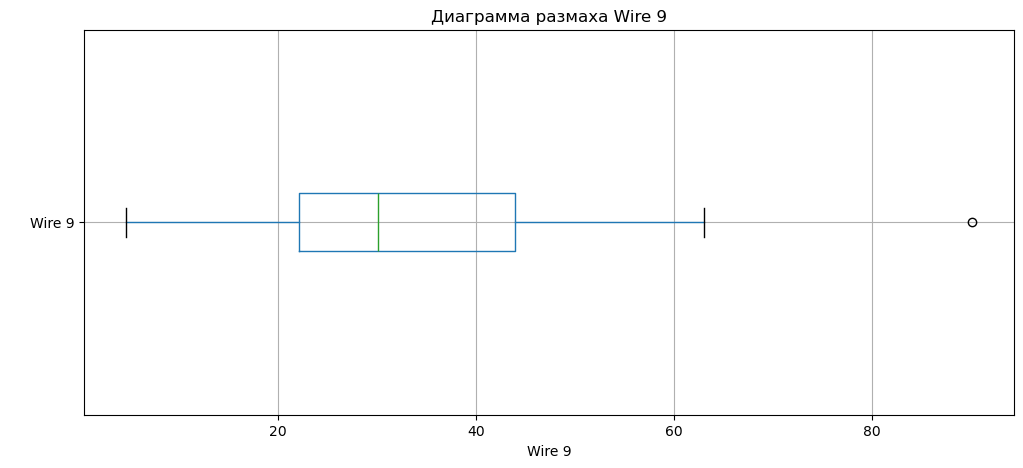

In [45]:
visual(data_wire_new, 'data_wire_new')

In [46]:
# проверим долю пропусков
(data_wire_new.isna().sum() / len(data_wire_new) * 100).round(2)

key        0.00
Wire 1     0.84
Wire 2    64.98
Wire 3    97.96
Wire 4    99.55
Wire 5    99.97
Wire 6    97.63
Wire 7    99.64
Wire 8    99.38
Wire 9    99.06
dtype: float64

В данных много пропусков, которые мы можем заполнить "0"

In [47]:
data_wire = data_wire_new.fillna(0)

**Вывод** \
Обработаны пропуски и выбросы.\
Пропуски заменили на "0", так как нет возможности заполнить данные.\
Данные о времени подачи сыпучих и проволочных материалов не используем.\
Далее добавим новые признаки и выделим целевой признак - температура на выходе.

## Шаг 3. Объединение данных

### Шаг 3.1 Новые признаки

Добавим ещё признаки: полная мощность, общее время нагрева, отношение активной мощности к реактивной.

Полная мощность

In [48]:
data_arc['Полная мощность'] = (data_arc['Реактивная мощность']**2 + data_arc['Активная мощность']**2)**0.5

C:\Users\1\AppData\Local\Temp\ipykernel_9092\1297341009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_arc['Полная мощность'] = (data_arc['Реактивная мощность']**2 + data_arc['Активная мощность']**2)**0.5


Общее время нагрева, которое переведём в секунды

In [49]:
data_arc['Общее время'] = data_arc['Конец нагрева дугой'] - data_arc['Начало нагрева дугой']
data_arc['Общее время'] = data_arc['Общее время'].dt.seconds

C:\Users\1\AppData\Local\Temp\ipykernel_9092\2262751410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_arc['Общее время'] = data_arc['Конец нагрева дугой'] - data_arc['Начало нагрева дугой']
C:\Users\1\AppData\Local\Temp\ipykernel_9092\2262751410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_arc['Общее время'] = data_arc['Общее время'].dt.seconds


Объединим партии.

In [50]:
data_arc = data_arc.drop(['Начало нагрева дугой', 'Конец нагрева дугой'], axis=1)

In [51]:
data_arc = data_arc.groupby(by='key').sum().reset_index()
data_arc.head()

,key,Активная мощность,Реактивная мощность,Полная мощность,Общее время
0,1,3.036730,2.142821,3.718736,1098
1,2,2.139408,1.453357,2.588349,811
2,3,4.063641,2.937457,5.019223,655
3,4,2.706489,2.056992,3.400038,741
4,5,2.252950,1.687991,2.816980,869


Добавим признак отношение активной мощности к реактивной мощности `ratio`

In [52]:
data_arc['ratio'] = data_arc['Активная мощность']/data_arc['Реактивная мощность']
data_arc.head()

,key,Активная мощность,Реактивная мощность,Полная мощность,Общее время,ratio
0,1,3.036730,2.142821,3.718736,1098,1.417165
1,2,2.139408,1.453357,2.588349,811,1.472046
2,3,4.063641,2.937457,5.019223,655,1.383387
3,4,2.706489,2.056992,3.400038,741,1.315751
4,5,2.252950,1.687991,2.816980,869,1.334693


Выделим целевой признак `final_temp`, также первое измерение температуры `first_temp`, также добавим признак разницу между первым и последним измерением температуры `diff_time` (хотя навряд ли  данный признак влияет, но проверим)

In [53]:
data_temp = data_temp.groupby(by='key').agg(['first', 'last']).reset_index()
data_temp.columns = ['key', 'first_time', 'final_time', 'first_temp', 'final_temp']
data_temp.head()

,key,first_time,final_time,first_temp,final_temp
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0


In [54]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   key         2477 non-null   int64         
 1   first_time  2477 non-null   datetime64[ns]
 2   final_time  2477 non-null   datetime64[ns]
 3   first_temp  2477 non-null   float64       
 4   final_temp  2477 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 96.9 KB


In [55]:
data_temp['final_time'] = pd.to_datetime(data_temp['final_time'])
data_temp['first_time'] = pd.to_datetime(data_temp['first_time'])

In [56]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   key         2477 non-null   int64         
 1   first_time  2477 non-null   datetime64[ns]
 2   final_time  2477 non-null   datetime64[ns]
 3   first_temp  2477 non-null   float64       
 4   final_temp  2477 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 96.9 KB


In [57]:
data_temp['diff_time'] = data_temp['final_time'] - data_temp['first_time']
data_temp['diff_time'] = data_temp['diff_time'].dt.seconds
data_temp.head()

,key,first_time,final_time,first_temp,final_temp,diff_time
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,1714
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,1265
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,1753
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,1220
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,1536


Добавим новый признак "общее количество присадок(сыпучих)" `total_bulk` и "общее количество присадок проволочных" `total_wire`

In [58]:
data_bulk['total_bulk'] = data_bulk.drop(columns=['key']).sum(axis=1)
data_bulk.head(3)

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,total_bulk
0,1,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,553.0
1,2,0.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,149.0,154.0,582.0
2,3,0.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,0.0,152.0,153.0,544.0


In [59]:
data_wire['total_wire'] = data_wire.drop(columns=['key']).sum(axis=1)
data_wire.head(3)

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,total_wire
0,1,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.059998
1,2,96.052315,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.052315
2,3,91.160157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,91.160157


### Шаг 3.2 Объединение таблиц

In [60]:
# объединение таблиц по ключу 'key' методом mergeисключая таблицы со временем
data = data_temp.merge(data_arc, on='key', how='inner')
data = data.merge(data_bulk, on='key', how='inner')
data = data.merge(data_gas, on='key', how='inner')
data = data.merge(data_wire, on='key', how='left')

In [61]:
data.head()

,key,first_time,final_time,first_temp,final_temp,diff_time,Активная мощность,Реактивная мощность,Полная мощность,Общее время,...,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,total_wire
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,1714,3.036730,2.142821,3.718736,1098,...,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.059998
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,1265,2.139408,1.453357,2.588349,811,...,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.052315
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,1753,4.063641,2.937457,5.019223,655,...,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,91.160157
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,1220,2.706489,2.056992,3.400038,741,...,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.063515
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,1536,2.252950,1.687991,2.816980,869,...,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,98.352796


In [62]:
# получение общей информации
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2404 entries, 0 to 2403
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   key                  2404 non-null   int64         
 1   first_time           2404 non-null   datetime64[ns]
 2   final_time           2404 non-null   datetime64[ns]
 3   first_temp           2404 non-null   float64       
 4   final_temp           2404 non-null   float64       
 5   diff_time            2404 non-null   int32         
 6   Активная мощность    2404 non-null   float64       
 7   Реактивная мощность  2404 non-null   float64       
 8   Полная мощность      2404 non-null   float64       
 9   Общее время          2404 non-null   int32         
 10  ratio                2404 non-null   float64       
 11  Bulk 1               2404 non-null   float64       
 12  Bulk 2               2404 non-null   float64       
 13  Bulk 3               2404 non-nul

**Вывод**\
Все признаки объединены в одну таблицу по партии. \
Добавлены новые признаки.

## Шаг 4. Исследовательский анализ и предобработка данных объединенного датафрейма

Переименуем названия столбцов

In [63]:
data_columns ={
    'Активная мощность': 'active_power',
    'Реактивная мощность': 'reactive_power',
    'Полная мощность': 'total_power',
    'Общее время': 'total_time',
    'Bulk 1': 'bulk_1',
    'Bulk 2': 'bulk_2',
    'Bulk 3': 'bulk_3',
    'Bulk 4': 'bulk_4',
    'Bulk 5': 'bulk_5',
    'Bulk 6': 'bulk_6',
    'Bulk 7': 'bulk_7',
    'Bulk 8': 'bulk_8',
    'Bulk 9': 'bulk_9',
    'Bulk 10': 'bulk_10',
    'Bulk 11': 'bulk_11',
    'Bulk 12': 'bulk_12',
    'Bulk 13': 'bulk_13',
    'Bulk 14': 'bulk_14',
    'Bulk 15': 'bulk_15',
    'Газ 1': 'gas_1',
    'Wire 1': 'wire_1',
    'Wire 2': 'wire_2',
    'Wire 3': 'wire_3',
    'Wire 4': 'wire_4',
    'Wire 5': 'wire_5',
    'Wire 6': 'wire_6',
    'Wire 7': 'wire_7',
    'Wire 8': 'wire_8',
    'Wire 9': 'wire_9'
}
data = data.rename(columns=data_columns)

Удалим столбцы с типом datetime, а также столбцы "bulk_8" и "wire_5", так как данный столбец содержит только одно значение (выявили в Шаге 2).

In [64]:
data = data.drop(columns=['first_time', 'final_time', 'bulk_8', 'wire_5'])

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2404 entries, 0 to 2403
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   key             2404 non-null   int64  
 1   first_temp      2404 non-null   float64
 2   final_temp      2404 non-null   float64
 3   diff_time       2404 non-null   int32  
 4   active_power    2404 non-null   float64
 5   reactive_power  2404 non-null   float64
 6   total_power     2404 non-null   float64
 7   total_time      2404 non-null   int32  
 8   ratio           2404 non-null   float64
 9   bulk_1          2404 non-null   float64
 10  bulk_2          2404 non-null   float64
 11  bulk_3          2404 non-null   float64
 12  bulk_4          2404 non-null   float64
 13  bulk_5          2404 non-null   float64
 14  bulk_6          2404 non-null   float64
 15  bulk_7          2404 non-null   float64
 16  bulk_9          2404 non-null   float64
 17  bulk_10         2404 non-null   f

Удалим пропуски (предварительно, сделав копию таблицы)

In [66]:
data_final = data.copy()

In [67]:
data_final = data_final.dropna()

In [68]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2328 entries, 0 to 2403
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   key             2328 non-null   int64  
 1   first_temp      2328 non-null   float64
 2   final_temp      2328 non-null   float64
 3   diff_time       2328 non-null   int32  
 4   active_power    2328 non-null   float64
 5   reactive_power  2328 non-null   float64
 6   total_power     2328 non-null   float64
 7   total_time      2328 non-null   int32  
 8   ratio           2328 non-null   float64
 9   bulk_1          2328 non-null   float64
 10  bulk_2          2328 non-null   float64
 11  bulk_3          2328 non-null   float64
 12  bulk_4          2328 non-null   float64
 13  bulk_5          2328 non-null   float64
 14  bulk_6          2328 non-null   float64
 15  bulk_7          2328 non-null   float64
 16  bulk_9          2328 non-null   float64
 17  bulk_10         2328 non-null   float6

In [69]:
data_final.isna().sum()

key               0
first_temp        0
final_temp        0
diff_time         0
active_power      0
reactive_power    0
total_power       0
total_time        0
ratio             0
bulk_1            0
bulk_2            0
bulk_3            0
bulk_4            0
bulk_5            0
bulk_6            0
bulk_7            0
bulk_9            0
bulk_10           0
bulk_11           0
bulk_12           0
bulk_13           0
bulk_14           0
bulk_15           0
total_bulk        0
gas_1             0
wire_1            0
wire_2            0
wire_3            0
wire_4            0
wire_6            0
wire_7            0
wire_8            0
wire_9            0
total_wire        0
dtype: int64

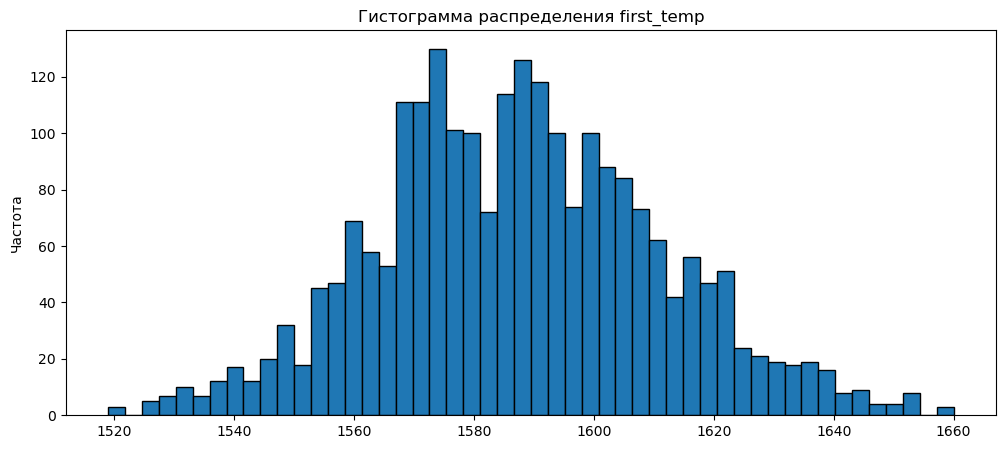

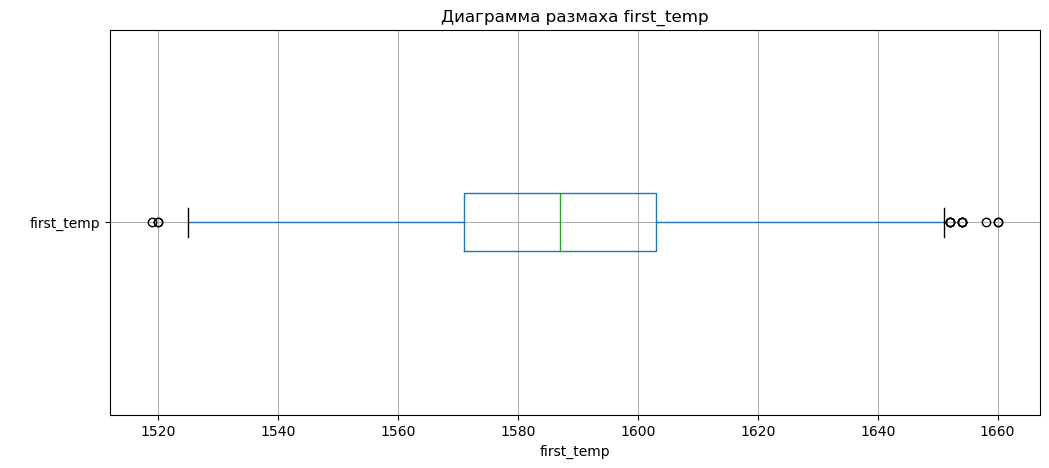

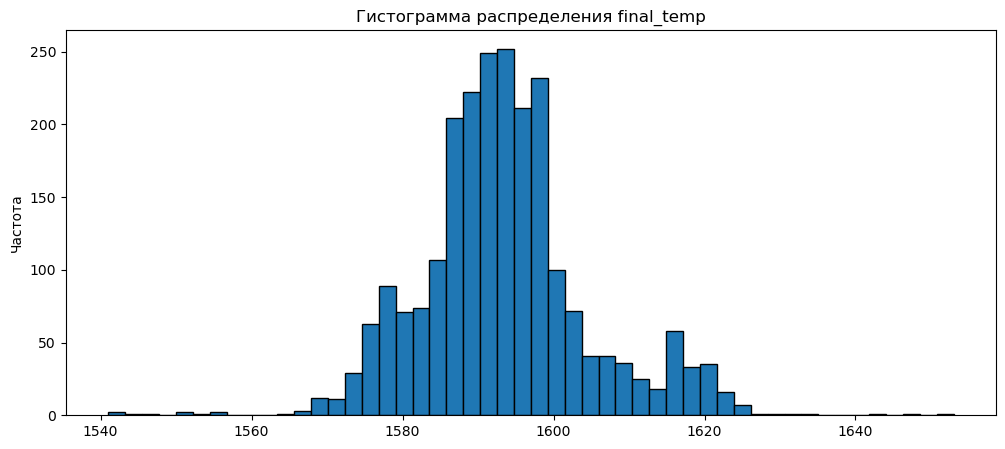

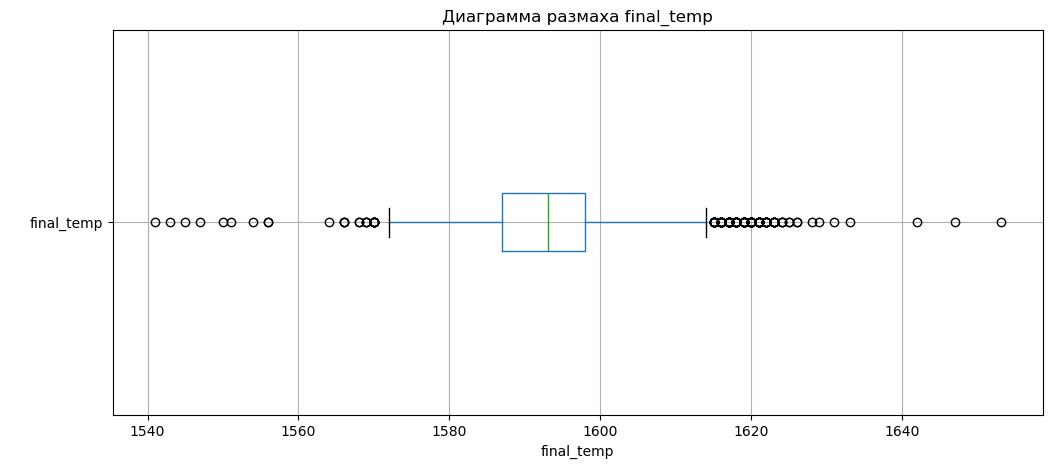

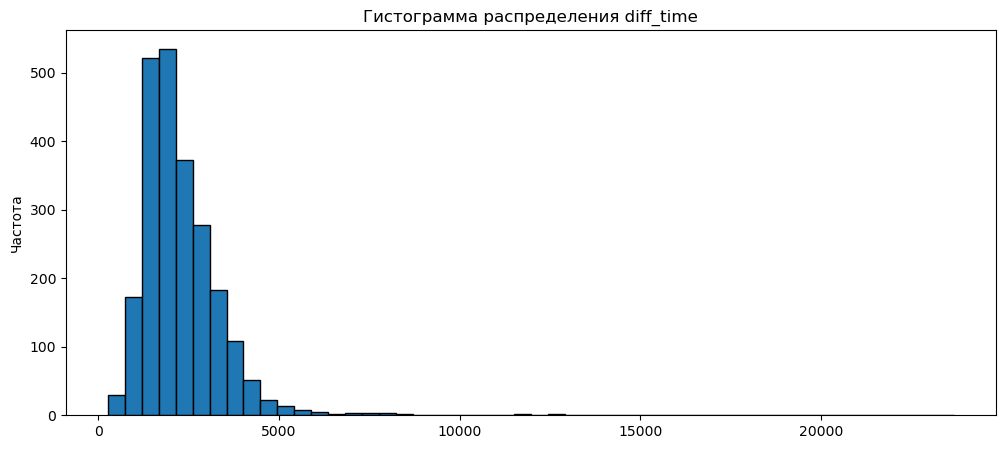

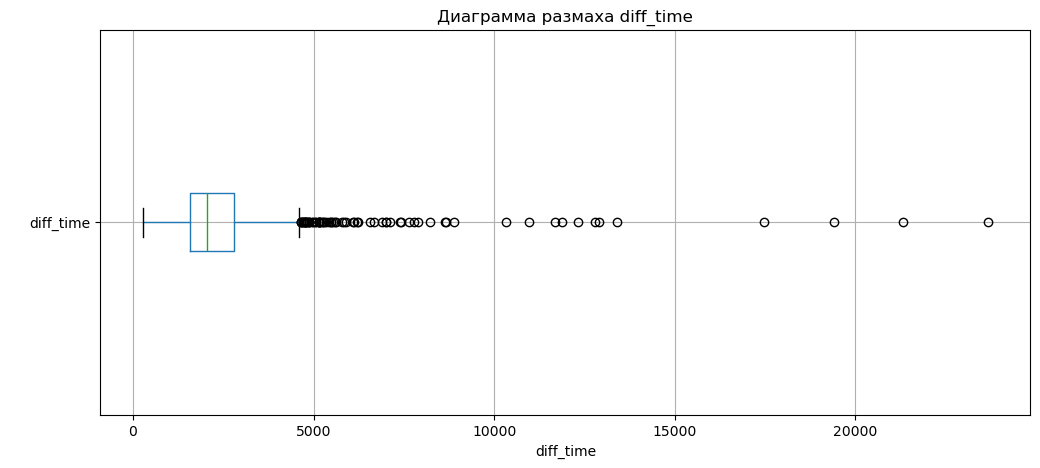

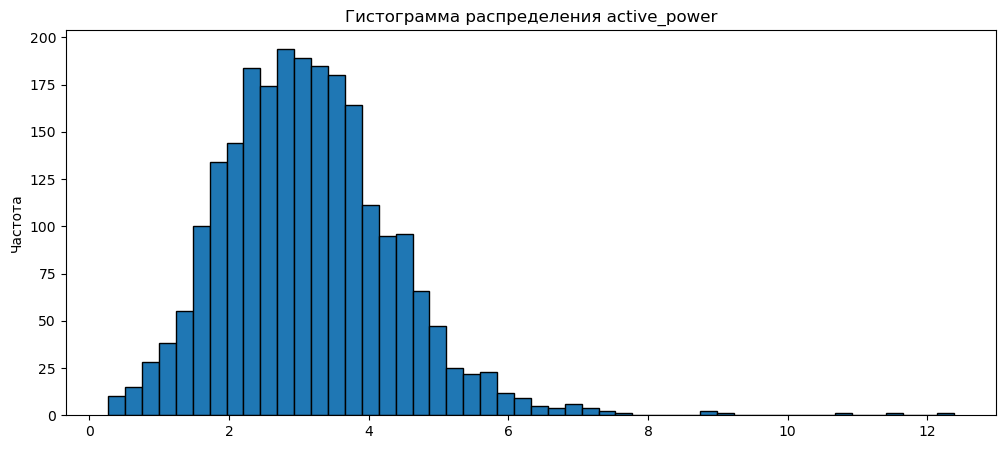

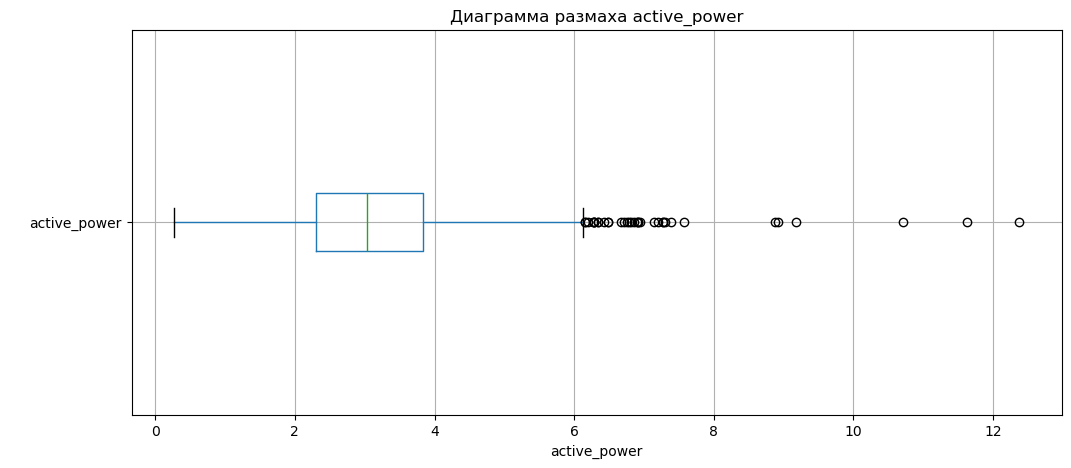

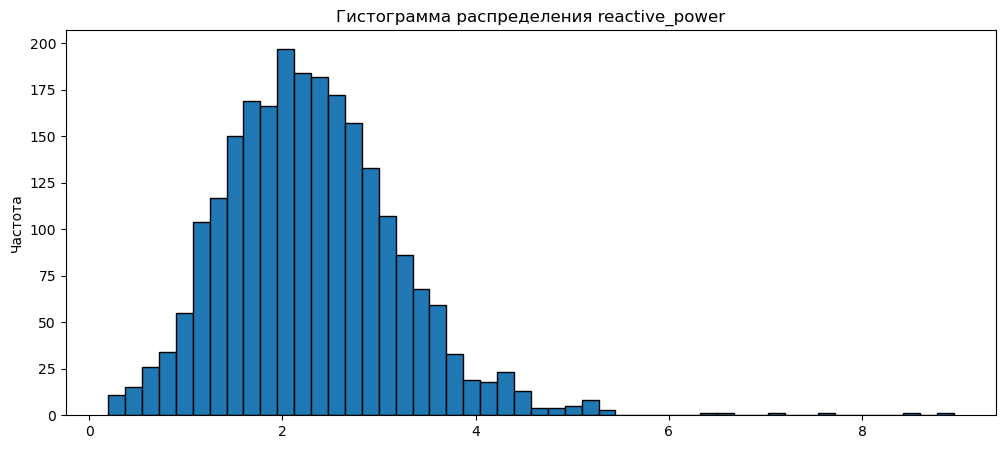

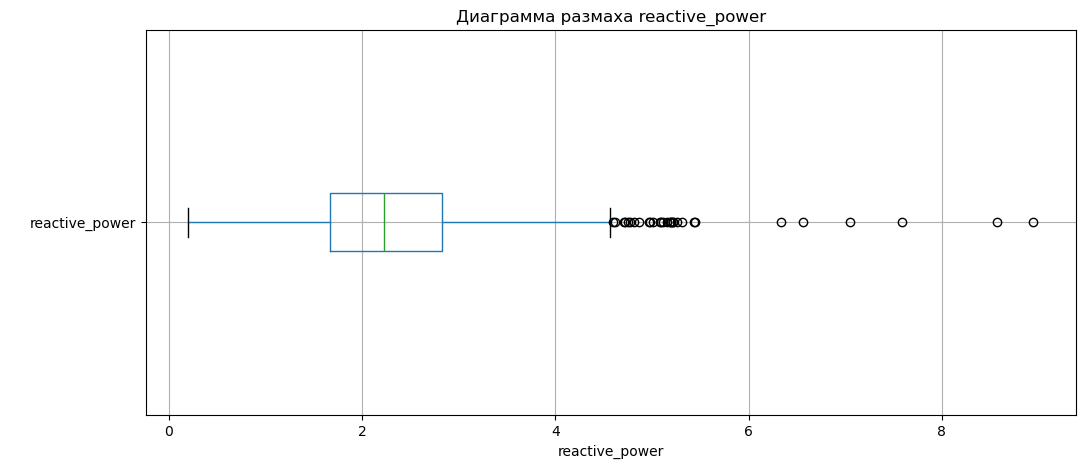

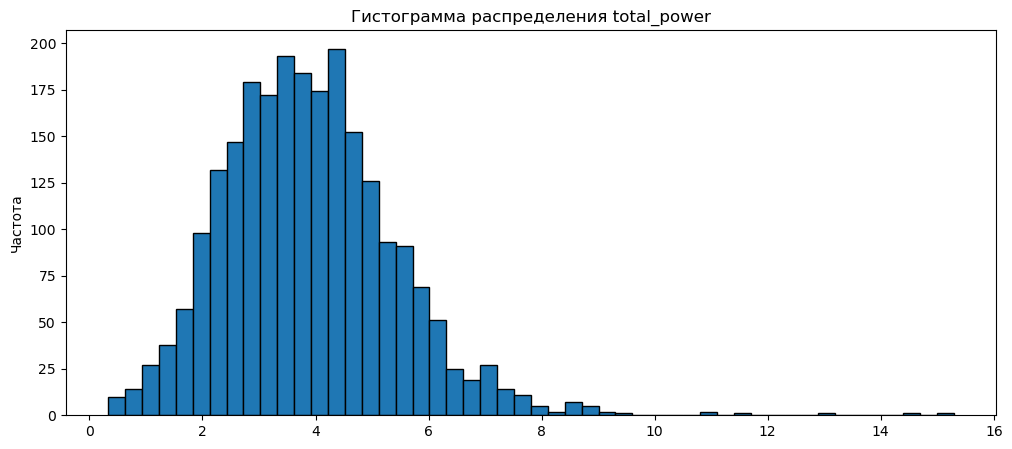

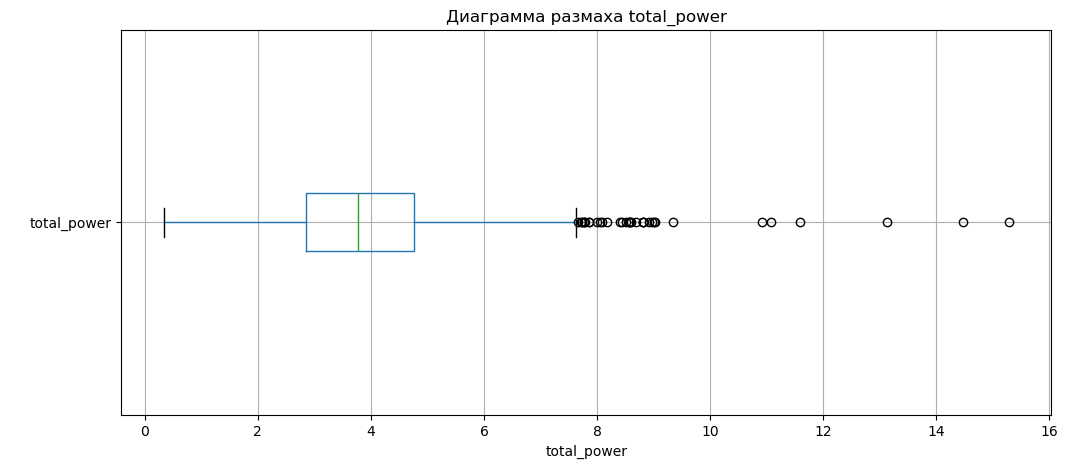

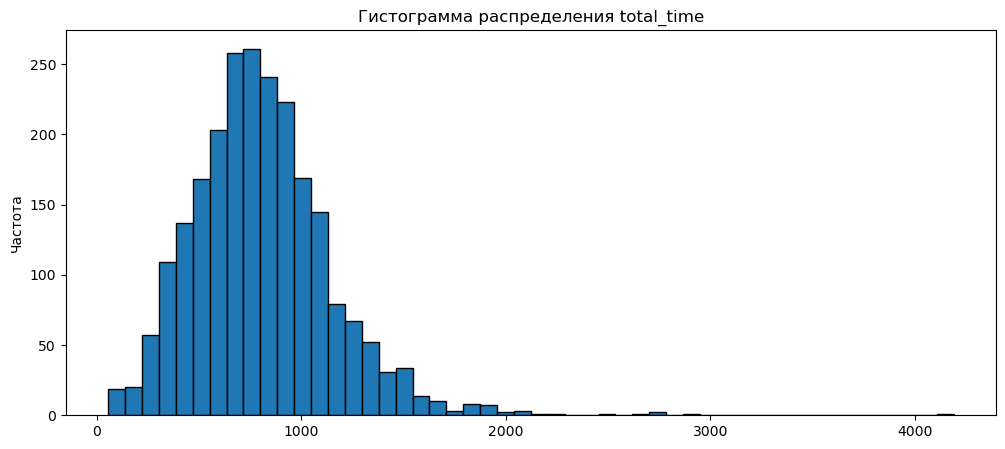

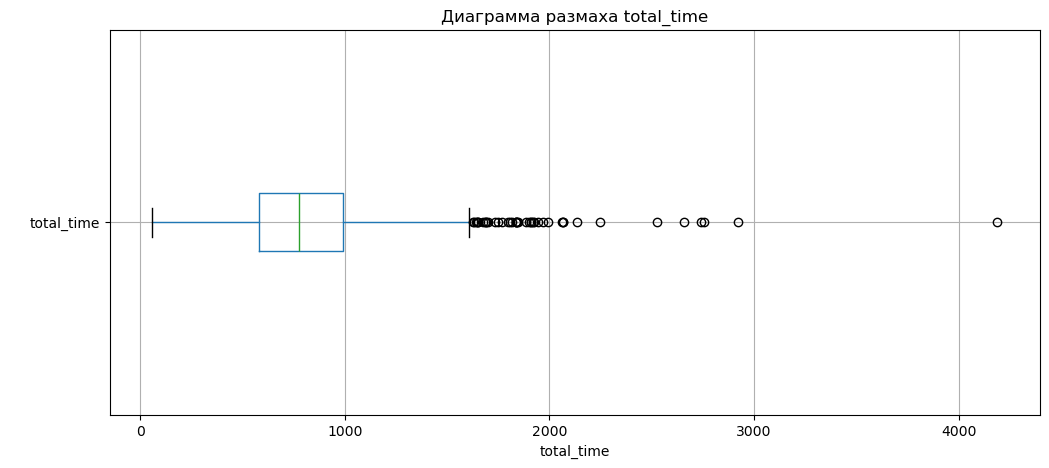

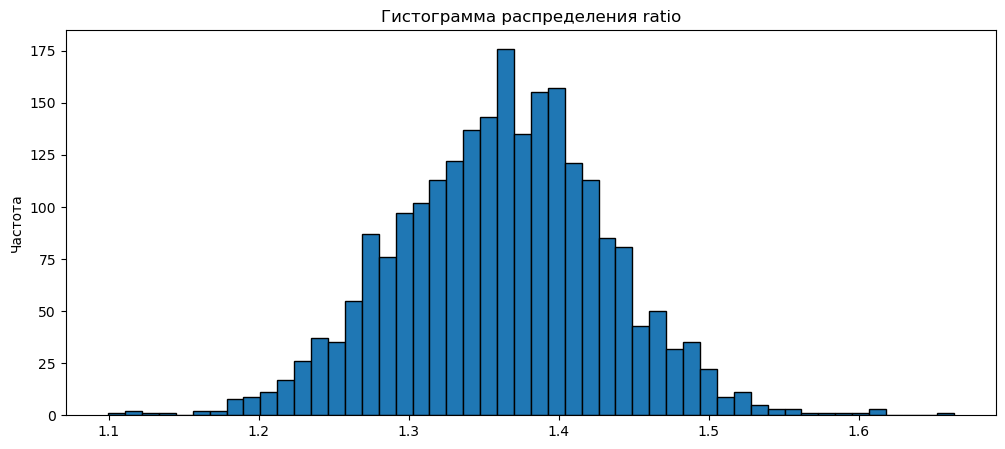

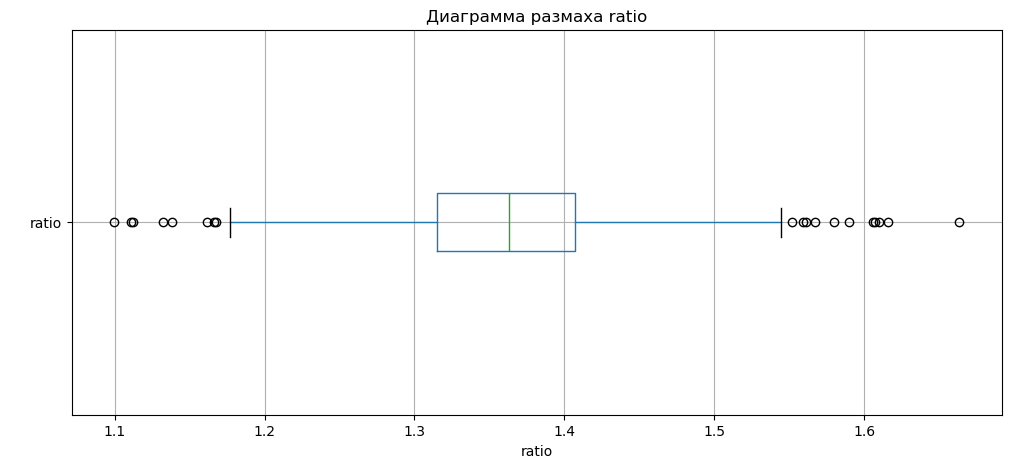

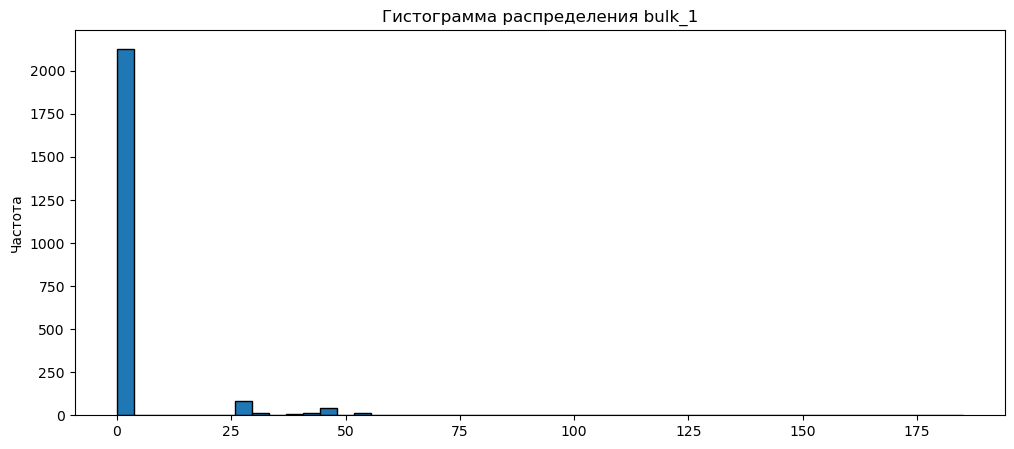

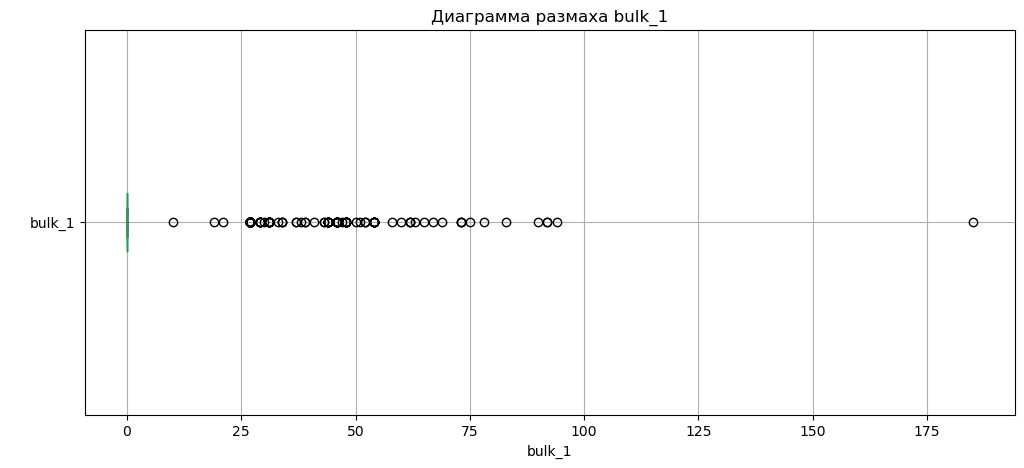

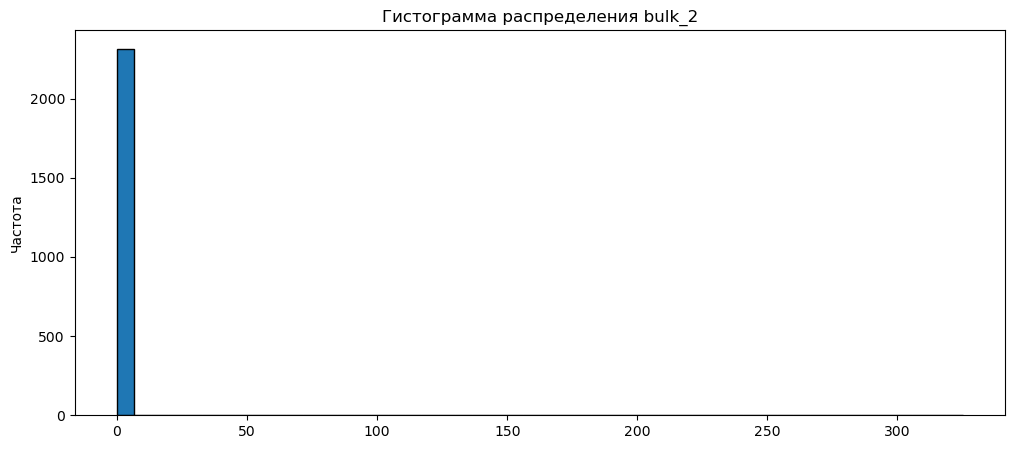

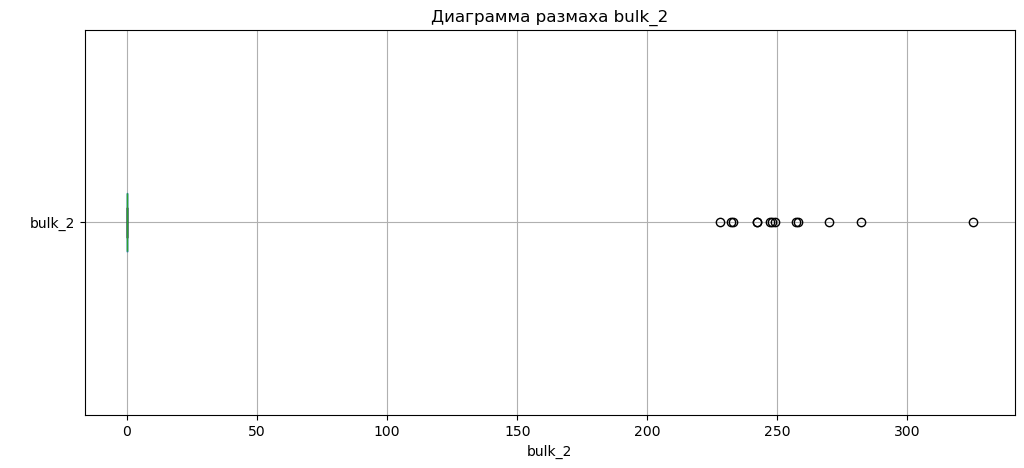

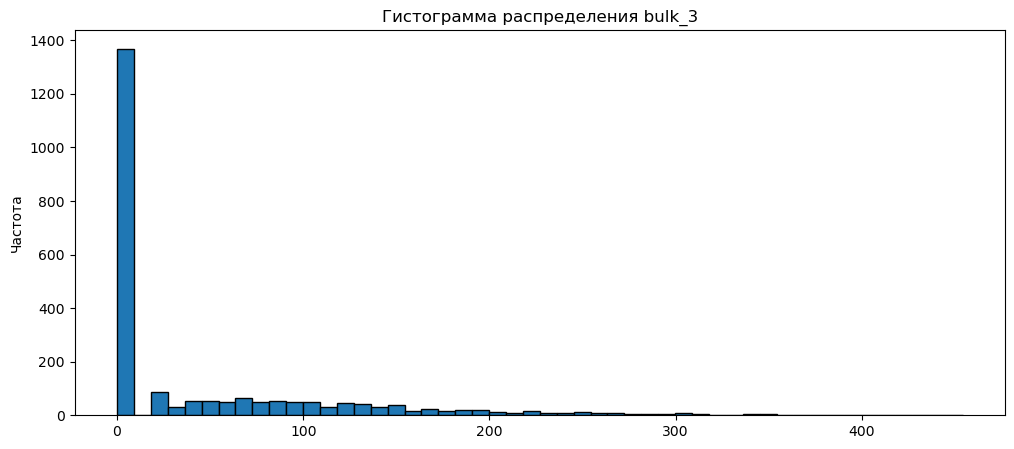

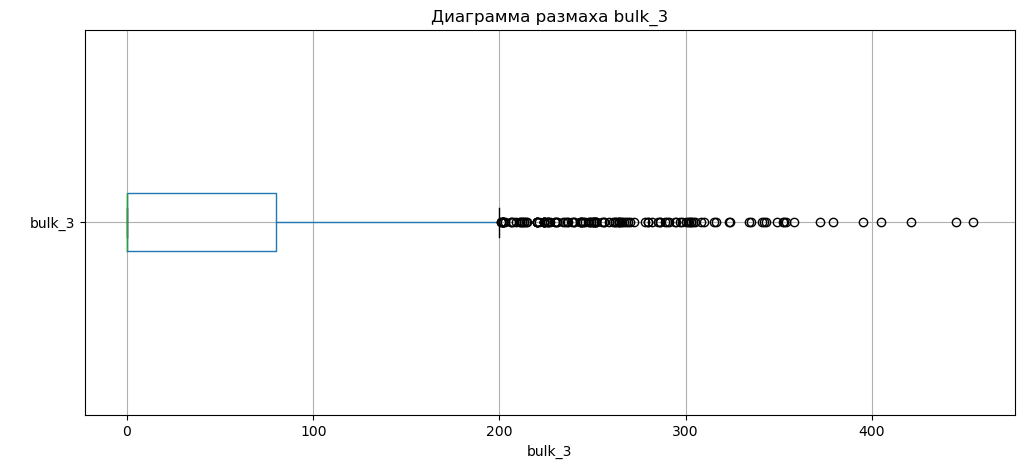

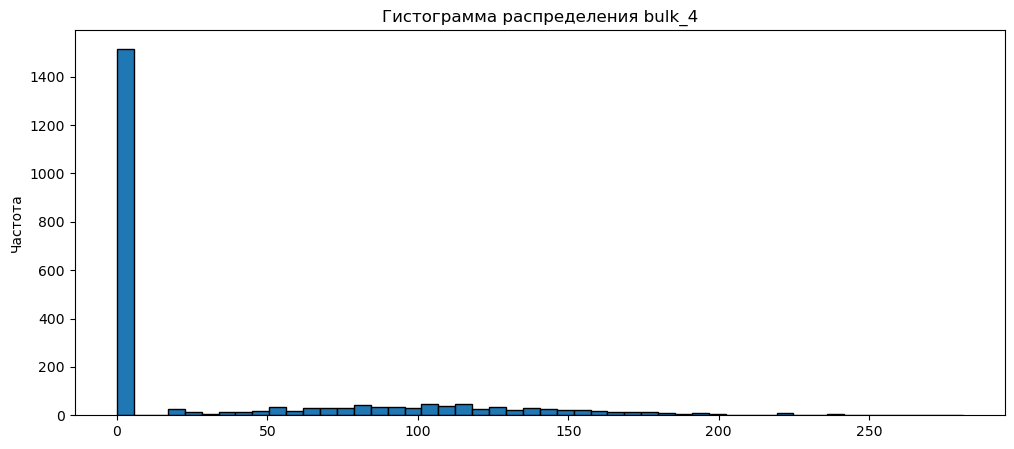

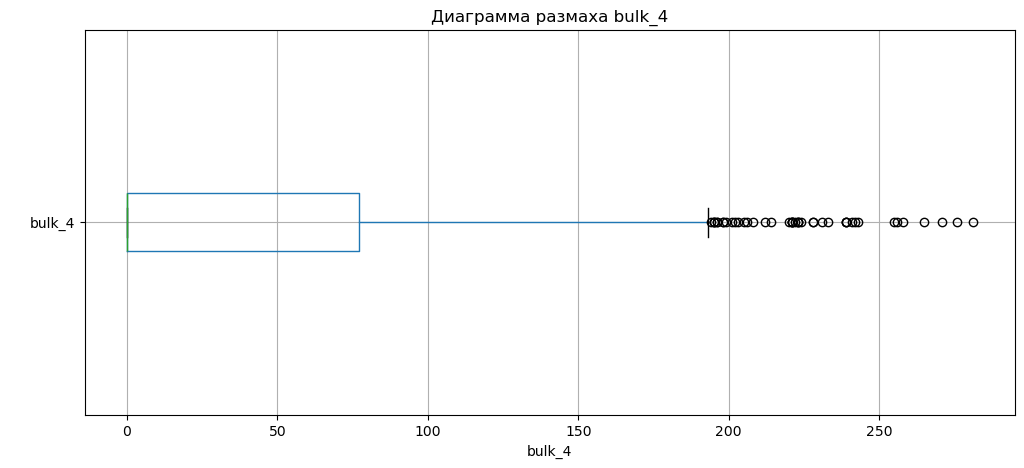

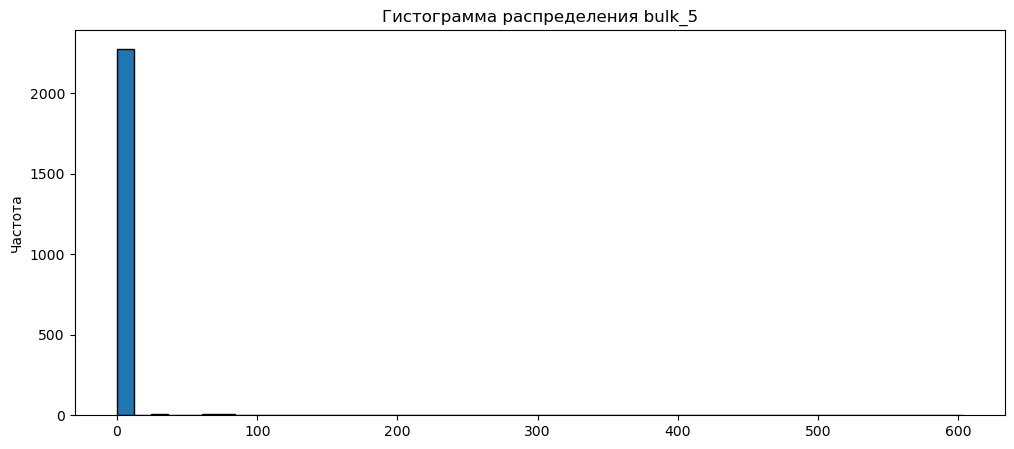

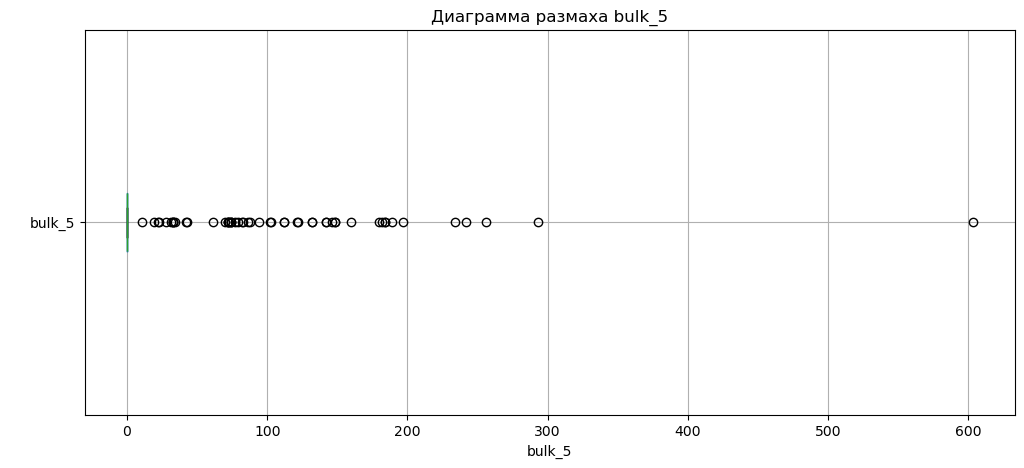

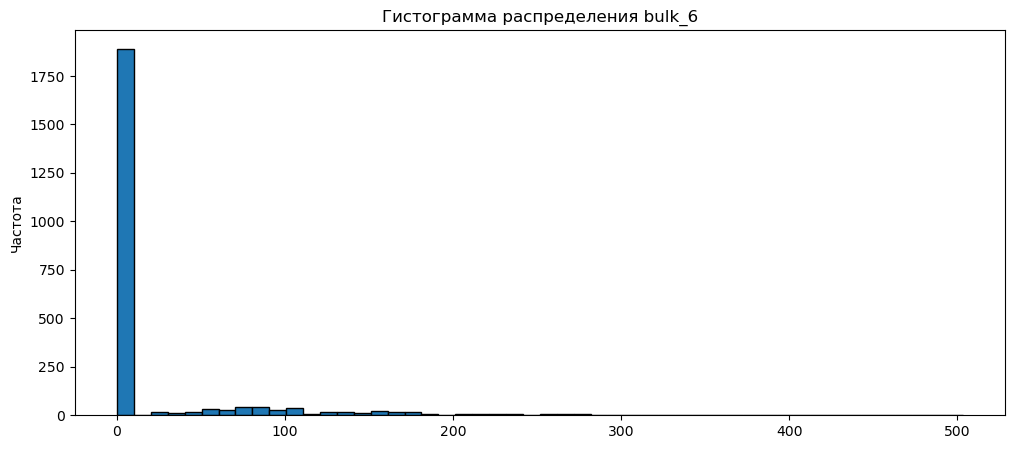

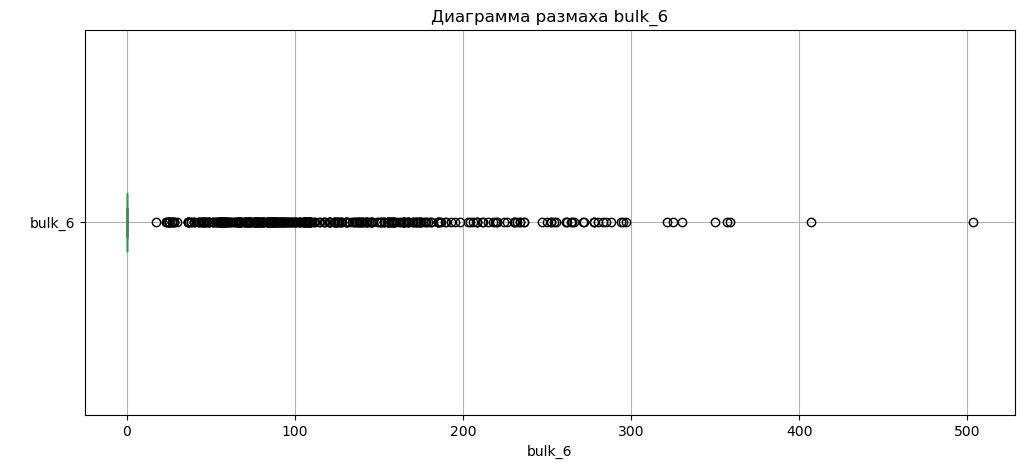

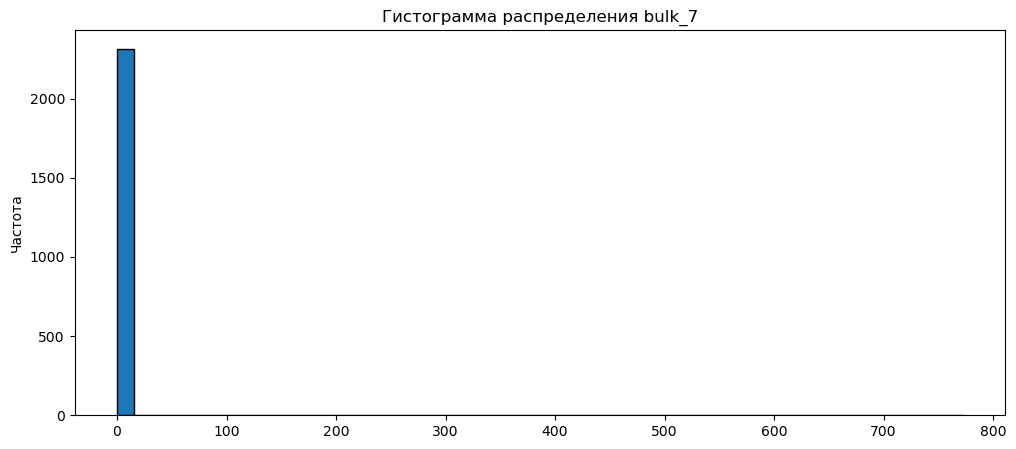

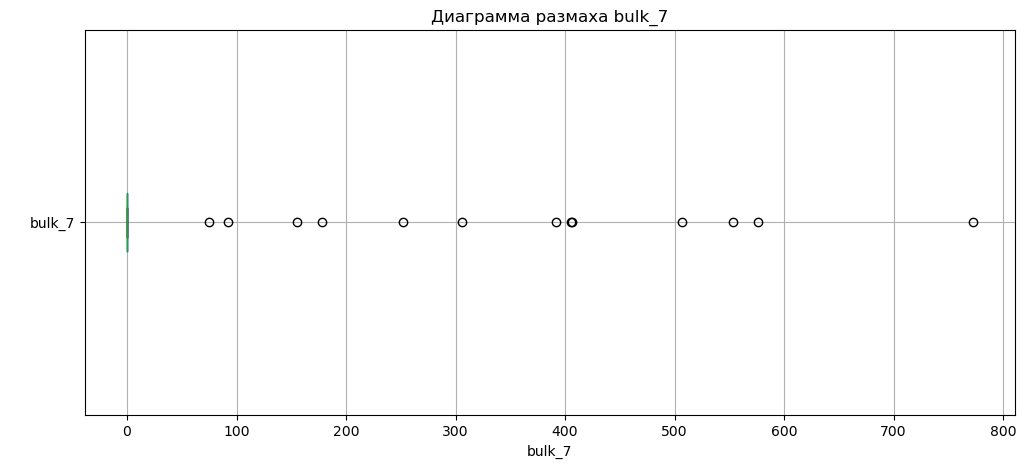

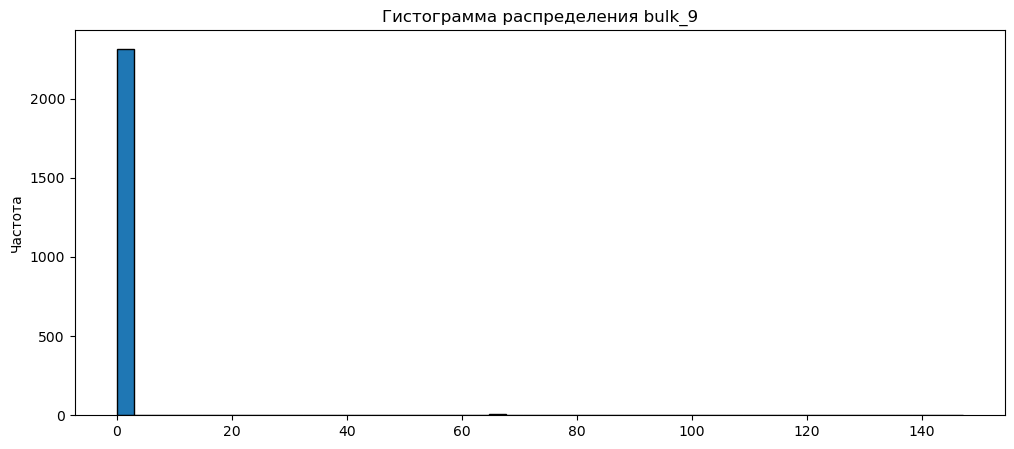

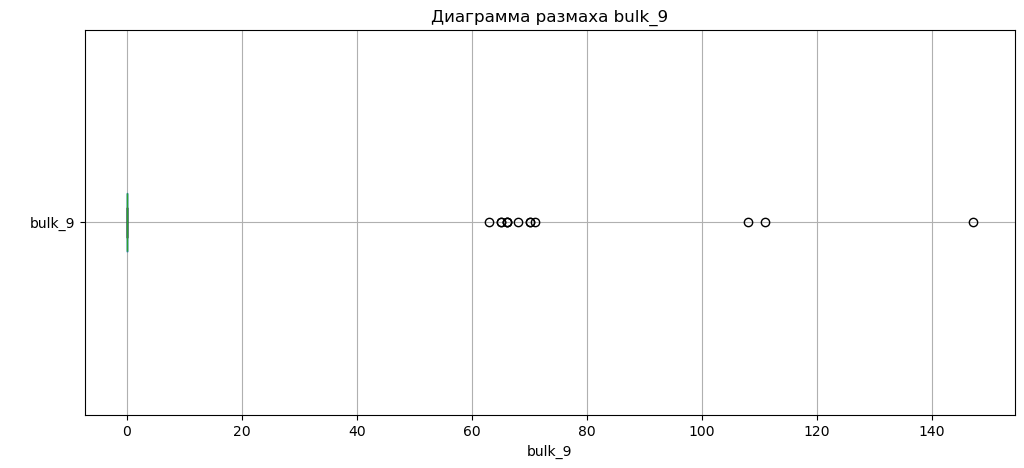

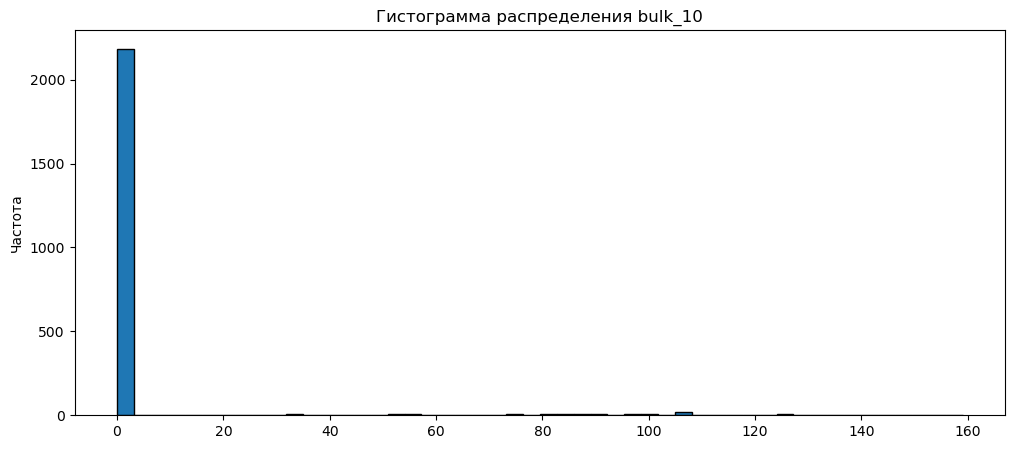

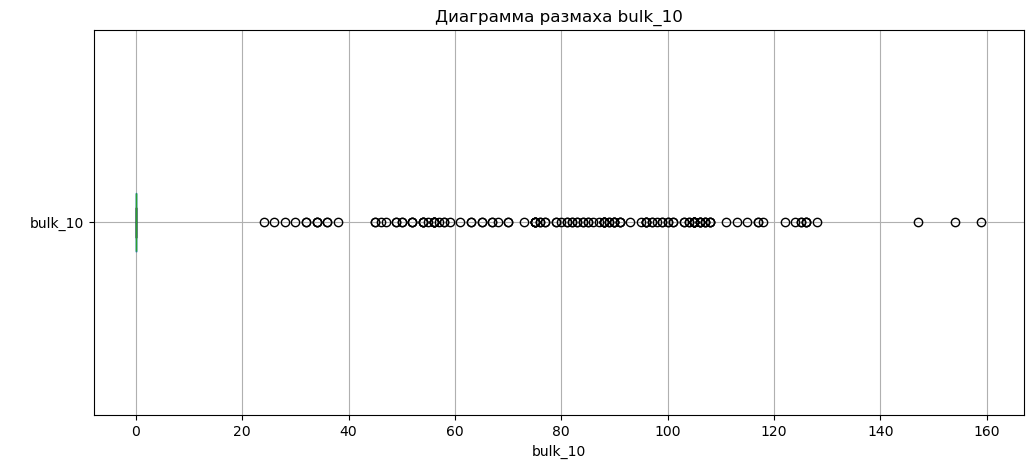

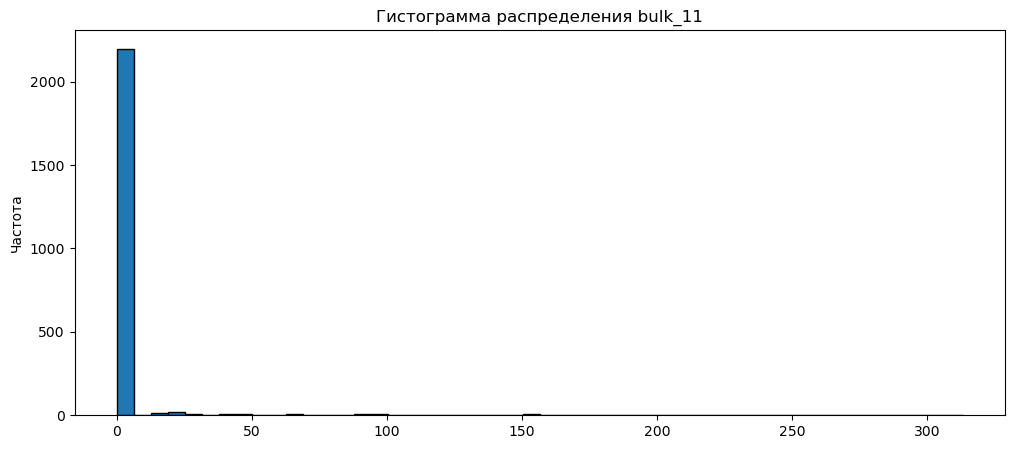

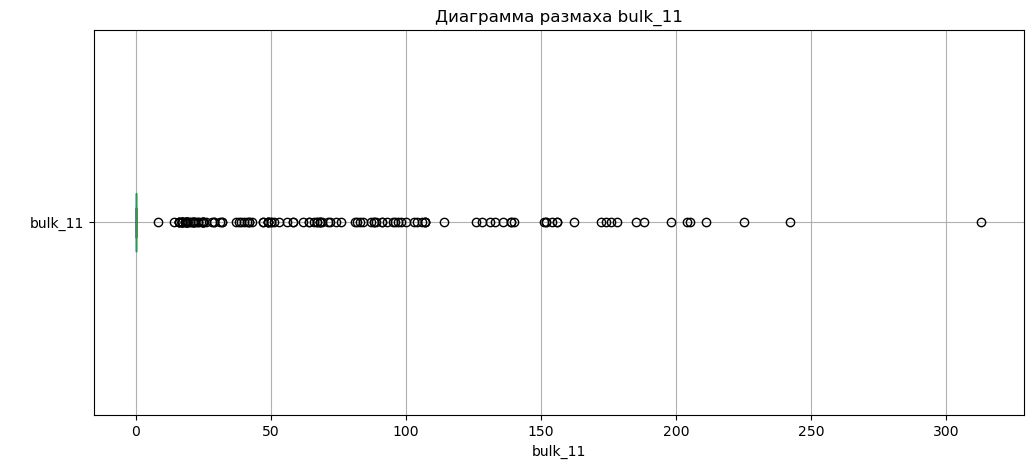

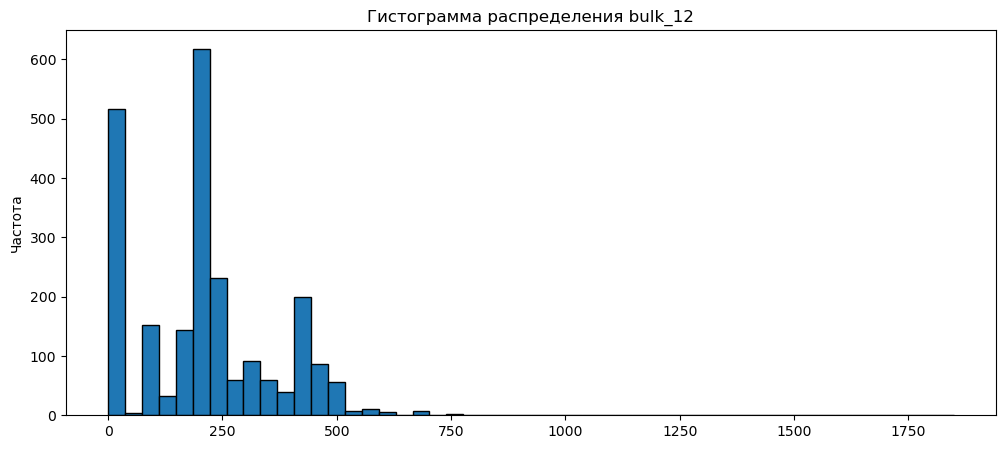

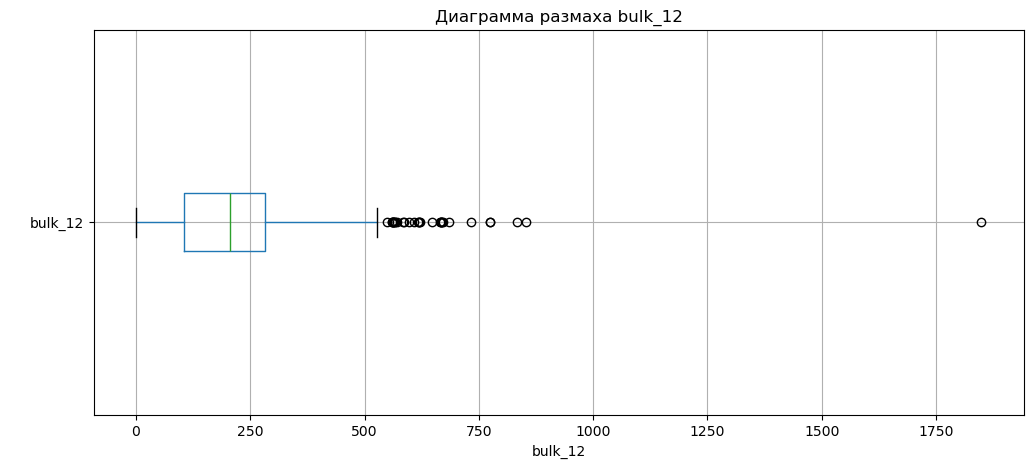

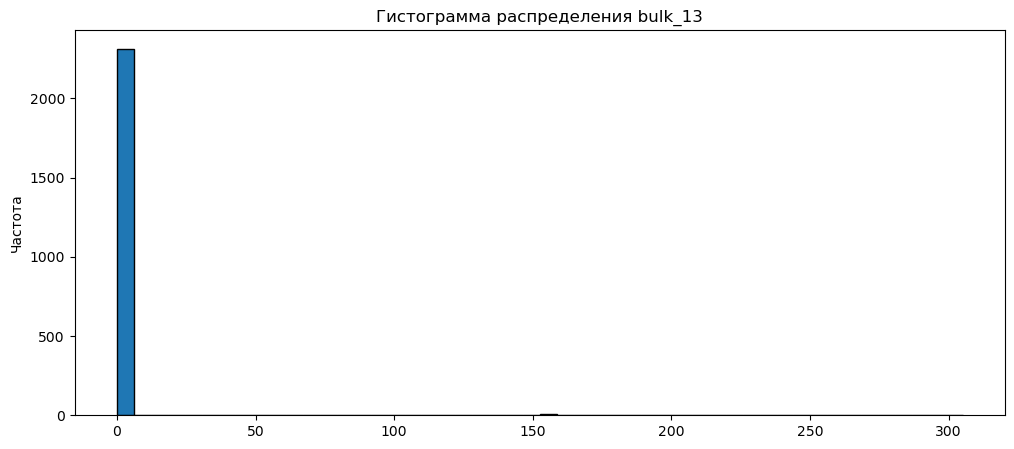

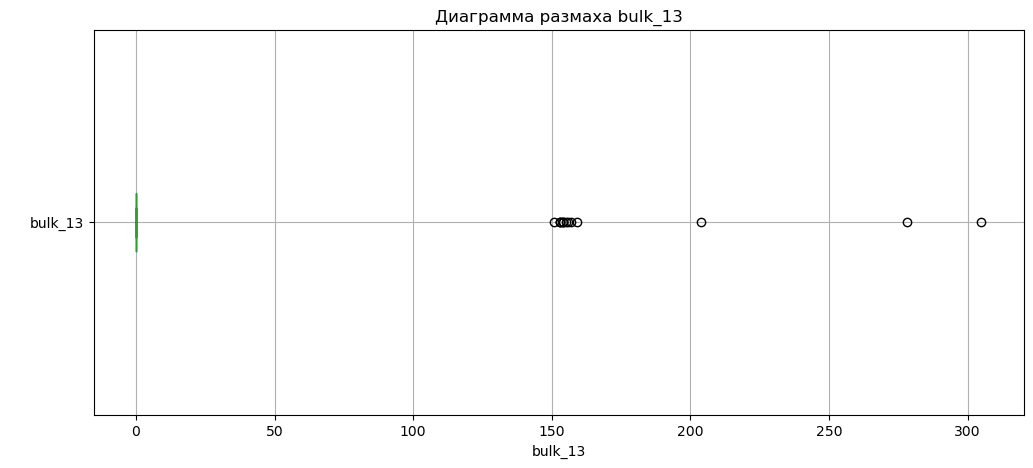

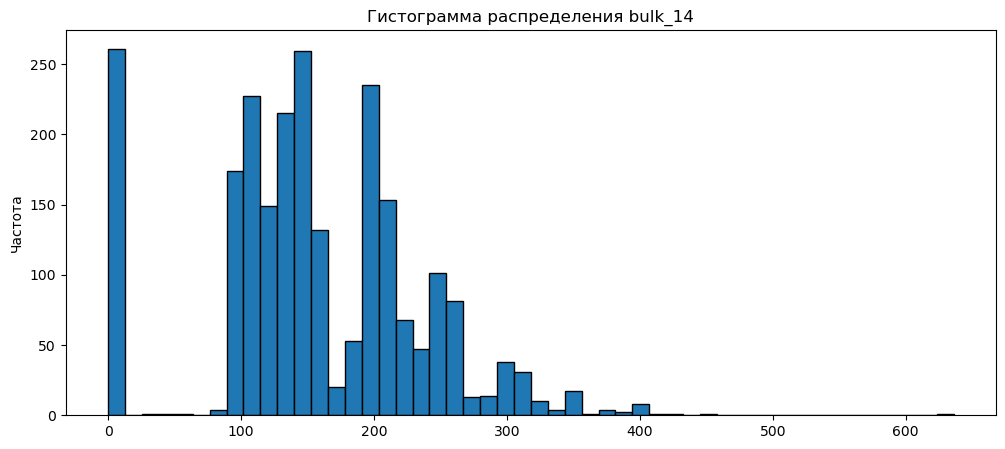

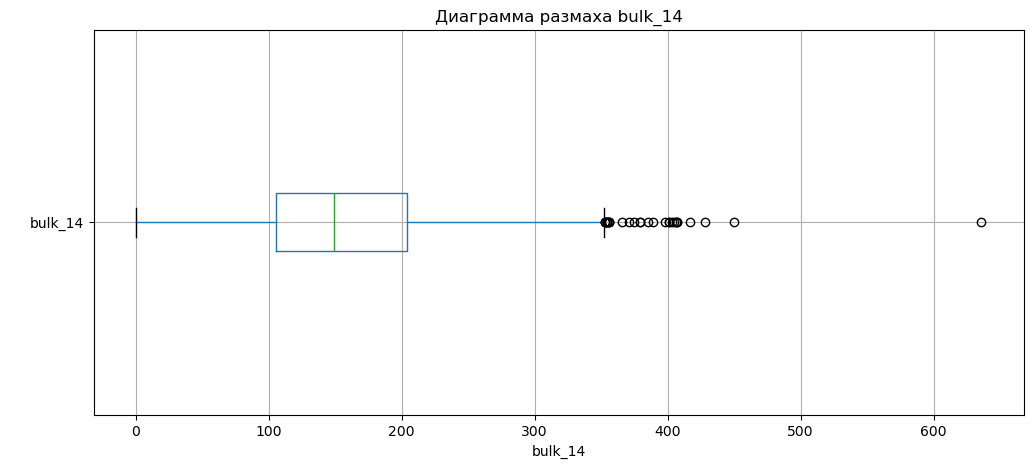

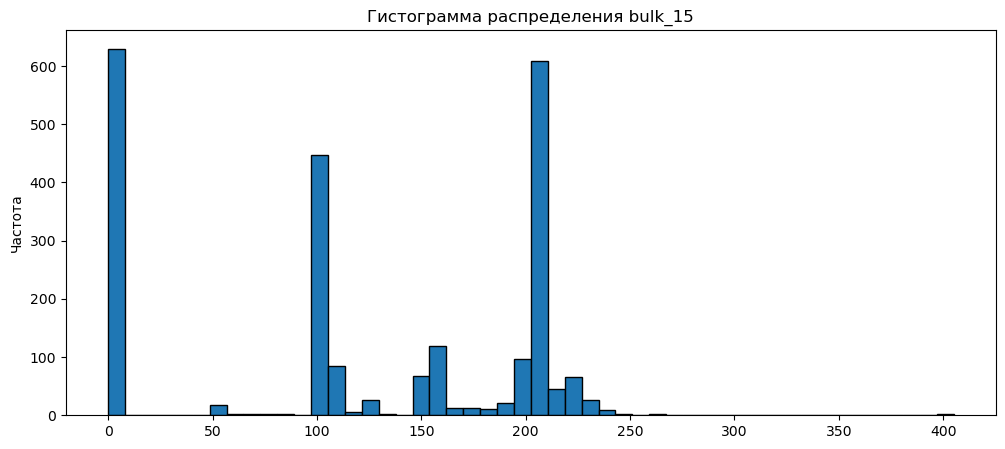

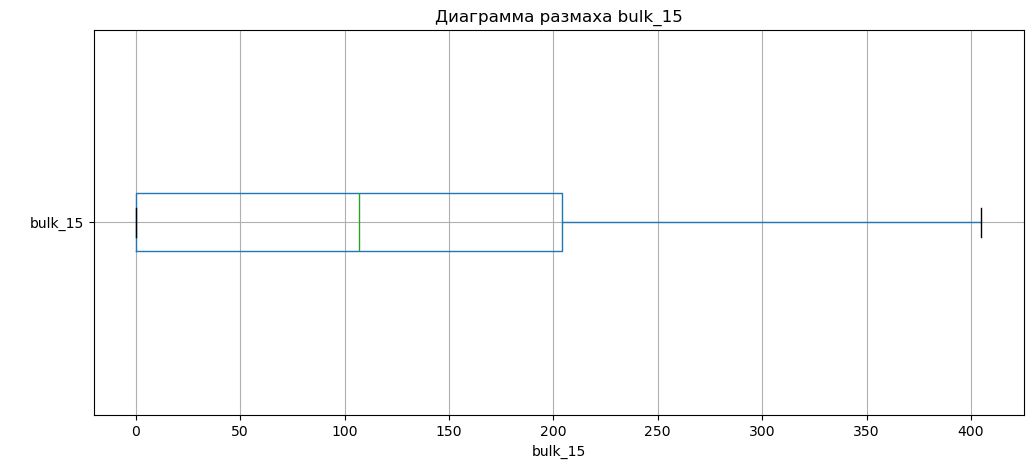

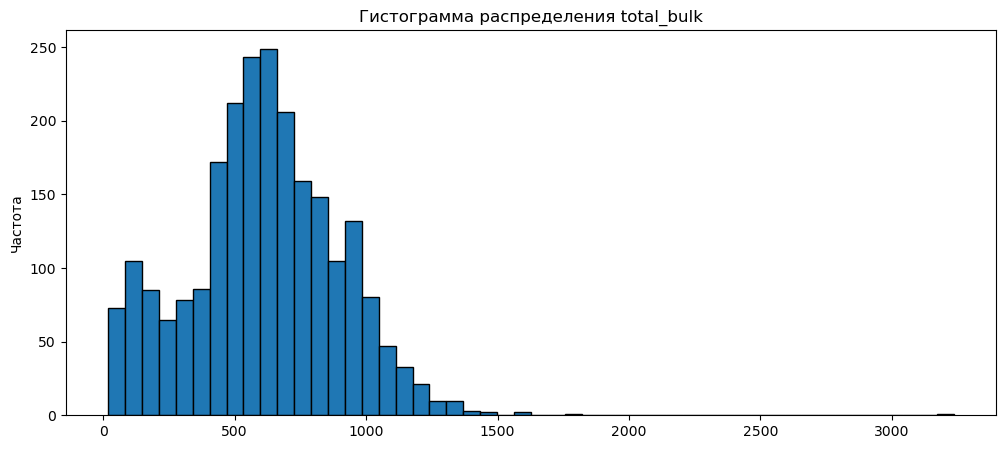

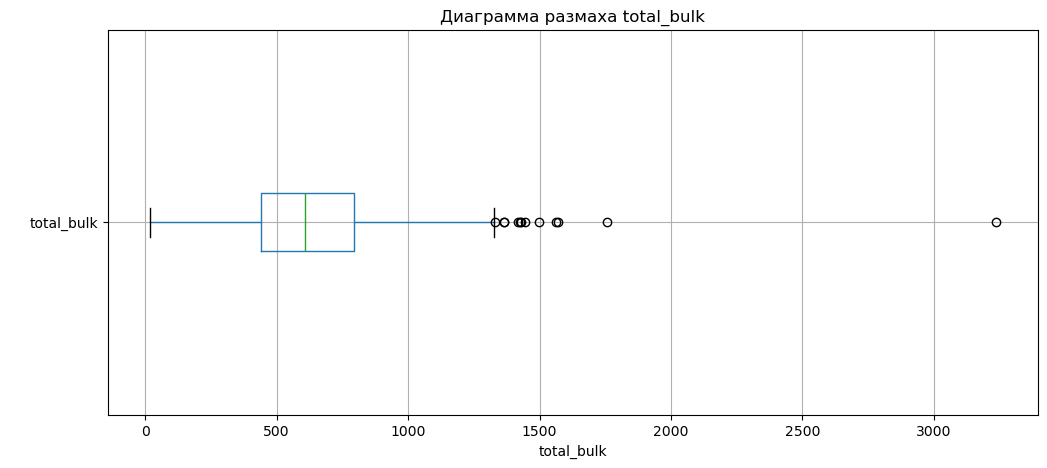

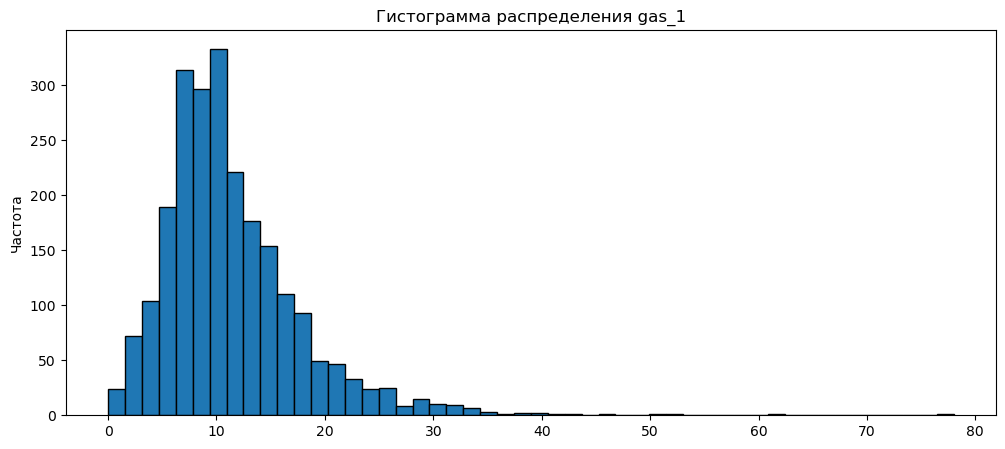

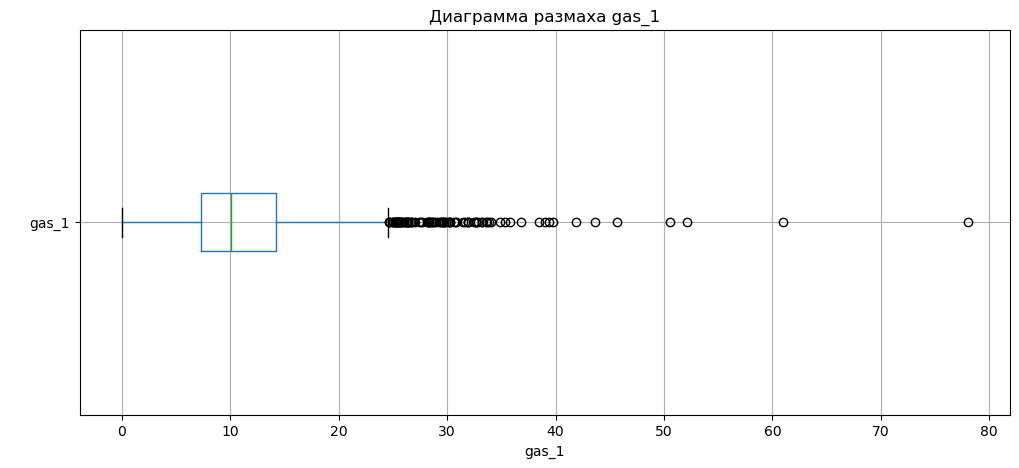

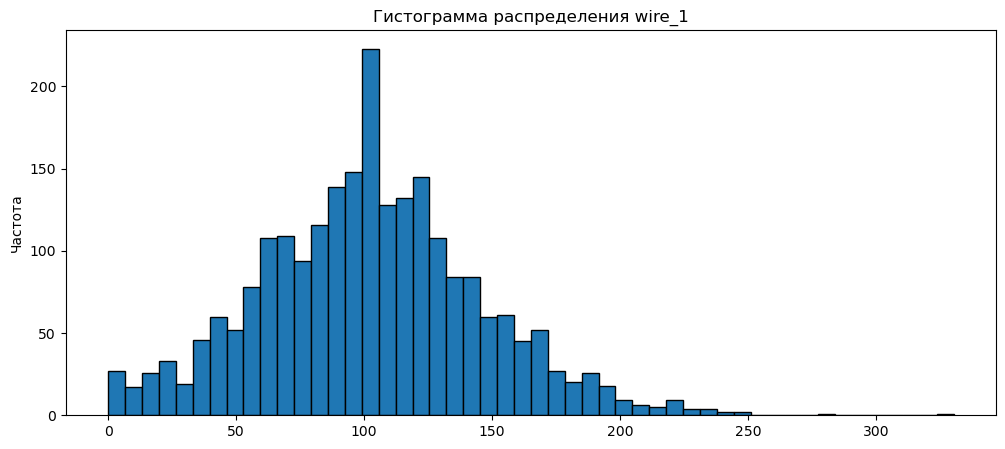

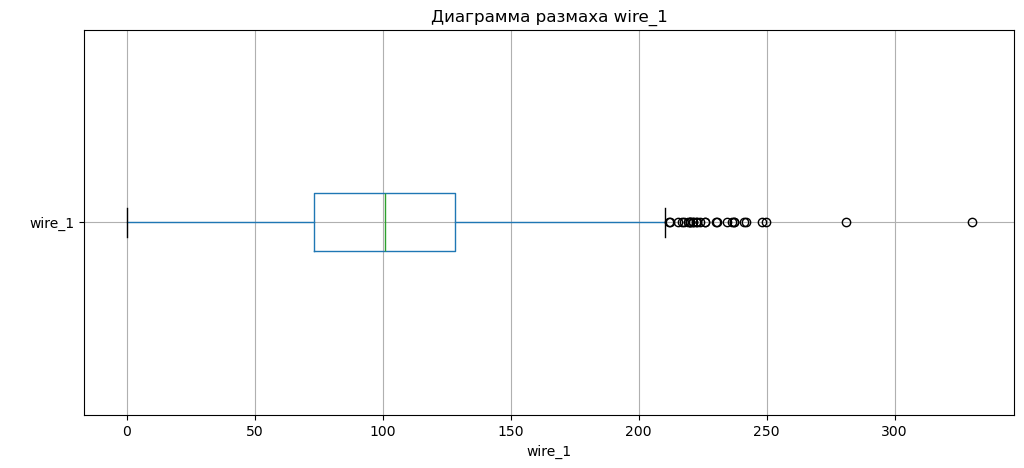

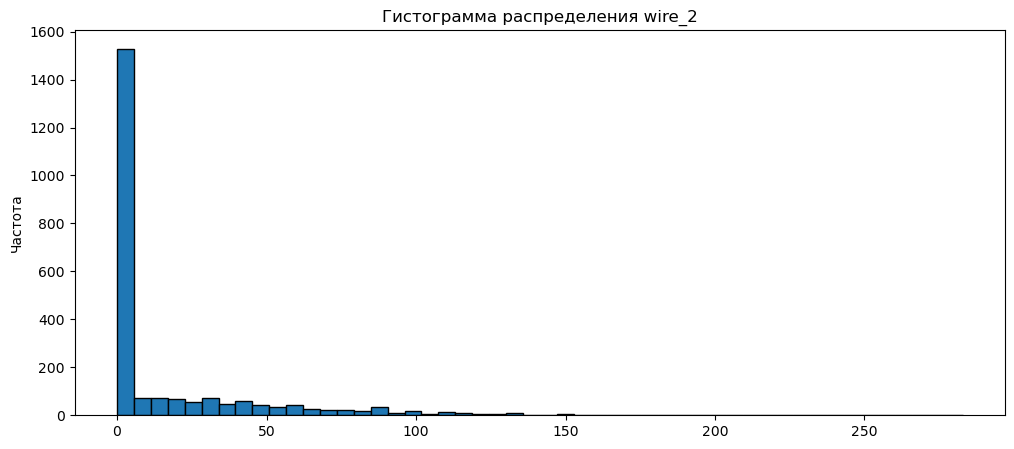

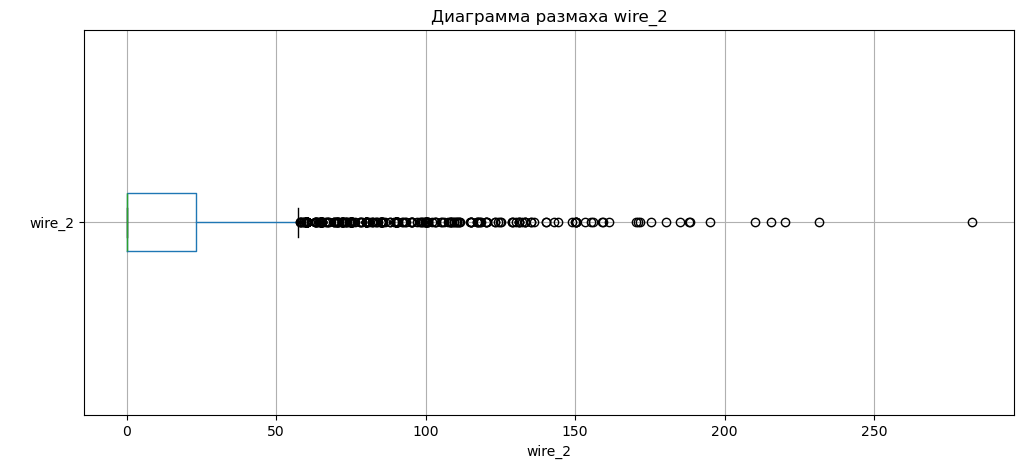

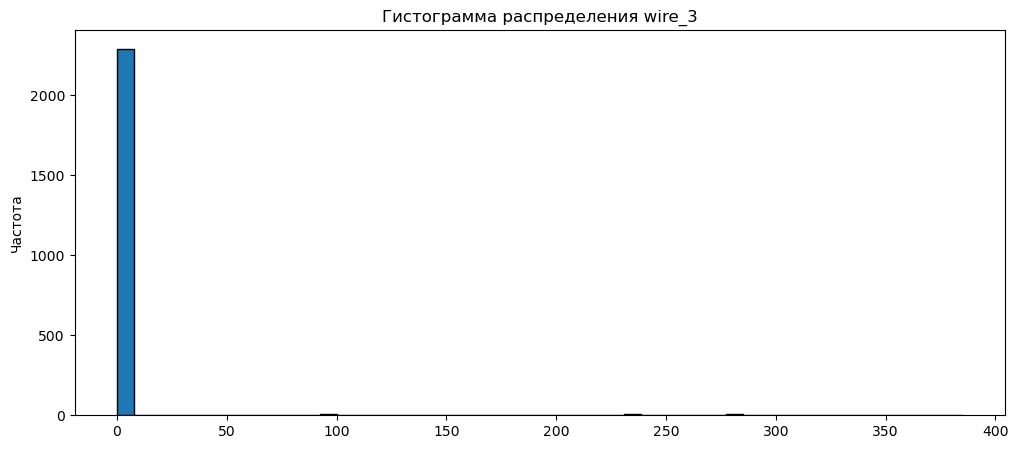

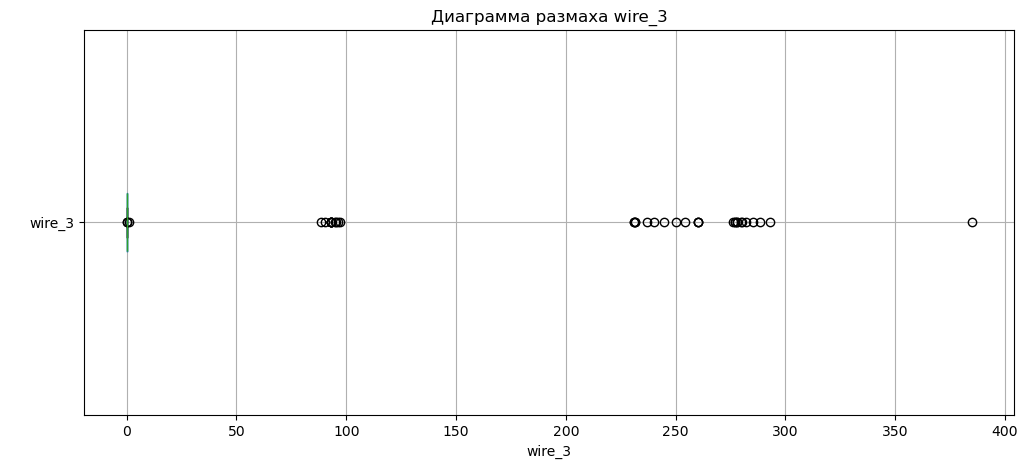

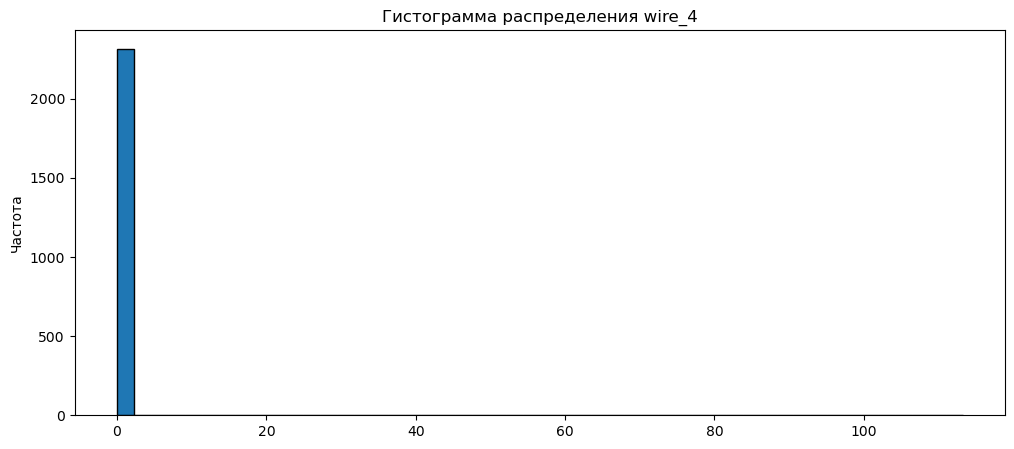

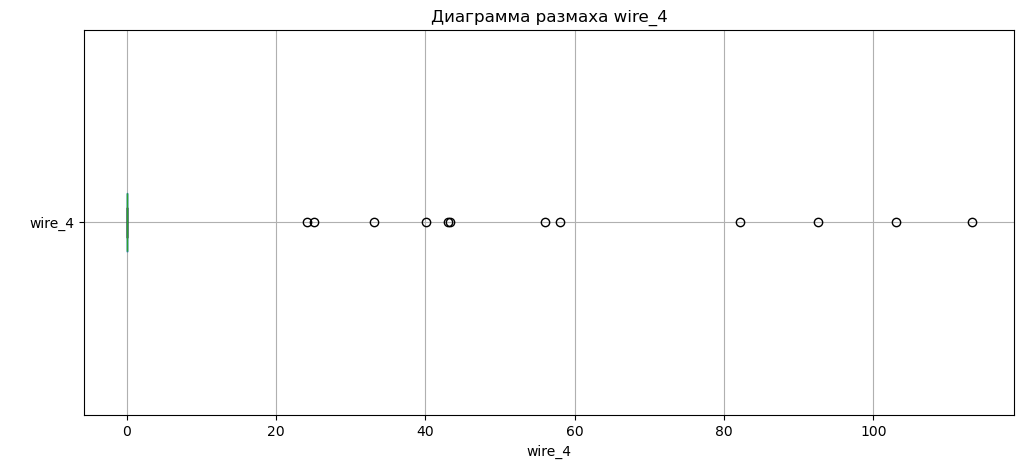

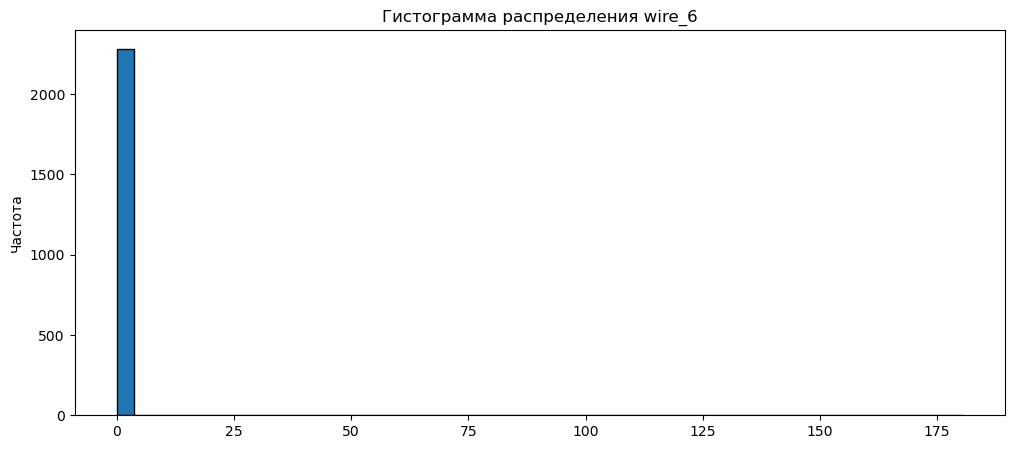

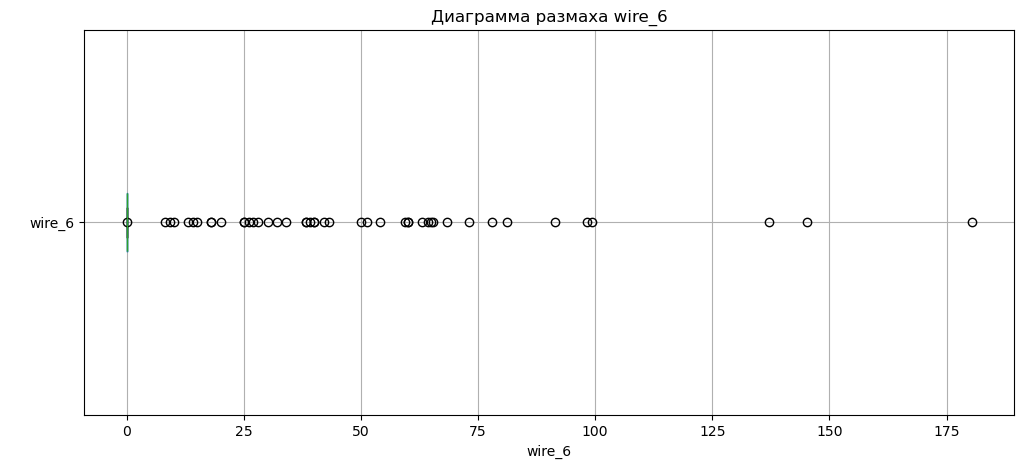

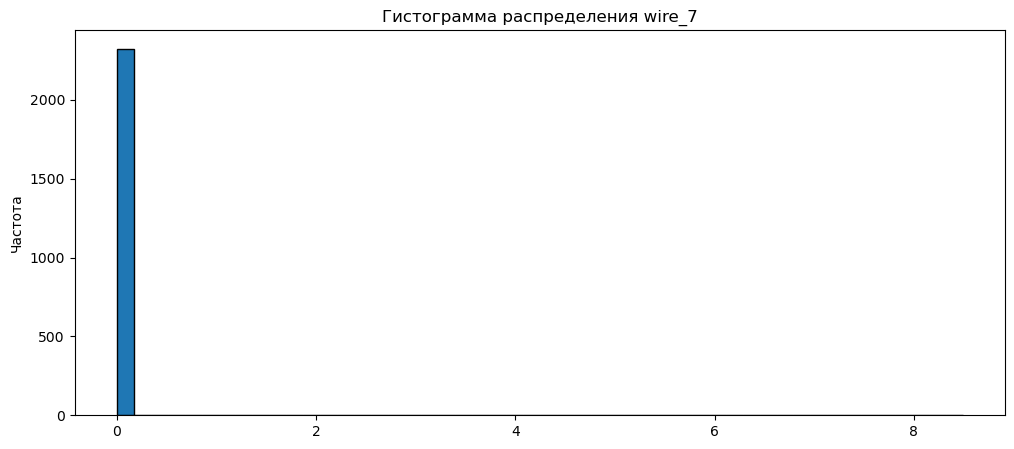

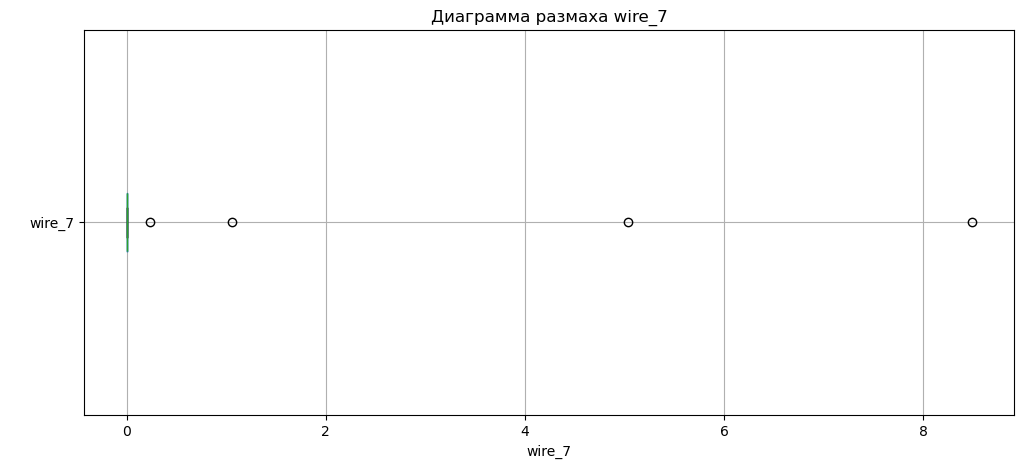

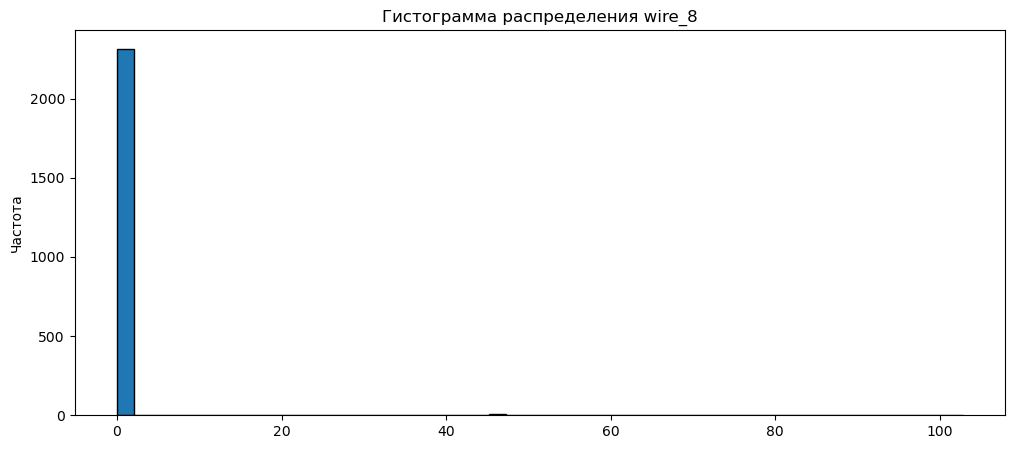

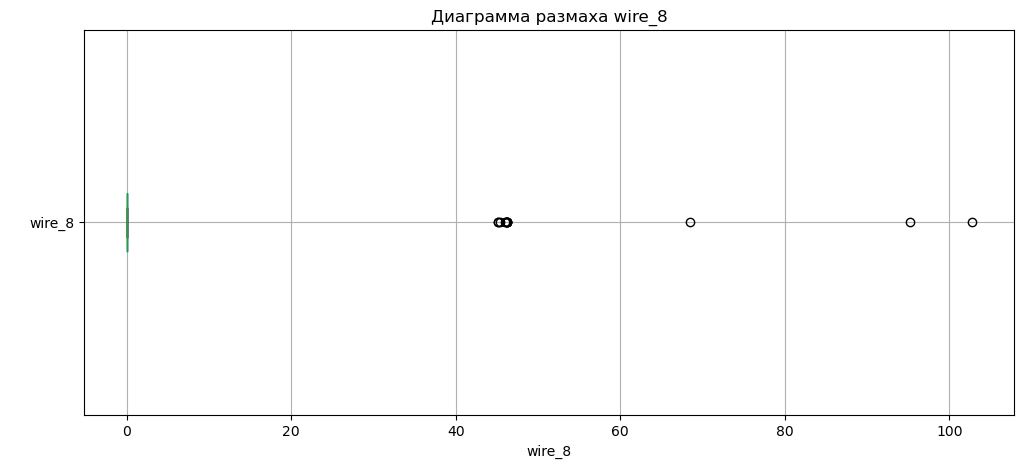

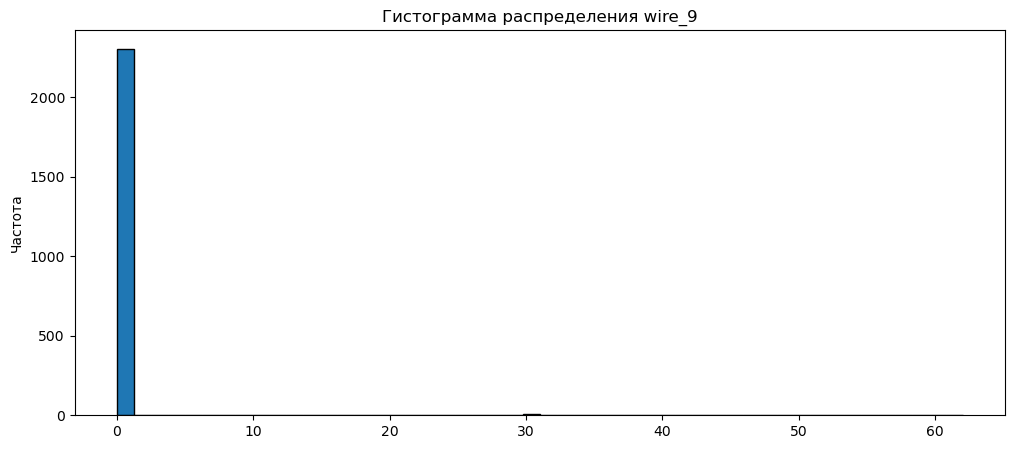

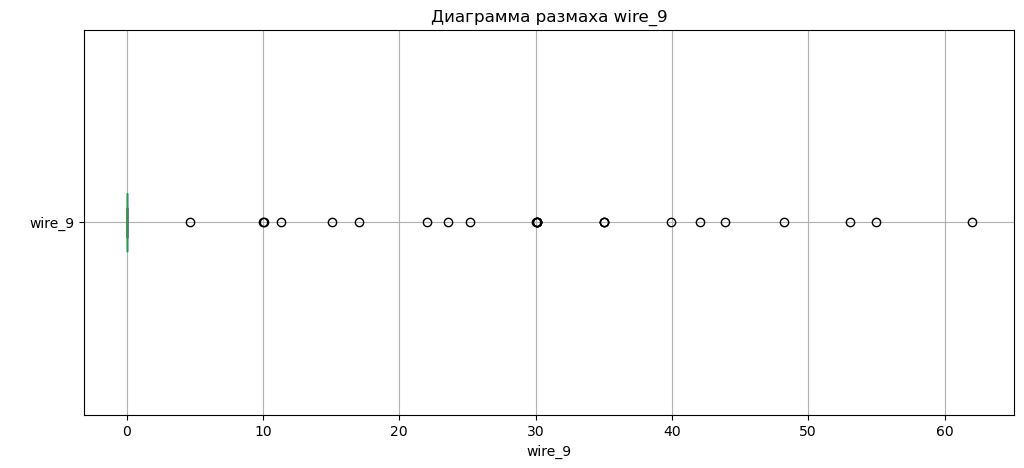

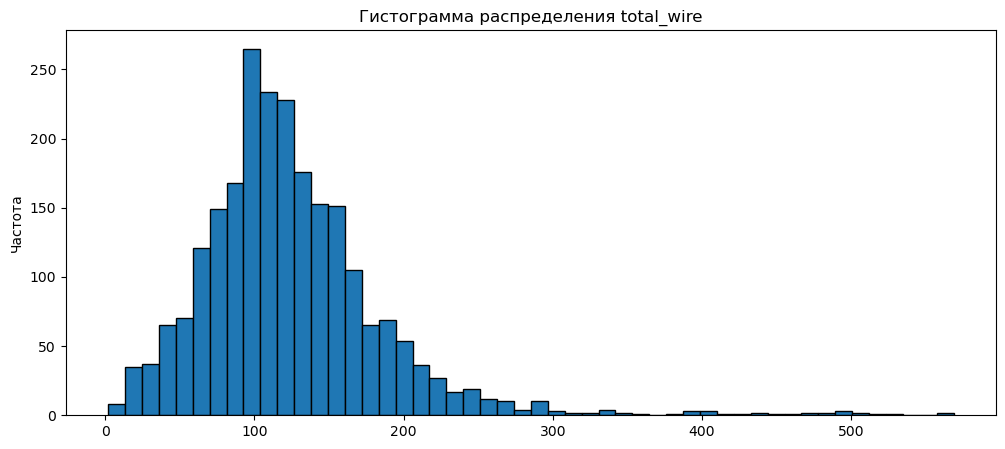

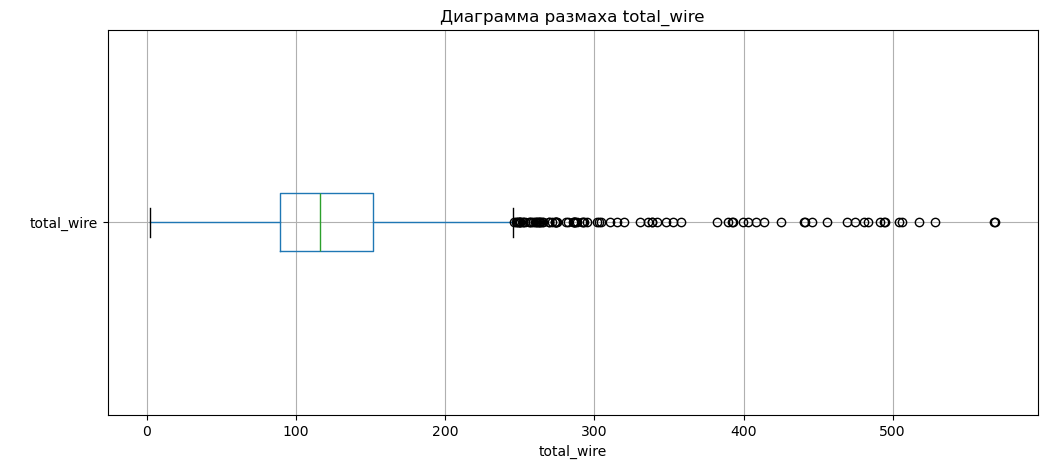

In [70]:
visual(data_final, 'data_final')

Подготовили финальную таблицу с признаками, таблица не содержит пропусков.

### Корреляционный анализ

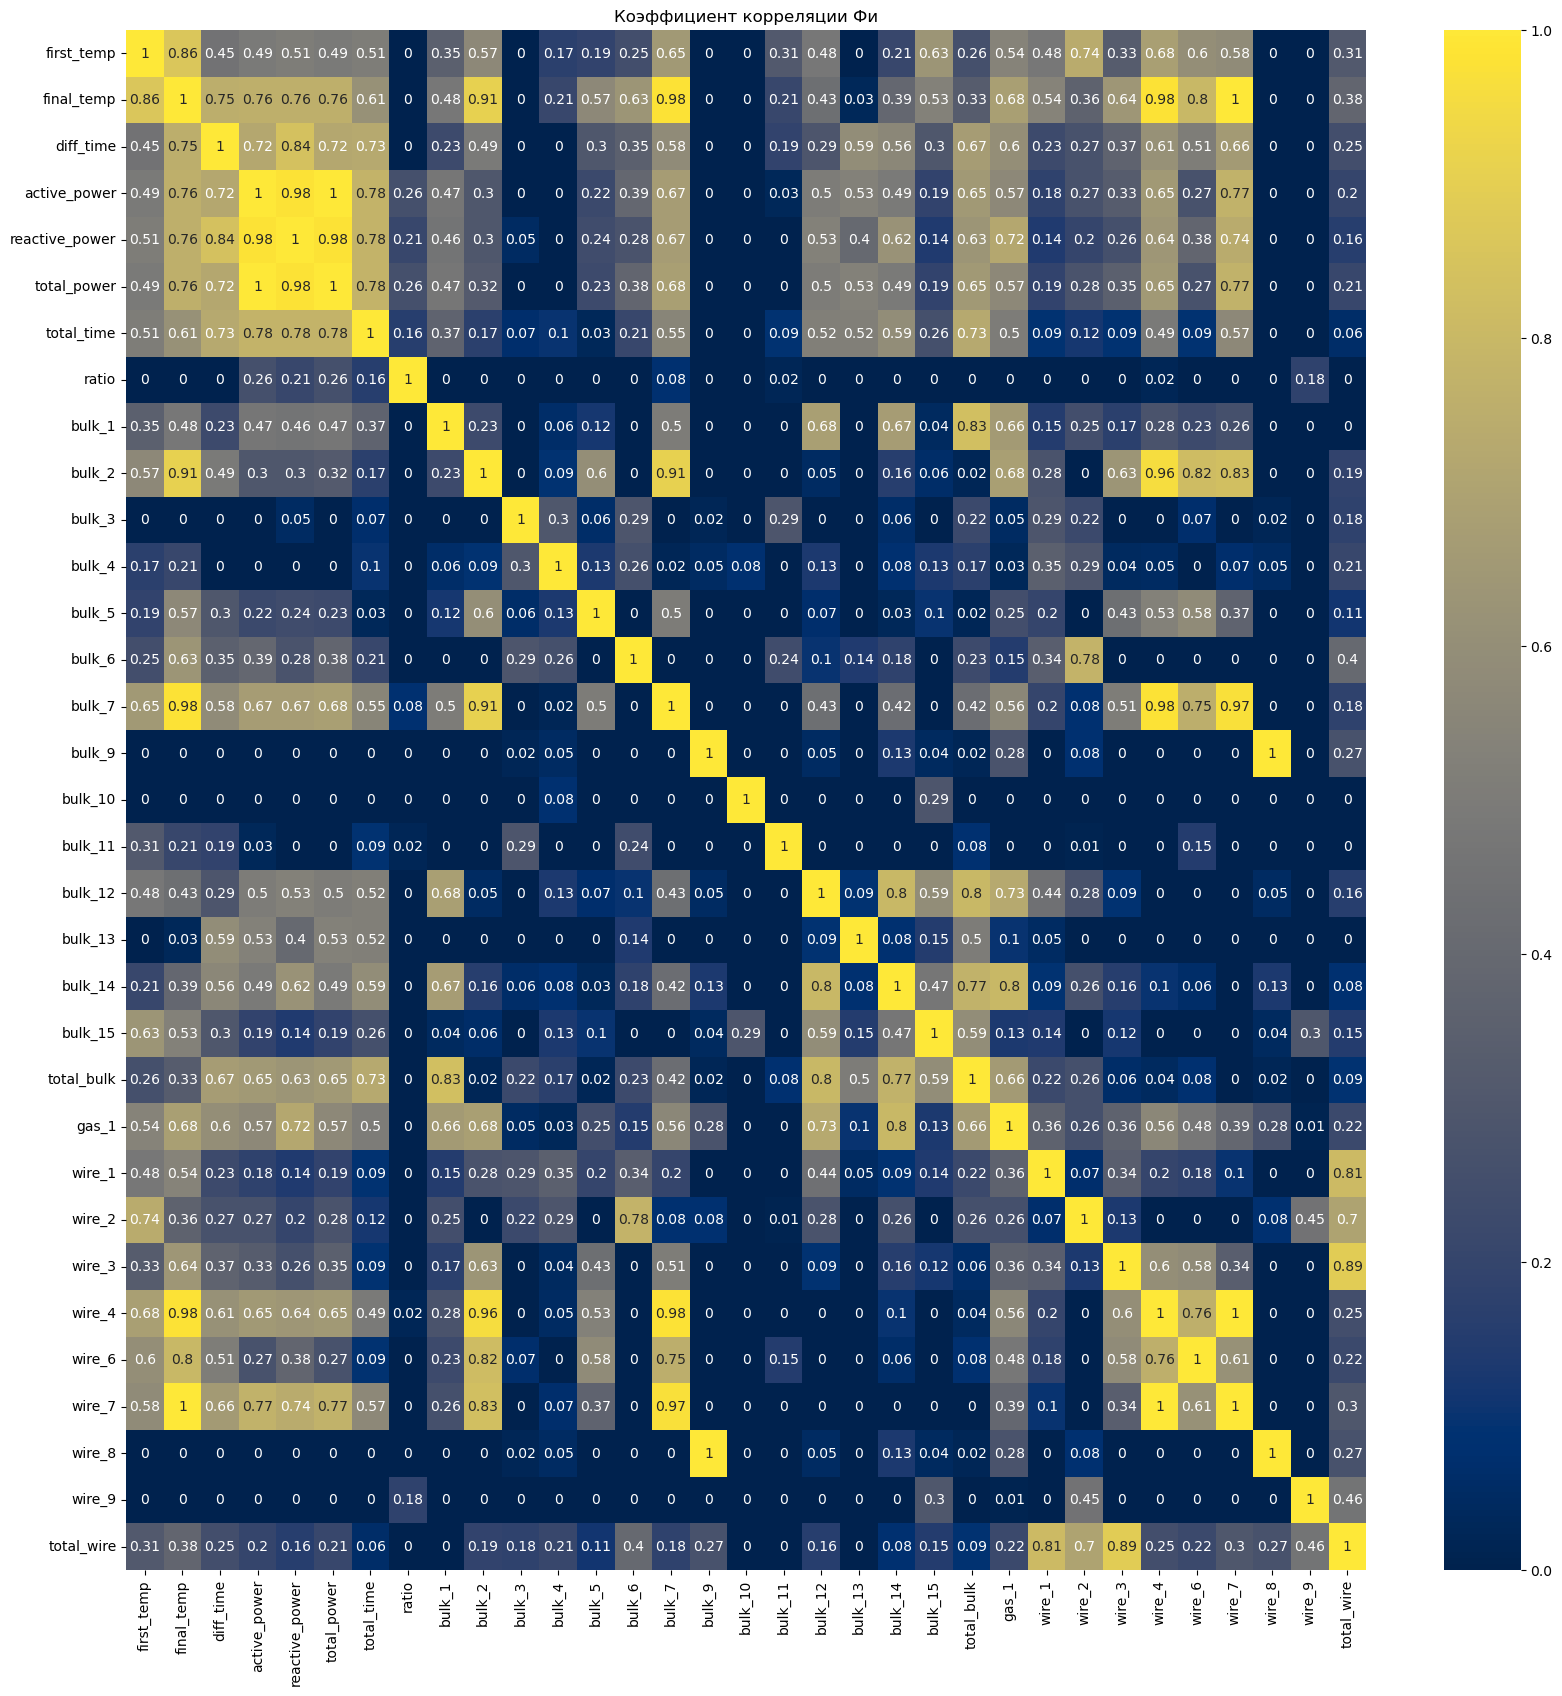

In [71]:
data_phi = data_final.drop(columns=['key']) 
# создание списка с наименованиями количественных признаков # непрерывные
interval_cols = ['diff_time', 'active_power', 'reactive_power', 'total_power', 'total_time', 'ratio',
                'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7','bulk_9',
                'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13', 'bulk_14', 'bulk_15', 'total_bulk',
                'gas_1', 'diff_time', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_6', 'wire_7',
                'wire_8', 'wire_9', 'total_wire']
# матрица корелляций Фи
data_phi = data_phi.phik_matrix(interval_cols=interval_cols).round(2)

#  построение тепловой карты Фи
plt.figure(figsize=(20, 20))
sns.heatmap(data_phi, annot=True, cmap='cividis')
plt.title("Коэффициент корреляции Фи")
plt.show()

Высокая корреляция признаков:\
- active_power/reactive_power/total_power
- bulk_2/wire_4
- bulk_7/final_temp
- bulk_7/wire_4
- bulk_7/wire_7
- bulk_9/wire_8
- wire_4/final_temp

Есть мултиколлинеарность между признаками, устраним её. Удалим `bulk_2`, `bulk_7`, `bulk_9`, `wire_4`,\
`active_power`, `reactive_power`

In [72]:
data_final = data_final.drop(columns=['active_power', 'reactive_power', 'bulk_2', 'bulk_7', 'bulk_9', 'wire_4'])

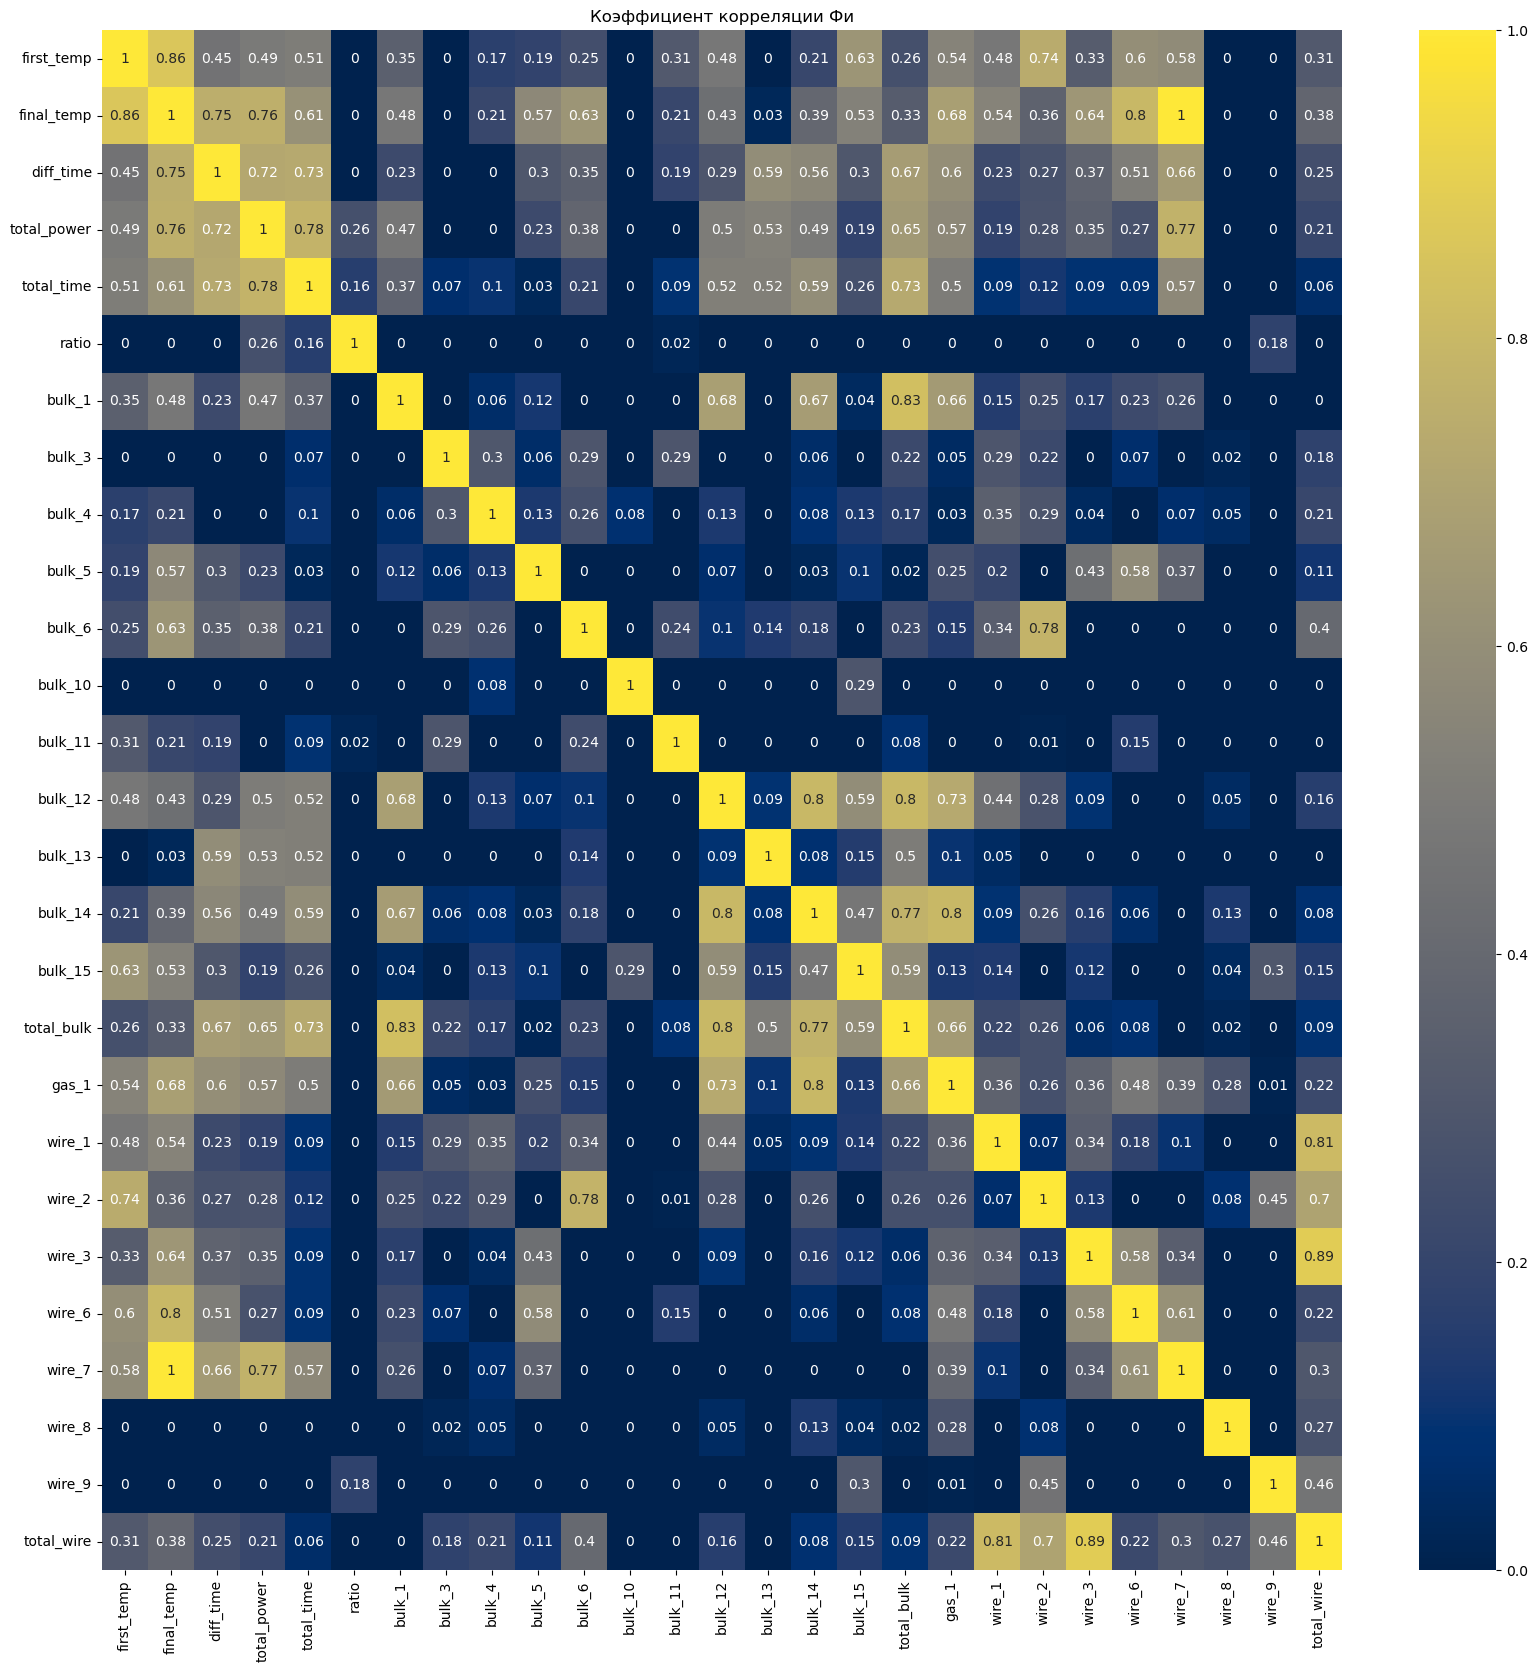

In [73]:
data_phi = data_final.drop(columns=['key']) 
# создание списка с наименованиями количественных признаков # непрерывные
interval_cols = ['diff_time', 'total_power', 'total_time', 'ratio', 'bulk_1', 'bulk_3', 'bulk_4',
                'bulk_5', 'bulk_6', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13', 'bulk_14', 'bulk_15',
                'total_bulk', 'gas_1', 'diff_time', 'wire_1', 'wire_2', 'wire_3', 'wire_6', 'wire_7',
                'wire_8', 'wire_9', 'total_wire']
# матрица корелляций Фи
data_phi = data_phi.phik_matrix(interval_cols=interval_cols).round(2)

#  построение тепловой карты Фи
plt.figure(figsize=(20, 20))
sns.heatmap(data_phi, annot=True, cmap='cividis')
plt.title("Коэффициент корреляции Фи")
plt.show()

Мультиколлинеарность исключили.

**Вывод**\
Название столбцов приведены к стандартному виду.\
Удалены неинформативные признаки.\
Подготовлена таблица с финальными признаками.\
Провели корреляцию признаков, отметили мультиколлинеарность и удалили признаки для её исключения.

## Шаг 5. Подготовка данных

In [74]:
# сохранение входного и целевого признаков
features = data_final.drop(['key', 'final_temp'], axis=1)
target = data_final['final_temp']

# разделение на тренировочную и тестовую выборки    
features_train, features_test, target_train, target_test = \
train_test_split(features, target, test_size=0.25, random_state=161225, shuffle=True)

Отмасштабируем признаки

In [75]:
scaler = MinMaxScaler()
features_train = pd.DataFrame(scaler.fit_transform(features_train), columns = features_train.columns)
features_test = pd.DataFrame(scaler.transform(features_test), columns = features_train.columns)

Выделили целевой признак. Отмасштабировали признаки.

## Шаг 6. Обучение моделей машинного обучения

**Линейная регрессия**

In [76]:
model_lr = LinearRegression(fit_intercept=True)
params_lr = {
    'copy_X': [True,False], 
    #'fit_intercept': [True,False], 
    'n_jobs': [1,5,10,None], 
    'positive': [True,False]
}
grid_lr = GridSearchCV(model_lr, params_lr, cv=5, scoring='neg_mean_absolute_error')
grid_lr.fit(features_train, target_train)
# замеряем mae на кросс-валидации
grid_lr.best_score_
mae_lr = round(abs(grid_lr.best_score_), 2)
print(f"Лучшая MAE на кросс-валидации {mae_lr}")
best_model = grid_lr.best_estimator_
print(f"Лучшая модель и её параметры:\n\n {best_model}")

Лучшая MAE на кросс-валидации 5.98
Лучшая модель и её параметры:

 LinearRegression(n_jobs=1)


**Случайный лес**

In [77]:
model_rf = RandomForestRegressor(random_state=161225)
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}
grid_rf = GridSearchCV(model_rf, params_rf, cv=5, scoring='neg_mean_absolute_error')
grid_rf.fit(features_train, target_train)
# замеряем mae на кросс-валидации
grid_rf.best_score_
mae_rf = round(abs(grid_rf.best_score_), 2)
print(f"Лучшая MAE на кросс-валидации {mae_rf}")
best_model = grid_rf.best_estimator_
print(f"Лучшая модель и её параметры:\n\n {best_model}")

Лучшая MAE на кросс-валидации 5.92
Лучшая модель и её параметры:

 RandomForestRegressor(max_depth=20, min_samples_leaf=2, n_estimators=200,
                      random_state=161225)


**LGBMRegressor**

In [78]:
model_lgbm = LGBMRegressor(verbose=500, random_state=161225)
params_lgbm = {
    'num_leaves': [31, 63],
    'max_depth': [3, 15],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 300, 500],
    'metric': ['mae']
}
grid_lgbm = GridSearchCV(model_lgbm, params_lgbm, cv=5, scoring='neg_mean_absolute_error')
grid_lgbm.fit(features_train, target_train)
# замеряем mae на кросс-валидации
grid_lgbm.best_score_
mae_lgbm = round(abs(grid_lgbm.best_score_), 2)
print(f"Лучшая MAE на кросс-валидации {mae_lgbm}")
best_model = grid_lgbm.best_estimator_
print(f"Лучшая модель и её параметры:\n\n {best_model}")

[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.892755
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.383818
[LightGBM] [Debug] init for col-wise cost 0.000178 seconds, init for row-wise cost 0.000403 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3080
[LightGBM] [Info] Number of data points in the train set: 1396, number of used features: 22
[LightGBM] [Info] Start training from score 1593.223496
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 8 and depth = 3
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 8 and depth = 3
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves 

**CatBoostRegressor**

In [79]:
model_cbr = CatBoostRegressor(verbose=500, random_state=161225)
params_cbr = {
    'n_estimators': [500], # 100, 250
    'depth': [5], # 10, 15
    'learning_rate': [0.01], #0.01, 0.1
    'loss_function': ['MAE']
}
grid_cbr = RandomizedSearchCV(model_cbr, params_cbr, n_iter=10, cv=5, scoring='neg_mean_absolute_error')
grid_cbr.fit(features_train, target_train)
# замеряем mae на кросс-валидации
#grid_cbr.best_score_
mae_cbr = round(abs(grid_cbr.best_score_), 2)
print(f"Лучшая MAE на кросс-валидации {mae_cbr}")
best_model = grid_cbr.best_estimator_
print(f"Лучшая модель и её параметры:\n\n {best_model}")

C:\Users\1\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


0:	learn: 7.9327569	total: 152ms	remaining: 1m 16s
499:	learn: 5.2940482	total: 1.51s	remaining: 0us
0:	learn: 7.6922682	total: 2.46ms	remaining: 1.23s
499:	learn: 5.2452714	total: 1.27s	remaining: 0us
0:	learn: 7.8045230	total: 2.39ms	remaining: 1.19s
499:	learn: 5.3760418	total: 1.17s	remaining: 0us
0:	learn: 7.9172002	total: 2.6ms	remaining: 1.29s
499:	learn: 5.3510123	total: 1.36s	remaining: 0us
0:	learn: 7.9948737	total: 3.23ms	remaining: 1.61s
499:	learn: 5.2655722	total: 1.56s	remaining: 0us
0:	learn: 7.8693289	total: 2.61ms	remaining: 1.3s
499:	learn: 5.3521154	total: 1.54s	remaining: 0us
Лучшая MAE на кросс-валидации 6.07
Лучшая модель и её параметры:

 CatBoostRegressor(depth=5, learning_rate=0.01, loss_function='MAE', n_estimators=500, random_state=161225, verbose=500)


In [80]:
best_model_params = best_model.get_params()
print(best_model_params)

{'loss_function': 'MAE', 'verbose': 500, 'random_state': 161225, 'n_estimators': 500, 'learning_rate': 0.01, 'depth': 5}


Данная модель очень долго обучается. Поэтому закоментировала гиперпараметры, оставила параметры лучшей модели.

## Шаг 7. Выбор лучшей модели

In [81]:
result = {'MAE':pd.Series([mae_lr, mae_rf, mae_lgbm, mae_cbr],
                          index = ['LinearRegression', 'RandomForestRegressor', 'LGBMRegressor', 'CatBoostRegressor'])
      }
result = pd.DataFrame(result).reset_index()
result

,index,MAE
0,LinearRegression,5.98
1,RandomForestRegressor,5.92
2,LGBMRegressor,5.77
3,CatBoostRegressor,6.07


In [82]:
model_dr = DummyRegressor()
model_dr.fit(features_train, target_train)
pred_train_dr = model_dr.predict(features_test)
mae_dr = mean_absolute_error(target_test, pred_train_dr)
mae_dr

8.54684443184816

Лучшая модель LGBMRegressor, протестируем лучшую модель.

In [83]:
predictions = grid_lgbm.best_estimator_.predict(features_test)
result = mean_absolute_error(target_test, predictions)
print(f"MAE {result:.2f}")

MAE 6.31


mae на тестовой выборке = 6.3 модели LightGBMRegressor, а mae модели DummyRegressor равно 8, значит наша модель прошла проверку на адекватность. Обученая модель ошибается на 6 градусов.

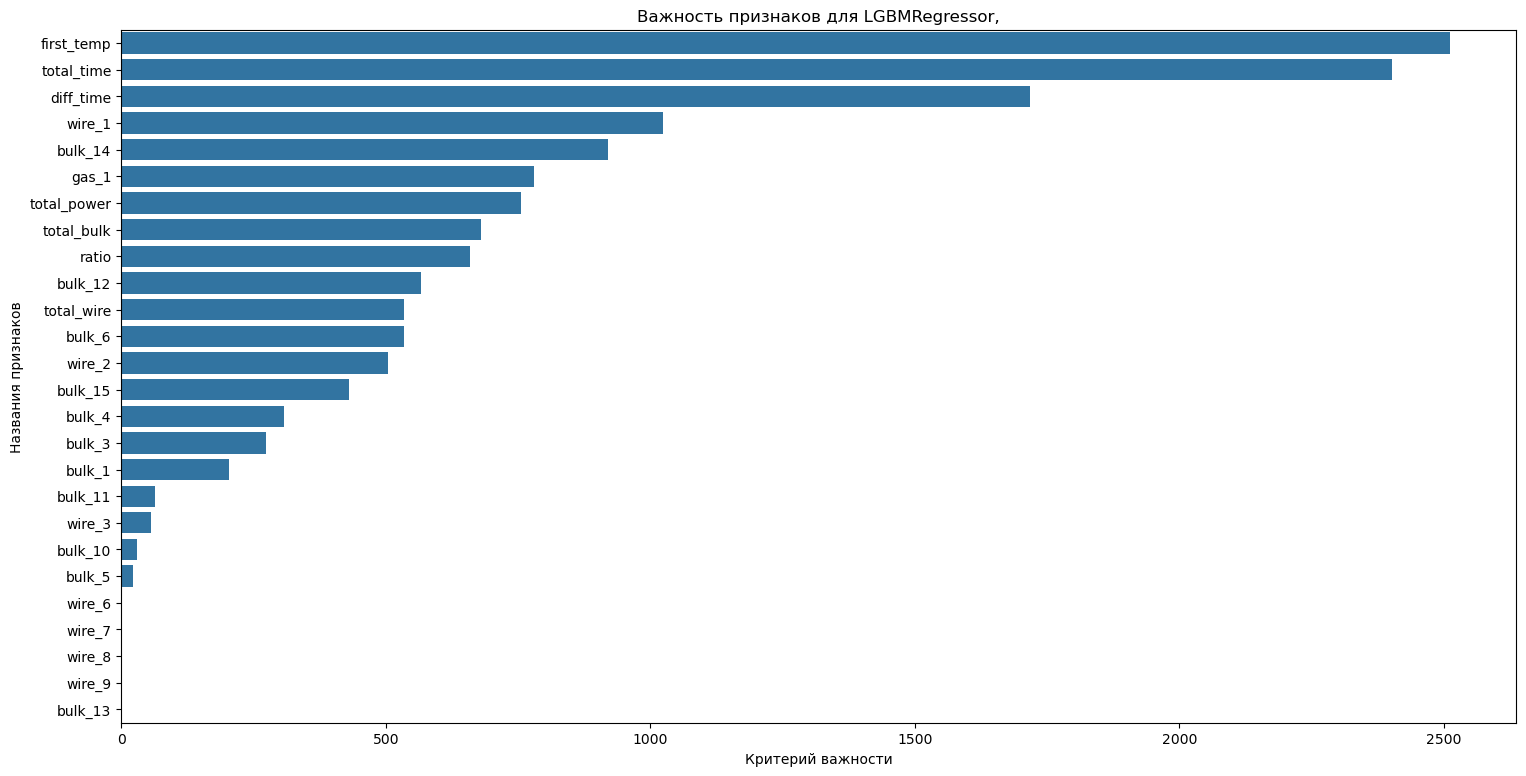

In [84]:
plot_data = {
    'features': features_test.columns,
    'feature_importances': grid_lgbm.best_estimator_.feature_importances_,
}
plot_data = pd.DataFrame(plot_data)
plot_data.sort_values(by='feature_importances', ascending=False, inplace=True)
plt.figure(figsize=(18, 9))
sns.barplot(x=plot_data['feature_importances'], y=plot_data['features'])
plt.title('Важность признаков для LGBMRegressor,')
plt.xlabel('Критерий важности')
plt.ylabel('Названия признаков')
plt.show()

Важные признаки для LGBMRegressor: температура на входе, общее время нагрева дугой, время замера между температурой на входе и температурой на выходе, подача проволочных материалов (данные где меньше всего пропусков), подача сыпучих материалов (bulk_14), общая мощность.

## Шаг 8. Общий вывод и рекомендации заказчику

Задача: построить модель, которая будет предсказывать температуру стали.\

Загрузили даннные из шести таблиц. Все датафреймы содержат одинаковый столбец key - номер партии, количество партий во всех датафреймах разное.
Типы данных во всех датафреймах корректны. Названия столбцов имеют расхождение с хорошим стилем.\
В ходе предобработки и исследрвательского анализа выявлены и обработаны пропуски и выбросы. Пропуски заменили на "0", так как нет возможности заполнить данные. Реактивная мощность содержала отрицательное значение, поэтому удалили всю партию с данным значением. Также удалили значения температуры меньше 1400,так как  при данной температуре сталь кристаллизуется.\ 
Выявлены неинформативные признаки - данные о времени подачи сыпучих и проволочных материалов, а также есть столбцы с сыпучими и проволочными материалами, которые содержат по одному значению.\
Далее добавили новые признаки полная мощность, отношение реактивной и активной мощностей, общее количество сыпучих материалов, общее количество проволочных материалов, время между замерами температуры на входе и на выходе, время замера температуры на входе, время замера температуры на выходе, температура стали на входе, температура стали на выходе (целевой признак).\
Затем объединили таблицы по партии. В общей таблице удалили неинформативные признаки время замера температуры на входе, время замера температуры на выходе, столбец с сыпучими и столбец с проволочными материалами. Также удалили пропуски.\
Проведя корреляционный анализ, для исключения мультиколлинеарности, удалили данные с активной и реактивной мощностью, данные с сыпучими и проволочными материалами.\
Затем выделили целевой признак - температура стали на выходе. Отмасштабировали признаки.\
Обучили 4 модели: LinearRegression, RandomForestRegressor, LGBMRegressor,  CatBoostRegressor. Лучшая модель на кросс-валидации LGBMRegressor. Данная модель прошла проверку на адекватность. Модель ошибается на 6 градусов. \
Далее протестировали лучшую модель, сделали проверку модели на адекватность. Выделили важные признаки - температура на входе, общее время нагрева дугой, время замера между температурой на входе и температурой на выходе, подача проволочных материалов (данные где меньше всего пропусков), подача сыпучих материалов (bulk_14), общая мощность.
